# 013. 量子化の基礎(Quantization Basics)

## 1. 概要 / Overview

量子化(Quantization)は、モデルの重みを少ないビット数の離散的な値で表すことで、格納に要する
メモリと、推論時にメモリから読み出すバイト数を減らす技術である。本トピックでは、一様量子化
(Uniform Quantization)の absmax 方式・ゼロ点(Zero-Point)付き方式と、正規分布に対する
分位点量子化(Quantile Quantization)である NF4(4-bit NormalFloat)・二重量子化(Double
Quantization)をスクラッチ実装し、量子化誤差の理論値との一致、量子化の粒度と重みの外れ値の関係、
NF4 と INT4 の誤差の比較を 008 の事前学習済み小型 GPT の重みで検証する。さらに、凍結した NF4 の
基盤モデルに 012 の LoRA を載せる QLoRA によって、量子化による劣化が微調整で縮小するかを検証する。

## 2. 参考論文 / References

1. Bennett, W. R., "Spectra of Quantized Signals", Bell System Technical Journal, vol. 27, no. 3,
   pp. 446–472, 1948. https://doi.org/10.1002/j.1538-7305.1948.tb01340.x
   (量子化誤差を刻み幅の中で一様に分布するとみなしたときの平均二乗誤差 $\Delta^2 / 12$、3.3 節)
2. Jacob, B., Kligys, S., Chen, B., Zhu, M., Tang, M., Howard, A., Adam, H., Kalenichenko, D.,
   "Quantization and Training of Neural Networks for Efficient Integer-Arithmetic-Only Inference",
   CVPR 2018. https://arxiv.org/abs/1712.05877
   (ゼロ点付きの非対称な一様量子化 $r = S(q - Z)$、量子化を考慮した学習、3.2 節・3.10 節)
3. Dettmers, T., Lewis, M., Shleifer, S., Zettlemoyer, L., "8-bit Optimizers via Block-wise
   Quantization", ICLR 2022. https://arxiv.org/abs/2110.02861
   (ブロック単位の量子化、分位点量子化、3.4 節・3.6 節)
4. Dettmers, T., Lewis, M., Belkada, Y., Zettlemoyer, L., "LLM.int8(): 8-bit Matrix Multiplication
   for Transformers at Scale", NeurIPS 2022. https://arxiv.org/abs/2208.07339
   (ベクトル単位の量子化、外れ値の特徴次元と混合精度分解、3.5 節・観察)
5. Dettmers, T., Pagnoni, A., Holtzman, A., Zettlemoyer, L., "QLoRA: Efficient Finetuning of
   Quantized LLMs", NeurIPS 2023. https://arxiv.org/abs/2305.14314
   (NF4・二重量子化・QLoRA・Paged Optimizer、3.6〜3.8 節。NF4 の符号語の値は Appendix E)
6. Frantar, E., Ashkboos, S., Hoefler, T., Alistarh, D., "GPTQ: Accurate Post-Training Quantization
   for Generative Pre-trained Transformers", ICLR 2023. https://arxiv.org/abs/2210.17323
   (位置づけのみ、3.10 節)
7. Lin, J., Tang, J., Tang, H., Yang, S., Chen, W.-M., Wang, W.-C., Xiao, G., Dang, X., Gan, C.,
   Han, S., "AWQ: Activation-aware Weight Quantization for LLM Compression and Acceleration",
   MLSys 2024. https://arxiv.org/abs/2306.00978 (位置づけのみ、3.10 節)
8. Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., Chen, W.,
   "LoRA: Low-Rank Adaptation of Large Language Models", ICLR 2022. https://arxiv.org/abs/2106.09685
   ([012](012_low_rank_adaptation.ipynb) と同じ、3.8 節・実験 D)
9. Bengio, Y., Léonard, N., Courville, A., "Estimating or Propagating Gradients Through Stochastic
   Neurons for Conditional Computation", arXiv 2013. https://arxiv.org/abs/1308.3432
   (straight-through estimator、3.10 節)
10. bitsandbytes(QLoRA の公式実装)。https://github.com/bitsandbytes-foundation/bitsandbytes
    (`bitsandbytes/functional.py`の`create_normal_map`・`get_4bit_type`。NF4 の符号語の構成手順と
    値の出典、3.6 節)

## 3. 理論 / Theory

### 3.1 動機: 重みのメモリと読み出し量

パラメータ数 $P$ のモデルの重みを単精度浮動小数点(FP32、1 要素 4 バイト)で持つと $4P$ バイトになる。
70 億パラメータのモデルでは約 28 GB であり、Google Colab 無料枠の T4(16 GB)には載らない。
重みを 1 要素あたり $b$ ビットで表せれば、重みのメモリは $bP/8$ バイトになる($b = 4$ なら FP32 の
1/8)。本トピックの小型 GPT は $P = 5{,}246{,}208$(約 21 MB)なのでメモリには困らないが、
量子化の誤差の性質は同じ定式化で測れる。

量子化の効果はメモリ量だけではない。3.9 節で述べるように、自己回帰生成の decode は
メモリ帯域律速であり([010](010_kv_cache_and_inference_compute.ipynb) の実験 B)、
読み出す重みのバイト数を減らすことが速度に直結する。

### 3.2 一様量子化(Uniform Quantization)の定式化

実数値の重み $w$ を、$2^b$ 個以下の等間隔な格子点のいずれかに丸める。格子点の間隔を
**刻み幅(step size)** $\Delta$ と呼ぶ。

**absmax 方式(対称、Symmetric)**: 対象の値の集合(3.4 節の「グループ」)の最大絶対値
$m = \max_i |w_i|$ を格子の端に合わせる。

$$
\Delta = \frac{m}{2^{b-1} - 1}, \qquad
q_i = \mathrm{round}\!\left(\frac{w_i}{\Delta}\right) \in \{-(2^{b-1} - 1), \dots, 2^{b-1} - 1\}, \qquad
\hat{w}_i = \Delta\, q_i
$$

$q_i$ は整数の符号、$\hat{w}_i$ は逆量子化(Dequantization)した値である。INT8($b = 8$)では
$q_i \in [-127, 127]$ となり、QLoRA [5] の式 (1) と同じである。符号は $2^b - 1$ 通りしか使わない
(1 通りは未使用)が、0 を厳密に表現でき、正負が対称になる。

**ゼロ点(Zero-Point)付きの非対称方式(Asymmetric)**: Jacob et al. [2] は、実数 $r$ と
整数の符号 $q$ を

$$
r = S (q - Z)
$$

で対応づける。$S$ はスケール(刻み幅)、$Z$ はゼロ点(実数 0 に対応する整数)である。本ノートブックでは、
値域を $[\alpha, \beta]$、$\alpha = \min(\min_i w_i, 0)$、$\beta = \max(\max_i w_i, 0)$ とし(0 を厳密に
表現できるよう値域に 0 を含める)、

$$
S = \frac{\beta - \alpha}{2^b - 1}, \qquad Z = \mathrm{round}\!\left(\frac{-\alpha}{S}\right), \qquad
q_i = \mathrm{clamp}\!\left(\mathrm{round}\!\left(\frac{w_i}{S}\right) + Z,\ 0,\ 2^b - 1\right)
$$

とする。値の分布が 0 について非対称な場合(ReLU の出力など)に格子を無駄なく使える。

```mermaid
flowchart LR
    W["FP32 の重み w"] --> Q["量子化: 刻み幅 Delta で割って丸める"]
    Q --> P["パック格納(4 ビットは 2 符号を 1 バイトに)"]
    Q --> S["スケール(グループごとに 1 個)"]
    P --> U["アンパック"]
    S --> D
    U --> D["逆量子化: w_hat = Delta q"]
    D --> M["行列積 y = x w_hat^T"]
    X["入力 x"] --> M
```

### 3.3 量子化誤差の理論値

量子化誤差を $e_i = w_i - \hat{w}_i$ とする。丸めの誤差は $|e_i| \le \Delta / 2$ を満たす。Bennett [1] は、
刻み幅が値の分布の変化に比べて十分細かい(1 つの刻みの中で密度がほぼ一定とみなせる)とき、
誤差が区間 $[-\Delta/2, \Delta/2]$ で一様に分布するとみなせることを示した。このとき誤差の平均二乗は

$$
\mathbb{E}[e^2] = \int_{-\Delta/2}^{\Delta/2} e^2 \cdot \frac{1}{\Delta}\, de = \frac{\Delta^2}{12}
$$

である。本ノートブックでは、グループ $j$ の刻み幅を $\Delta_j$、グループ数を $G$ として、
行列 1 つの再構成誤差の予測値を

$$
\mathrm{predicted} = \frac{\overline{\Delta^2}}{12}, \qquad \overline{\Delta^2} = \frac{1}{G} \sum_{j=1}^{G} \Delta_j^2
$$

とする(グループの大きさがすべて等しいので、行列全体の平均二乗誤差はグループごとの平均二乗誤差の
平均に等しい)。

**absmax 方式の系統的なずれ**: absmax 方式では、グループ内で最大絶対値をとる要素は
$w / \Delta = \pm(2^{b-1} - 1)$ が整数なので **誤差 0 で表現される**。大きさ $B$ のグループでは、
残りの $B - 1$ 要素だけが一様誤差を持つとみなせるので、予測値は

$$
\frac{B - 1}{B} \cdot \frac{\overline{\Delta^2}}{12}
$$

に補正される。$B = 64$ では係数 $63/64$、対数で $\log(63/64) \approx -0.0157$ のずれである。

**ビット幅と誤差の比**: absmax 方式でビット幅を $b$ から $b + 1$ に増やすと、同じグループの刻み幅は
$\Delta_b / \Delta_{b+1} = (2^b - 1) / (2^{b-1} - 1)$ 倍小さくなる。一様誤差の近似のもとで
平均二乗誤差の比は

$$
\frac{\mathrm{err}_b}{\mathrm{err}_{b+1}} = \left(\frac{2^b - 1}{2^{b-1} - 1}\right)^2 \xrightarrow{b \to \infty} 4
$$

である(1 ビット増えるごとに誤差がおよそ 1/4、約 6 dB 減る)。

| $b$ | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---|---|---|---|---|---|---|
| $\left(\frac{2^b - 1}{2^{b-1} - 1}\right)^2$ | 9.00 | 5.44 | 4.59 | 4.27 | 4.13 | 4.06 | 4.03 |

**低ビットでは 4 から外れるだけでなく、一様誤差の近似そのものが成り立たなくなる。** 例えば
$b = 2$ では格子点は $\{-\Delta, 0, \Delta\}$ の 3 つしかなく、$\Delta = m$ は値の分布の広がり
(標準偏差の数倍)と同程度になる。1 つの刻みの中で密度が一定という前提が崩れ、正規分布のように
0 付近に値が集中する分布では、誤差は $\Delta^2/12$ より小さくなる。実験 A はこの近似が成り立つ範囲
($b \ge 4$)を判定し、$b \in \{2, 3\}$ を診断量として観察する。

### 3.4 量子化の粒度とスケールの格納オーバーヘッド

スケール($\Delta$ など)を共有する値の集合を **グループ** と呼ぶ。形状 $(d_{\mathrm{out}}, d_{\mathrm{in}})$
の重み行列($N = d_{\mathrm{out}} d_{\mathrm{in}}$ 要素、$d_{\mathrm{out}}$ は出力次元、$d_{\mathrm{in}}$ は
入力次元)に対して、次の粒度がある。

| 粒度 | グループ | グループ数 $G$ |
|---|---|---|
| テンソル単位(per-tensor) | 行列全体 | $1$ |
| チャネル単位(per-channel) | 出力チャネル(行)ごと | $d_{\mathrm{out}}$ |
| ブロック単位(block-wise)[3] | 行優先に平坦化した連続 $B$ 要素ごと | $\lceil N / B \rceil$ |

グループが細かいほど、1 つの外れ値が他の値の刻み幅を広げる影響がそのグループに閉じ込められる。
代わりに、スケールを $G$ 個格納するオーバーヘッドが増える。スケールを $s$ ビットで格納すると、
1 パラメータあたりの **実効ビット数** は

$$
\bar{b} = b + \frac{s\, G}{N}
= \begin{cases}
b + s / N & \text{(per-tensor)} \\
b + s / d_{\mathrm{in}} & \text{(per-channel)} \\
b + s / B & \text{(block-wise, } B \mid N \text{)}
\end{cases}
$$

である。$b = 4$、$s = 32$(FP32)、$B = 64$ では $\bar{b} = 4 + 32/64 = 4.5$ ビットになる。

### 3.5 外れ値(outlier)の問題と LLM.int8() の混合精度分解

absmax 方式の刻み幅はグループの最大絶対値で決まるので、裾の重い分布(外れ値を含む分布)ほど
大部分の値に対して格子が粗くなる。分布の裾の重さの指標として **尖度(excess kurtosis)**

$$
\kappa = \frac{m_4}{m_2^2} - 3
$$

を使う($m_k$ は平均まわりの $k$ 次の標本モーメント)。正規分布では $\kappa = 0$、ラプラス分布では
$\kappa = 3$ であり、裾が重いほど大きい。

ただし、外れ値がなくても、要素数が多いほど最大絶対値の期待値は大きくなる。標準偏差 $\sigma$ の
正規分布から $N$ 個を独立に取ると、最大絶対値はおよそ $\sigma \sqrt{2 \ln N}$ で増える。したがって
テンソル単位からブロック単位へ細かくしたときの誤差の低減幅は、尖度だけでなく行列の大きさにも依存する
(実験 B ではこれを交絡として行列の形状で層別する)。

Dettmers et al. [4](LLM.int8())は、行列積 $X W$(隠れ状態 $X \in \mathbb{R}^{s \times h}$、
重み $W \in \mathbb{R}^{h \times o}$、$s$ は系列長、$h$ は特徴次元、$o$ は出力次元)を INT8 で行う際、
$X$ の行ごと・$W$ の列ごとにスケールを持つベクトル単位の量子化(vector-wise quantization)に加え、
大きさの大きい特徴次元の集合 $O$ を 16 ビットのまま残す **混合精度分解(mixed-precision
decomposition)**

$$
X W \approx \sum_{h \in O} X_{:,h} W_{h,:} + \mathrm{dequant}\!\left(\sum_{h \notin O} Q(X_{:,h})\, Q(W_{h,:})\right)
$$

を提案した($Q$ は INT8 への量子化)。同論文は、隠れ状態の中に大きさ 6 以上の値を持ち、
全層の 25% 以上・系列位置の 6% 以上に同じ次元で現れる **外れ値の特徴次元(outlier features)** が、
**約 67 億パラメータ(6.7B)以上のモデルで全層に系統的に現れる**(相転移のように急に現れる)と
報告している。本トピックのモデル($P \approx 5 \times 10^6$)はこれより 3 桁小さいため、外れ値の特徴次元
の有無は判定の対象にせず、観察(判定基準を設けない診断)に留める。

### 3.6 NF4(4-bit NormalFloat): 正規分布に対する分位点量子化

**分位点量子化(Quantile Quantization)** [3] は、各量子化区間に同じ数(同じ確率)の値が入るように
符号語を置く方式である。値の分布の分位点関数 $Q_X$ を使って $2^k$ 個の区間の境界を等確率に取り、
各区間の代表値を符号語とする。一様量子化と違い、密度の高い 0 付近に符号語が密に置かれる。

QLoRA [5] は、学習済みの重みがおおむね平均 0 の正規分布に従うことに着目し、分位点を入力の経験分布から
推定する代わりに、標準正規分布の分位点から符号語を一度だけ計算して固定した。$k$ ビットの符号語は

$$
q_i = \frac{1}{2}\left(Q_X\!\left(\frac{i}{2^k + 1}\right) + Q_X\!\left(\frac{i + 1}{2^k + 1}\right)\right)
$$

($Q_X$ は標準正規分布 $\mathcal{N}(0, 1)$ の分位点関数、QLoRA の式 (4))を $[-1, 1]$ に正規化したもので
ある。重みはブロックごとに最大絶対値で割って $[-1, 1]$ に正規化し(absmax 方式の正規化と同じ)、
最も近い符号語に丸める。

**0 を厳密に表現する非対称な構成**: 上式を $2^k$ 個の符号語に対称に適用すると 0 が符号語に含まれない。
0(パディングなど)を誤差なく表現するため、QLoRA は負側に $2^{k-1}$ 個・正側に $2^{k-1} + 1$ 個の
符号語を別々に作り、両方に現れる 0 の片方を除いて統合する。公式実装 [10] の手順($k = 4$)は次のとおり
である。$\delta$ は最も外側の分位点の確率である。

1. 正側: 確率 $[\delta, 1/2]$ を 9 点に等分し、端点 $1/2$ を除く 8 点 $p_0 > \dots > p_7$ の $Q_X(p_j)$ を取る。
2. 負側: 確率 $[\delta, 1/2]$ を 8 点に等分し、端点 $1/2$ を除く 7 点 $p'_0 > \dots > p'_6$ の $-Q_X(p'_j)$ を取る。
3. 0 を 1 個加えて昇順に並べ、最大値 $Q_X(\delta)$ で割る。

結果は **正側 8 個・負側 7 個・0 が 1 個** の 16 個の符号語になる(最大値 $+1$ と最小値 $-1$ を含む)。
公式実装の既定値 $\delta = 0.9677083$ は、負側・正側それぞれで式 (4) の最も外側の確率点の位置
$1 - 1 / (2 \cdot 15)$ と $1 - 1 / (2 \cdot 16)$ の平均 $0.96770833\dots$ を小数第 7 位で丸めた値である
(本ノートブックの 5.6 節で、導出した 16 値が QLoRA の Appendix E と公式実装の定数に bit 単位で一致する
ことを確認する)。

**「情報理論的に最適」の意味**: QLoRA は NF4 を「正規分布に対して情報理論的に最適」と呼ぶが、これは
各区間に入る値の期待個数が等しい(符号の使用頻度が一様で、符号のエントロピーが最大になる)という
意味である。**平均二乗誤差を最小にする量子化器(Lloyd–Max 量子化器)とは一致しない。** また、
ブロック内の値を最大絶対値で割った分布は標準正規分布を $Q_X(\delta)$ で割ったものとは一致しない
(ブロックの大きさ $B$ の標本の最大値で正規化するため)。したがって、NF4 が同じビット数の一様量子化
(INT4)より再構成誤差が小さいかは自明ではなく、実験 C で検証する。

### 3.7 二重量子化(Double Quantization)

ブロック単位の量子化では、ブロックごとのスケール $c_j = \max_{i \in j} |w_i|$(FP32)の格納が
3.4 節のオーバーヘッドになる。QLoRA [5] の二重量子化は、このスケール自体を量子化する。

1. 第 1 段のスケール $c_1, \dots, c_G$(すべて正)から平均 $\mu$ を引いて 0 を中心にする。
2. $c_j - \mu$ を $B_2$ 個ずつのブロックに分け、8 ビットで量子化する(第 2 段のスケールは FP32)。
3. 逆量子化は $\hat{c}_j = \mathrm{dequant}(\cdot) + \mu$、重みは $\hat{w}_i = \mathrm{codebook}[q_i] \cdot \hat{c}_{j(i)}$。

原論文は第 2 段に 8 ビット浮動小数点(FP8)を使うが、本実装は 8 ビットの absmax 方式(INT8)で
量子化する(ビット数・ブロックサイズ・平均を引く手順は原論文と同じで、格納バイト数も同じ)。

```mermaid
flowchart TB
    W["重み W(N 要素)"] -->|"ブロック B = 64 ごとに max|w|"| C["第 1 段のスケール c(N/64 個、FP32)"]
    W -->|"c で正規化して NF4 に丸める"| Q1["4 ビットの符号(N/2 バイト)"]
    C -->|"平均 mu を引く"| C0["c - mu"]
    C0 -->|"ブロック B_2 = 256 ごとに 8 ビット量子化"| Q2["8 ビットの符号(N/64 バイト)"]
    C0 --> C2["第 2 段のスケール(N/(64 x 256) 個、FP32)"]
```

実効ビット数は($N$ が $B B_2$ で割り切れ、テンソルごとの $\mu$ の 32 ビットを無視すると)

$$
\bar{b}_{\mathrm{DQ}} = b + \frac{b_2}{B} + \frac{s}{B B_2}
= 4 + \frac{8}{64} + \frac{32}{64 \cdot 256} = 4.126953125
$$

となり、二重量子化なしの $\bar{b} = 4 + 32/64 = 4.5$ から 1 パラメータあたり約 0.373 ビット減る
($b_2 = 8$ は第 2 段のビット数、$B_2 = 256$ は第 2 段のブロックサイズ)。

### 3.8 QLoRA: 量子化した基盤モデルの上での LoRA

QLoRA [5] は、基盤モデルの重みを NF4(ブロック 64 + 二重量子化)で **凍結して格納** し、LoRA [8] の
低ランク行列だけを学習する。[012](012_low_rank_adaptation.ipynb) の記法で、対象の線形層は

$$
h = \hat{W}_0 x + \frac{\alpha}{r} B A x, \qquad \hat{W}_0 = \mathrm{dequant}(c_1, c_2, W_{\mathrm{NF4}})
$$

を計算する。$\hat{W}_0$ は順伝播のたびに格納形式(NF4)から計算用の形式へ逆量子化した重み、
$A \in \mathbb{R}^{r \times d_{\mathrm{in}}}$・$B \in \mathbb{R}^{d_{\mathrm{out}} \times r}$ は学習する行列、
$r$ は rank、$\alpha$ はスケーリング定数である(QLoRA の式 (5)・(6))。原論文の計算用の形式は BF16 だが、
本ノートブックは FP32 で計算する(T4 は BF16 の行列積を持たないため)。

**勾配の流れ**: 損失を $\mathcal{L}$、$g = \partial \mathcal{L} / \partial h$ とすると、

$$
\frac{\partial \mathcal{L}}{\partial B} = \frac{\alpha}{r}\, g\, (A x)^\top, \qquad
\frac{\partial \mathcal{L}}{\partial A} = \frac{\alpha}{r}\, B^\top g\, x^\top, \qquad
\frac{\partial \mathcal{L}}{\partial x} = \hat{W}_0^\top g + \frac{\alpha}{r} A^\top B^\top g
$$

である。量子化した重みの符号 $W_{\mathrm{NF4}}$ は離散値で凍結されており、勾配は計算しない。一方、
入力側への勾配 $\partial \mathcal{L} / \partial x$ は **逆量子化した $\hat{W}_0$ を経由して** 前の層へ流れ、
前の層の LoRA の $A$・$B$ の勾配になる。つまり、LoRA の学習は $W_0$ ではなく $\hat{W}_0$ の上で行われ、
量子化による誤差 $W_0 - \hat{W}_0$ を含んだモデルに対して適応する。実験 D は、この適応によって量子化による
劣化が縮小するかを問う。

```mermaid
flowchart LR
    subgraph fwd["順伝播"]
        S["格納: NF4 の符号 + 二重量子化したスケール"] --> DQ["逆量子化 W0_hat(FP32)"]
        X["x"] --> MM["W0_hat x"]
        DQ --> MM
        X --> A["A x"] --> B["B (A x) x alpha / r"]
        MM --> SUM(("+"))
        B --> SUM --> H["h"]
    end
    subgraph bwd["逆伝播"]
        G["dL/dh"] --> GB["dL/dB, dL/dA(学習する)"]
        G --> GX["dL/dx = W0_hat^T g + ...(前の層へ)"]
        G -.->|"計算しない"| GW["dL/dW(符号は凍結)"]
    end
```

**Paged Optimizer(位置づけのみ)**: QLoRA は、GPU のメモリが一時的に不足したときに optimizer の状態を
CPU のメモリへ自動的に退避する(NVIDIA の unified memory のページングを使う)Paged Optimizer も
提案している。これは勾配チェックポイント(gradient checkpointing)使用時のメモリの急増に対処する
工夫であり、本トピックの小型モデルでは GPU のメモリが不足しないため実装しない。

### 3.9 重みのみ量子化(Weight-Only Quantization)が decode を速くする理由

[010](010_kv_cache_and_inference_compute.ipynb) の 3.3 節のとおり、線形層($d_{\mathrm{in}} \times d_{\mathrm{out}}$ の
重み、入力 $n$ 行)の演算強度(arithmetic intensity)は

$$
\mathrm{AI} = \frac{2 n\, d_{\mathrm{in}} d_{\mathrm{out}}}
{\beta_w\, d_{\mathrm{in}} d_{\mathrm{out}} + \beta_a\, n (d_{\mathrm{in}} + d_{\mathrm{out}})}
$$

である($\beta_w$ は重み 1 要素あたりのバイト数、$\beta_a$ は活性化 1 要素あたりのバイト数)。decode
($n = 1$)では分母の重みの項が支配的で、演算強度は roofline モデルの ridge point を大きく下回る
(メモリ帯域律速)。このとき 1 ステップの時間はおよそ読み出すバイト数に比例するので、重みだけを
$b$ ビットに量子化して $\beta_w = b/8$ にすると、重みの読み出し時間は FP32 の $b/32$ 倍になる。
$d_{\mathrm{in}} = d_{\mathrm{out}} = 256$、$n = 1$、$\beta_a = 4$ の数値例では、FP32 の重みで
$\mathrm{AI} = 131072 / (262144 + 2048) \approx 0.50$、4 ビットの重み(スケールを含めて 4.5 ビット)で
$\mathrm{AI} = 131072 / (36864 + 2048) \approx 3.37$ FLOPs/byte となる。活性化は量子化しないので、
これを「重みのみ量子化」と呼ぶ。

ただし、この高速化は **逆量子化と行列積を 1 つのカーネルで行い(融合カーネル)、逆量子化した重みを
メモリに書き戻さない** 場合にのみ得られる。本ノートブックの実装(`QuantizedLinear`)は、順伝播のたびに
FP32 の重み全体をメモリ上に作ってから行列積を行う擬似量子化であり、読み出すバイト数はむしろ増える。
**本トピックでは速度を実測しない。** 量子化の精度への影響と、格納するバイト数の実測に範囲を限る。

### 3.10 学習後量子化と量子化を考慮した学習

- **学習後量子化(Post-Training Quantization)**: 学習済みの重みを、追加の学習なしに量子化する。
  本トピックの実験 A〜C の量子化はすべてこれにあたる。
- **量子化を考慮した学習(Quantization-Aware Training)**: 学習中の順伝播で重みを量子化 → 逆量子化
  した値($\hat{w}$、疑似量子化)を使い、量子化誤差に強い重みを学習する(Jacob et al. [2])。丸め
  $\mathrm{round}(\cdot)$ はほぼ至るところで微分が 0 なので、逆伝播では $\partial \hat{w} / \partial w \approx 1$
  とみなす **straight-through estimator**(Bengio et al. [9])を使う。
- QLoRA(3.8 節)はどちらとも異なる。基盤モデルの重みは学習後量子化して凍結し、量子化誤差を含んだ
  モデルの上で LoRA の行列だけを学習する。

**GPTQ・AWQ(位置づけのみ)**: いずれも大規模言語モデル向けの学習後量子化で、少量の較正データの
活性化 $X$ を使う。GPTQ [6] は、層ごとに出力の誤差 $\lVert W X - \hat{W} X \rVert^2$ を最小にするよう、
二次の情報(ヘッセ行列 $H = 2 X X^\top$)を使って列を 1 つずつ量子化し、残りの列を更新して誤差を補償する。
AWQ [7] は、活性化の大きさから重要な重みのチャネルを特定し、量子化の前にチャネルごとのスケーリングで
それらの相対的な量子化誤差を小さくする。どちらも本トピックでは実装しない(本トピックの量子化は、
重みだけを見て丸める最も単純な学習後量子化である)。

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/quantization/quantize.py`
  - `quantize_weight()`: absmax 方式(対称)・ゼロ点付き方式(非対称)の一様量子化と NF4 を、
    テンソル単位・チャネル単位・ブロック単位の粒度で行い、`QuantizedWeight`(符号・スケールなど
    格納するテンソル一式)を返す。`QuantizedWeight.dequantize()`で逆量子化する。
  - `compute_nf4_codebook()`: NF4 の 16 個の符号語を標準正規分布の分位点(`torch.special.ndtri`)から
    導出する。一次情報から転記した参照値`NF4_CODEBOOK_REFERENCE`(QLoRA の Appendix E、公式実装の
    `bitsandbytes/functional.py`)を定数として持つ。
  - `double_quantize_scale()`: 二重量子化(平均を引いて 8 ビット・ブロック 256)。
  - `pack_4bit()`・`unpack_4bit()`: 4 ビットの符号を 2 個ずつ 1 バイトに詰める・戻す。
  - `QuantizedWeight.storage_bytes()`: 格納しているテンソルの実測バイト数。
    `compute_quantized_storage_bytes()`・`compute_effective_bits_per_parameter()`: 閉形式。
- `src/quantization/quantized_linear.py`
  - `QuantizedLinear`: パック済みの符号とスケールを buffer として保持し(重みは凍結)、順伝播で
    FP32 に逆量子化して行列積を行う。
  - `quantize_linear_layers()`・`quantize_linear_weights()`: モジュール内の`nn.Linear`を置換する /
    量子化済みの重みをキャッシュとして作る。
- `src/utils/statistics.py`に追加: `compute_excess_kurtosis()`(尖度)、`compute_spearman_correlation()`・
  `compute_stratified_spearman_correlation()`(層別 Spearman 相関)、
  `bootstrap_stratified_spearman_correlation()`(層内で再標本化するブートストラップ)、
  `paired_bootstrap_ratio_of_sums()`(評価窓の対応付きブートストラップ)。
- `src/layers/lora.py`の変更(012 で作成): `LoRALinear`は、ベース層がパラメータを持たない場合に限り、
  浮動小数点の buffer から $A$・$B$ の device・dtype を決めるようにした(`QuantizedLinear`の重みは
  buffer であるため)。パラメータを持つベース層(`nn.Linear`)の挙動は変わらない。012 の時点のコミットを
  `git worktree`で取得したサブプロセスとの数値比較で、既定の挙動が bit 単位で同一であることを確認する
  (5.7 節)。

**ノートブック内に直接書く(013 固有)**:

- 実験の条件定義、評価窓ごとの負の対数尤度の計算、QLoRA の学習・評価ループ(学習そのものは
  `src/training/trainer.py`の`train_language_model()`、optimizer は`src/training/optimizer.py`の`AdamW`、
  学習率スケジュールは`src/training/schedule.py`の warmup + cosine を使う。012 と同じ部品)。
- 外れ値の特徴次元の観察(forward pre-hook による入力活性化の記録)。

**量子化の対象**: 各 Decoder Block 内の`nn.Linear`の重み(注意機構の Query・Key・Value・出力の射影、
SwiGLU の 3 つの行列)。**埋め込み行列(出力層と重みを共有)と正規化層(RMSNorm)の重みは FP32 のまま
残す。** 対象の行列数はモデルの構造から数えて 5.4 節で印字する。スケールは、二重量子化なしの条件では
FP32 とする(QLoRA に合わせる)。

**アップロード方針**: 量子化した重みは`kojikojiprg/ai-theories-small-gpt-en`の`main`から決定的に
再現でき、QLoRA のアダプタは条件比較のためのものであるため、いずれも保存・アップロードしない。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

Cloning into 'ai-theories'...
remote: Enumerating objects: 1001, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 1001 (delta 17), reused 29 (delta 11), pack-reused 960 (from 1)
Receiving objects: 100% (1001/1001), 10.07 MiB | 22.82 MiB/s, done.
Resolving deltas: 100% (578/578), done.
/content/ai-theories
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 45.8 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 52 packages in 326ms
Prepared 31 packages in 44.28s
Uninstalled 17 packages in 764ms
Installed 31 packages in 330ms
 - click==8.5.0
 + click==8.4.2
 - cuda-bindings==12.9.7
 + cuda-bindings==13.3.1
 - cuda-pathfinder==1.8.0
 + cuda-pathfinder==1.6.0
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.32.5
 + filelock==3.32.2
 - fonttools==4.64.0
 + fonttools==4.63.0
 - fsspec==2025.12.0
 + fsspec==2026.7.0
 - huggingface-hub==1.29.0
 + huggingface-hub==1.28.0
 - kiwisolver==1.5.1

In [2]:
import copy
import functools
import hashlib
import json
import math
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from huggingface_hub import hf_hub_download
from torch import nn

from src.data.text import (
    encode_corpus,
    encode_text_to_memmap,
    load_tiny_shakespeare,
    load_wikipedia_corpus_with_fallback,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.lora import apply_lora, compute_lora_parameter_count
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.quantization import (
    NF4_CODEBOOK_REFERENCE,
    NF4_OFFSET,
    NF4_THRESHOLDS_REFERENCE,
    QuantizedLinear,
    compute_codebook_thresholds,
    compute_effective_bits_per_parameter,
    compute_nf4_codebook,
    compute_nf4_offset,
    compute_quantized_storage_bytes,
    double_quantize_scale,
    nearest_codebook_index,
    pack_4bit,
    quantize_linear_layers,
    quantize_linear_weights,
    quantize_weight,
    unpack_4bit,
)
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import evaluate_bits_per_byte, train_language_model
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import (
    bootstrap_stratified_spearman_correlation,
    compute_excess_kurtosis,
    compute_stratified_spearman_correlation,
    fit_power_law_exponent,
    paired_bootstrap_ratio_of_sums,
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f"torch: {torch.__version__} / device: {device}")

ROOT = Path(".")
TINY_SHAKESPEARE_CACHE_DIR = ROOT / ".cache" / "tiny_shakespeare"  # 外部取得(データ源で命名)
WIKIPEDIA_CACHE_DIR = ROOT / ".cache" / "wikipedia_en"  # Hub 取得に失敗した場合の直接取得先
ENCODED_CACHE_DIR = ROOT / ".cache" / "013_encoded"  # 013 の条件で符号化したトークン列

MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"
MODEL_REVISION = "main"
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"
# 006・008 の英語コーパス(356 記事、en_006_pretraining.json)。009 用の
# kojikojiprg/ai-theories-corpus-en(9826 記事)とは別のリポジトリである。
EN_PRETRAINING_CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"
EN_PRETRAINING_MANIFEST = Path("src/data/wikipedia_manifests/en_006_pretraining.json")
EXPECTED_CORPUS_BYTES = 24_331_593  # 010 のセル出力で確認済みの corpus.txt のバイト数
EXPECTED_MANIFEST_ARTICLE_COUNT = 356
LN2 = math.log(2.0)


def hash_tensor(t: torch.Tensor) -> str:
    # テンソルの内容が条件間・実行前後で同一であることを確認するためのハッシュ。
    return hashlib.sha256(t.detach().cpu().contiguous().numpy().tobytes()).hexdigest()


def hash_state(state: dict[str, torch.Tensor]) -> str:
    digest = hashlib.sha256()
    for key in sorted(state):
        digest.update(key.encode())
        digest.update(hash_tensor(state[key]).encode())
    return digest.hexdigest()


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各実験の節で記録)

torch: 2.13.0+cu130 / device: cuda


### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所(`LEVELS`)に集約する。`SMOKE_TEST = True`はローカルでのコード経路の確認用、
`SMOKE_TEST = False`は Google Colab T4 での本番実行用である。モデル・量子化の条件・評価窓は縮小しない
(実験 A〜C と診断量は重みそのものと英語 Wikipedia の検証集合全体に対する決定的な計算であり、
本番と同じ規模でもローカルで数分で終わるため)。縮小するのは次の 3 つのみである。

- 実験 D の訓練テキスト: 先頭の一部に切り詰める(012 のスモークテストと同じ割合)。エポック数 $E$ と
  ステップ数の決め方は本番と共通なので、「総学習トークン数 = 訓練トークン数 × $E$」という構造は保たれる。
- 実験 D のシード数: 本番 5、スモークテスト 2。条件 1・2 で共通(条件間で揃える値は縮小後も揃える)。
- ブートストラップの反復回数: 本番 10,000、スモークテスト 1,000。すべてのブートストラップで共通。

ブロックサイズの掃引(実験 B の診断量)は本番・スモークテストとも公比 2 の等比($16, 32, \dots, 65536$)
で縮小しない。

In [3]:
SMOKE_TEST = False  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
_smoke_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""

# --- 量子化の条件(本番実行前に宣言し、SMOKE_TEST で変えない) ---
BLOCK_SIZE = 64  # 実験 B・C・D のブロックサイズ(QLoRA と同じ)
BITS_JUDGED_A = (4, 5, 6, 7, 8)  # 実験 A の判定に使うビット幅
BITS_DIAGNOSTIC_A = (2, 3)  # 実験 A の診断量(低ビットで理論から外れることの観察)
EQUIVALENCE_MARGIN_A = math.log(1.1)  # 実験 A の同等性の範囲 [-log 1.1, log 1.1]
BLOCK_SWEEP_B = tuple(2**k for k in range(4, 17))  # 16, 32, ..., 65536(公比 2)
PRECONDITION_B_MIN_GROUPS = 2  # 前提条件 P-B: 形状の群が 2 つ以上
PRECONDITION_B_MIN_GROUP_SIZE = 3  # 前提条件 P-B: 各群の行列数が 3 以上
PRECONDITION_C_MAX_MEDIAN_ABS_KURTOSIS = 1.0  # 前提条件 P-C
P0_REFERENCE_BITS_PER_BYTE = (
    1.6707  # 008 5.10 節のセル出力「最終検証 bits-per-byte = 1.6707」を転記
)
P0_RELATIVE_TOLERANCE = 0.01  # 前提条件 P0 の許容相対誤差(6.1 節)
VALIDATION_RATIO_008 = 0.05  # 008 の訓練・検証の分割比(008 5.1 節)
OUTLIER_MAGNITUDE = 6.0  # LLM.int8() の外れ値の基準(大きさ 6 以上)
OUTLIER_LAYER_FRACTION = 0.25  # 同(全層の 25% 以上)
OUTLIER_POSITION_FRACTION = 0.06  # 同(系列位置の 6% 以上)
OBSERVATION_WINDOWS = 64  # 外れ値の観察に使う評価窓の数(英語 Wikipedia の検証集合の先頭から)

# --- 012 から流用する設定(012 のセル出力から転記。条件 2 のために較正し直さない) ---
EPOCHS = 2
TRAIN_RATIO, CALIBRATION_RATIO, EVALUATION_RATIO = 0.90, 0.05, 0.05
BATCH_SIZE = 32
WARMUP_RATIO = 0.1
MIN_LEARNING_RATE_RATIO = 0.01
WEIGHT_DECAY = 0.0
LORA_TARGET_MODULES = ("w_q", "w_v")
LORA_RANK = 8
LORA_ALPHA = 8.0
LORA_LEARNING_RATE = 0.03162277660168379  # 012 6.3 節の較正結果(10 ** -1.5)
LORA_CLIP_THRESHOLD = 0.28605208992958076  # 012 6.3 節の gradient clipping の閾値
PRECONDITION_TRAIN_LOSS_DROP = 0.05  # 012 の前提条件 B1・C1 と同じ定義(P-D2)
TRAIN_LOSS_WINDOWS = 64
EVAL_POINTS = 8
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # Google Colab 1 セッションの目安予算(006〜012 と同一)

# --- 水準の定義(この 1 箇所に集約する) ---
LEVELS = {
    "smoke": {"TRAIN_TEXT_FRACTION": 0.15, "NUM_SEEDS": 2, "BOOTSTRAP_RESAMPLES": 1_000},
    "prod": {"TRAIN_TEXT_FRACTION": 1.0, "NUM_SEEDS": 5, "BOOTSTRAP_RESAMPLES": 10_000},
}
CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
CFG = LEVELS[CURRENT_LEVEL_NAME]
TRAIN_TEXT_FRACTION = CFG["TRAIN_TEXT_FRACTION"]
NUM_SEEDS = CFG["NUM_SEEDS"]
BOOTSTRAP_RESAMPLES = CFG["BOOTSTRAP_RESAMPLES"]
SEEDS = tuple(range(NUM_SEEDS))

# 縮小規則の確認(5.2 節)
assert len({BLOCK_SWEEP_B[i + 1] / BLOCK_SWEEP_B[i] for i in range(len(BLOCK_SWEEP_B) - 1)}) == 1
assert BLOCK_SIZE in BLOCK_SWEEP_B
assert all(lv["NUM_SEEDS"] >= 2 for lv in LEVELS.values()), (
    "シード間の標準偏差には 2 シード以上が必要"
)
assert LEVELS["smoke"]["NUM_SEEDS"] < LEVELS["prod"]["NUM_SEEDS"]

print(f"SMOKE_TEST={SMOKE_TEST}(現在の水準: {CURRENT_LEVEL_NAME!r})")
print(
    f"TRAIN_TEXT_FRACTION={TRAIN_TEXT_FRACTION}, NUM_SEEDS={NUM_SEEDS}(SEEDS={SEEDS}), "
    f"BOOTSTRAP_RESAMPLES={BOOTSTRAP_RESAMPLES:,}"
)
print(
    f"BLOCK_SIZE={BLOCK_SIZE}, BITS_JUDGED_A={BITS_JUDGED_A}, BITS_DIAGNOSTIC_A={BITS_DIAGNOSTIC_A}"
)
print(f"BLOCK_SWEEP_B={BLOCK_SWEEP_B}")
print(
    f"LoRA: targets={LORA_TARGET_MODULES}, r={LORA_RANK}, alpha={LORA_ALPHA}, "
    f"lr={LORA_LEARNING_RATE:.6e}, clip={LORA_CLIP_THRESHOLD:.6f}(012 から転記)"
)
print(
    f"P0: 期待値 {P0_REFERENCE_BITS_PER_BYTE}(008 から転記)、許容相対誤差 {P0_RELATIVE_TOLERANCE}"
)

SMOKE_TEST=False(現在の水準: 'prod')
TRAIN_TEXT_FRACTION=1.0, NUM_SEEDS=5(SEEDS=(0, 1, 2, 3, 4)), BOOTSTRAP_RESAMPLES=10,000
BLOCK_SIZE=64, BITS_JUDGED_A=(4, 5, 6, 7, 8), BITS_DIAGNOSTIC_A=(2, 3)
BLOCK_SWEEP_B=(16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536)
LoRA: targets=('w_q', 'w_v'), r=8, alpha=8.0, lr=3.162278e-02, clip=0.286052(012 から転記)
P0: 期待値 1.6707(008 から転記)、許容相対誤差 0.01


### 5.3 基盤モデル・トークナイザの取得(008 がアップロードしたもの)

基盤モデルは`kojikojiprg/ai-theories-small-gpt-en`の`main`ブランチ、トークナイザは
`kojikojiprg/ai-theories-tokenizer-en`から取得する。モデルの構成は取得した`config.json`から読む。

In [4]:
tokenizer, _tokenizer_loaded_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_loaded_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"

_config_path = hf_hub_download(
    repo_id=MODEL_REPO_ID, filename="config.json", revision=MODEL_REVISION
)
_state_path = hf_hub_download(
    repo_id=MODEL_REPO_ID, filename="model_state.pt", revision=MODEL_REVISION
)
MODEL_CONFIG = json.loads(Path(_config_path).read_text(encoding="utf-8"))
print("MODEL_CONFIG:", json.dumps(MODEL_CONFIG, indent=2))
assert tokenizer.vocab_size == MODEL_CONFIG["vocabulary_size"]
assert MODEL_CONFIG["positional_encoding"] == "rope"
assert MODEL_CONFIG["normalization"] == "rmsnorm" and MODEL_CONFIG["feed_forward"] == "swiglu"

D_MODEL = MODEL_CONFIG["d_model"]
NUM_LAYERS = MODEL_CONFIG["num_layers"]
NUM_HEADS = MODEL_CONFIG["num_heads"]
SWIGLU_D_FF = MODEL_CONFIG["swiglu_d_ff"]
VOCAB_SIZE = MODEL_CONFIG["vocabulary_size"]
SEQUENCE_LENGTH = MODEL_CONFIG["sequence_length"]


def build_base_model_from_hub() -> GPTLanguageModel:
    model = GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=MODEL_CONFIG["d_ff"],
        max_sequence_length=SEQUENCE_LENGTH,
        positional_transform=RotaryPositionEmbedding(
            D_MODEL // NUM_HEADS, max_position=SEQUENCE_LENGTH
        ),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF),
        tie_embeddings=MODEL_CONFIG["tie_embeddings"],
        dropout=MODEL_CONFIG["dropout"],
        norm_first=MODEL_CONFIG["norm_first"],
    )
    model.load_state_dict(torch.load(_state_path, map_location="cpu"))
    return model.eval()


base_model = build_base_model_from_hub().to(device)
for _p in base_model.parameters():
    _p.requires_grad_(False)  # base_model 自体は変更しない(各条件は deepcopy から始める)
BASE_STATE_HASH = hash_state(base_model.state_dict())
TOTAL_PARAMETERS = sum(p.numel() for p in base_model.parameters())
print(f"全パラメータ数 P = {TOTAL_PARAMETERS:,}")

tokenizer.json:   0%|          | 0.00/661k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/305 [00:00<?, ?B/s]

model_state.pt: reconstructing file:   0%|          |  0.00B / 21.0MB            

model_state.pt: downloading bytes:           |  0.00B            

MODEL_CONFIG: {
  "vocabulary_size": 8192,
  "d_model": 256,
  "num_layers": 4,
  "num_heads": 8,
  "d_ff": 1024,
  "swiglu_d_ff": 683,
  "sequence_length": 256,
  "dropout": 0.0,
  "tie_embeddings": true,
  "positional_encoding": "rope",
  "normalization": "rmsnorm",
  "feed_forward": "swiglu",
  "norm_first": true
}
全パラメータ数 P = 5,246,208


### 5.4 量子化の対象となる行列

各 Decoder Block 内の`nn.Linear`を、モデルの構造から列挙する(出力層`lm_head`は埋め込み行列と重みを
共有しており、`blocks`の外にあるので含まれない)。

In [5]:
TARGET_NAMES = [
    name for name, module in base_model.blocks.named_modules() if isinstance(module, nn.Linear)
]  # base_model.blocks からの相対名(例: "0.self_attn.w_q")
TARGET_WEIGHTS = {
    name: base_model.blocks.get_submodule(name).weight.detach().cpu().clone()
    for name in TARGET_NAMES
}
TARGET_SHAPES = {name: tuple(w.shape) for name, w in TARGET_WEIGHTS.items()}
assert all(base_model.blocks.get_submodule(n).bias is None for n in TARGET_NAMES)
NUM_TARGET_MATRICES = len(TARGET_NAMES)
TARGET_NUM_ELEMENTS = sum(w.numel() for w in TARGET_WEIGHTS.values())

_by_shape: dict[tuple[int, int], list[str]] = {}
for _n in TARGET_NAMES:
    _by_shape.setdefault(TARGET_SHAPES[_n], []).append(_n)
print(f"量子化の対象: {NUM_TARGET_MATRICES} 行列(要素数の合計 {TARGET_NUM_ELEMENTS:,})")
for _shape, _names in _by_shape.items():
    print(f"  形状 {_shape}: {len(_names)} 行列 例: {_names[:3]}")
# 構造からの期待値: 各層に注意機構の 4 射影 + SwiGLU の 3 行列
assert NUM_TARGET_MATRICES == NUM_LAYERS * (4 + 3), NUM_TARGET_MATRICES

# 量子化しないパラメータ(FP32 のまま残す)
NON_TARGET_PARAMETER_NAMES = [
    n for n, _ in base_model.named_parameters() if not n.startswith("blocks.") or "norm" in n
]
_non_target_count = sum(
    dict(base_model.named_parameters())[n].numel() for n in NON_TARGET_PARAMETER_NAMES
)
assert _non_target_count + TARGET_NUM_ELEMENTS == TOTAL_PARAMETERS
assert base_model.lm_head.weight is base_model.token_embedding.weight
print(
    f"FP32 のまま残すパラメータ: {len(NON_TARGET_PARAMETER_NAMES)} テンソル・{_non_target_count:,} 要素"
    f"(埋め込み行列(出力層と共有)と RMSNorm の重み): {NON_TARGET_PARAMETER_NAMES}"
)

量子化の対象: 28 行列(要素数の合計 3,146,752)
  形状 (256, 256): 16 行列 例: ['0.self_attn.w_q', '0.self_attn.w_k', '0.self_attn.w_v']
  形状 (683, 256): 8 行列 例: ['0.feed_forward.w', '0.feed_forward.v', '1.feed_forward.w']
  形状 (256, 683): 4 行列 例: ['0.feed_forward.w2', '1.feed_forward.w2', '2.feed_forward.w2']
FP32 のまま残すパラメータ: 10 テンソル・2,099,456 要素(埋め込み行列(出力層と共有)と RMSNorm の重み): ['token_embedding.weight', 'blocks.0.norm1.gamma', 'blocks.0.norm3.gamma', 'blocks.1.norm1.gamma', 'blocks.1.norm3.gamma', 'blocks.2.norm1.gamma', 'blocks.2.norm3.gamma', 'blocks.3.norm1.gamma', 'blocks.3.norm3.gamma', 'final_norm.gamma']


### 5.5 コーパスの取得・分割・符号化

- **英語 Wikipedia の検証集合(前提条件 P0・実験 A〜C の診断量・観察)**: 008 と同じコーパス
  (356 記事、`kojikojiprg/ai-theories-corpus-en-pretraining`)を 008 と同じ比率(末尾 5%)で文字列の段階で
  分割した検証集合。008 と同じ非重複窓(系列長 256)で評価する。
- **Tiny Shakespeare(実験 D)**: 012 と同じく文字列の段階で連続区間に分割する(先頭から訓練 90%・
  較正用検証 5%・評価 5%)。本トピックでは較正を行わない(学習率・gradient clipping の閾値は 012 の
  較正結果を使う)ので、較正用検証集合は使わない。判定はすべて評価集合で行う。

符号化したトークン列は`.cache/013_encoded/`に`uint16`の memmap としてキャッシュし、キャッシュを経由しない
直接の符号化と完全に一致すること、符号化 → 復号のラウンドトリップが一致することを確認する。

**評価窓ごとのバイト数**: トークナイザはバイトレベル BPE なので、各トークンが表す UTF-8 バイト数は
語彙の記号の長さ(1 文字 = 1 バイト)で決まる。評価窓ごとのバイト数(ブートストラップの分母)を
窓内の実トークンのバイト数の和として求め、その総和が評価テキスト全体の UTF-8 バイト数に一致することを
確認する。

In [6]:
# --- 英語 Wikipedia(008 の検証集合) ---
corpus_en, _corpus_meta = load_wikipedia_corpus_with_fallback(
    "en",
    EN_PRETRAINING_CORPUS_REPO_ID,
    WIKIPEDIA_CACHE_DIR,
    manifest_path=EN_PRETRAINING_MANIFEST,
    return_metadata=True,
)
assert _corpus_meta["source"] == "hub", "Hub からの取得に失敗し直接取得にフォールバックした"
assert _corpus_meta["manifest_article_count"] == EXPECTED_MANIFEST_ARTICLE_COUNT
assert _corpus_meta["fetched_article_count"] == EXPECTED_MANIFEST_ARTICLE_COUNT
assert not _corpus_meta["skipped_articles"]
assert len(corpus_en.encode("utf-8")) == EXPECTED_CORPUS_BYTES
assert _corpus_meta["validation_ratio"] == VALIDATION_RATIO_008
_, wiki_val_text = split_train_val_text(corpus_en, VALIDATION_RATIO_008)
del corpus_en
wiki_bytes = len(wiki_val_text.encode("utf-8"))
print(f"英語 Wikipedia の検証集合: {len(wiki_val_text):,} 文字 / {wiki_bytes:,} バイト")

# --- Tiny Shakespeare(012 と同じ分割) ---
raw_text = load_tiny_shakespeare(TINY_SHAKESPEARE_CACHE_DIR)
_n_chars = len(raw_text)
_n_calibration = int(_n_chars * CALIBRATION_RATIO)
_n_evaluation = int(_n_chars * EVALUATION_RATIO)
CALIBRATION_START = _n_chars - _n_calibration - _n_evaluation
EVALUATION_START = CALIBRATION_START + _n_calibration
train_text_full = raw_text[:CALIBRATION_START]
evaluation_text = raw_text[EVALUATION_START:]
train_text = train_text_full[: int(len(train_text_full) * TRAIN_TEXT_FRACTION)]
print(
    f"Tiny Shakespeare: 訓練 {len(train_text):,} 文字(全体の訓練区間は {len(train_text_full):,} 文字)/ "
    f"評価 {len(evaluation_text):,} 文字"
)


def encode_with_cache(name: str, text: str) -> torch.Tensor:
    memmap = encode_text_to_memmap(tokenizer, text, ENCODED_CACHE_DIR / f"{name}.u16")
    return torch.from_numpy(np.asarray(memmap, dtype=np.int64))


_t0 = time.time()
wiki_val_ids = encode_with_cache("wikipedia_validation", wiki_val_text)
train_ids = encode_with_cache(f"shakespeare_train_{TRAIN_TEXT_FRACTION}", train_text)
train_ids_full = encode_with_cache("shakespeare_train_1.0", train_text_full)
evaluation_ids = encode_with_cache("shakespeare_evaluation", evaluation_text)
print(f"符号化(キャッシュ経由): {time.time() - _t0:.2f}s")
for _name, _text, _ids in (
    ("wikipedia_validation", wiki_val_text, wiki_val_ids),
    ("shakespeare_train", train_text, train_ids),
    ("shakespeare_train_full", train_text_full, train_ids_full),
    ("shakespeare_evaluation", evaluation_text, evaluation_ids),
):
    assert torch.equal(encode_corpus(tokenizer, _text), _ids), (
        f"{_name}: キャッシュと直接の符号化が不一致"
    )
    assert tokenizer.decode(_ids.tolist()) == _text, (
        f"{_name}: 符号化 -> 復号のラウンドトリップが不一致"
    )
print("キャッシュ経由と直接の符号化の完全一致・ラウンドトリップ: OK(4 分割すべて)")

wiki_windows, wiki_mask = make_evaluation_windows(wiki_val_ids, SEQUENCE_LENGTH)
evaluation_windows, evaluation_mask = make_evaluation_windows(evaluation_ids, SEQUENCE_LENGTH)
evaluation_bytes = len(evaluation_text.encode("utf-8"))
# 分母の期待値は、評価ループに渡す変数とは独立に、生テキストと分割位置から直接計算する
EXPECTED_EVALUATION_BYTES = len(raw_text.encode("utf-8")) - len(
    raw_text[:EVALUATION_START].encode("utf-8")
)
assert evaluation_bytes == EXPECTED_EVALUATION_BYTES
WIKI_WINDOWS_HASH = hash_tensor(wiki_windows)
EVALUATION_WINDOWS_HASH = hash_tensor(evaluation_windows)

# --- 評価窓ごとの UTF-8 バイト数(ブートストラップの分母) ---
assert tokenizer.bpe_tokenizer.byte_level, "バイトレベル BPE であることを前提とする"
TOKEN_BYTE_LENGTHS = torch.tensor(
    [len(tokenizer.id_to_symbol[i]) for i in range(VOCAB_SIZE)], dtype=torch.long
)


def window_byte_counts(windows: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    return (TOKEN_BYTE_LENGTHS[windows] * mask).sum(dim=1).numpy().astype(np.float64)


wiki_window_bytes = window_byte_counts(wiki_windows, wiki_mask)
evaluation_window_bytes = window_byte_counts(evaluation_windows, evaluation_mask)
assert int(wiki_window_bytes.sum()) == wiki_bytes
assert int(evaluation_window_bytes.sum()) == evaluation_bytes
print(
    f"評価窓: 英語 Wikipedia {tuple(wiki_windows.shape)}({wiki_bytes:,} バイト)/ "
    f"Tiny Shakespeare {tuple(evaluation_windows.shape)}({evaluation_bytes:,} バイト)"
)
print("評価窓ごとのバイト数の総和 == 評価テキスト全体の UTF-8 バイト数: OK(2 集合とも)")

# --- 実験 D のステップ数(012 と同じ決め方) ---
TOKENS_PER_STEP = BATCH_SIZE * SEQUENCE_LENGTH
NUM_STEPS = (EPOCHS * len(train_ids)) // TOKENS_PER_STEP
PROD_NUM_STEPS = (EPOCHS * len(train_ids_full)) // TOKENS_PER_STEP
EVAL_INTERVAL = max(1, NUM_STEPS // EVAL_POINTS)
assert EPOCHS * len(train_ids) >= NUM_STEPS * TOKENS_PER_STEP
print(f"NUM_STEPS={NUM_STEPS}(本番 {PROD_NUM_STEPS})、EVAL_INTERVAL={EVAL_INTERVAL}")

# 訓練損失の測定用: 訓練集合の非重複窓から、パディングを含まない窓を等間隔に選ぶ(012 と同じ)
_train_windows_all, _train_mask_all = make_evaluation_windows(train_ids, SEQUENCE_LENGTH)
_full_windows = torch.nonzero(_train_mask_all.all(dim=1)).flatten()
train_loss_windows = _train_windows_all[
    _full_windows[
        torch.linspace(0, len(_full_windows) - 1, min(TRAIN_LOSS_WINDOWS, len(_full_windows)))
        .round()
        .long()
    ]
]
print(f"訓練損失の測定窓: {tuple(train_loss_windows.shape)}")

corpus.txt: reconstructing file:   0%|          |  0.00B / 24.3MB            

corpus.txt: downloading bytes:           |  0.00B            

metadata.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

コーパス取得元: kojikojiprg/ai-theories-corpus-en-pretraining(Hugging Face Hub)
英語 Wikipedia の検証集合: 1,210,727 文字 / 1,214,117 バイト
Tiny Shakespeare: 訓練 1,003,856 文字(全体の訓練区間は 1,003,856 文字)/ 評価 55,769 文字
.cache/013_encoded/wikipedia_validation.u16: 317,201 トークンを uint16 memmap として書き出した
.cache/013_encoded/shakespeare_train_1.0.u16: 360,004 トークンを uint16 memmap として書き出した
[キャッシュ] .cache/013_encoded/shakespeare_train_1.0.u16 を再利用する(360,004 トークン、再符号化しない)
.cache/013_encoded/shakespeare_evaluation.u16: 20,881 トークンを uint16 memmap として書き出した
符号化(キャッシュ経由): 5.88s
キャッシュ経由と直接の符号化の完全一致・ラウンドトリップ: OK(4 分割すべて)
評価窓: 英語 Wikipedia (1240, 256)(1,214,117 バイト)/ Tiny Shakespeare (82, 256)(55,769 バイト)
評価窓ごとのバイト数の総和 == 評価テキスト全体の UTF-8 バイト数: OK(2 集合とも)
NUM_STEPS=87(本番 87)、EVAL_INTERVAL=10
訓練損失の測定窓: (64, 256)


### 5.6 量子化の不変条件の確認(`src/quantization/`)

- **NF4 の符号語**: `compute_nf4_codebook()`が導出した 16 値が、一次情報から転記した参照値
  (QLoRA の Appendix E、公式実装の`get_4bit_type("nf4")`)と`torch.equal`で一致すること。符号語が
  正側 8 個・負側 7 個・0 が 1 個であること。$\delta$ の閉形式を小数第 7 位で丸めると公式実装の既定値になること。
- **パック・アンパック**: 256 通りのバイト値すべてと乱数の符号列で、ラウンドトリップが完全一致すること。
- **最近傍の符号語**: 二分探索(`nearest_codebook_index`)の 15 個の閾値(隣り合う符号語の中点を FP64 で
  計算して FP32 に丸めた値)が、公式実装の`dQuantizeNF4`(`csrc/kernels.cu`)の閾値と`torch.equal`で一致すること。
  境界の規則も公式実装と同じ(閾値より大きければ上側の符号語、閾値ちょうどは下側)であること。乱数の値で、
  全符号語との距離の`argmin`と一致すること(中点ちょうどの値では、FP32 の距離の計算の丸めにより`argmin`が
  1 ulp の差で上側を選ぶことがあるため、`argmin`との比較は乱数の値に限る)。
- **ベクトル化した量子化が、ブロックごとのループで書いた素朴な参照実装と一致すること**(対象の行列で確認)。
- **格納バイト数**: `QuantizedLinear.storage_bytes()`(実測)が、手で計算して定数として書いた期待値と、
  閉形式`compute_quantized_storage_bytes()`の両方に一致すること(期待値は実測値と同じ変数から計算しない)。

| 条件 | 符号 | スケール |
|---|---|---|
| INT8・チャネル単位 | $N$ バイト | $4 d_{\mathrm{out}}$ バイト |
| INT8・テンソル単位 | $N$ | $4$ |
| INT4・テンソル単位 | $N/2$ | $4$ |
| INT4・ブロック 64 / NF4・ブロック 64 | $N/2$ | $4 \lceil N/64 \rceil$ |
| NF4・ブロック 64 + 二重量子化 | $N/2$ | $\lceil N/64 \rceil + 4 \lceil N/(64 \cdot 256) \rceil + 4$ |

(二重量子化の $+4$ はテンソルごとの平均 $\mu$、$\lceil \cdot \rceil$ の第 2 項は第 2 段の FP32 スケール。)

In [7]:
# --- NF4 の符号語 ---
NF4_CODEBOOK = compute_nf4_codebook()
assert torch.equal(NF4_CODEBOOK, torch.tensor(NF4_CODEBOOK_REFERENCE, dtype=torch.float32)), (
    "導出した NF4 の符号語が参照値と一致しない"
)
assert round(compute_nf4_offset(), 7) == NF4_OFFSET
assert int((NF4_CODEBOOK > 0).sum()) == 8 and int((NF4_CODEBOOK < 0).sum()) == 7
assert int((NF4_CODEBOOK == 0).sum()) == 1 and NF4_CODEBOOK.min() == -1 and NF4_CODEBOOK.max() == 1
print(f"delta の閉形式 {compute_nf4_offset():.10f} -> 小数第 7 位で丸めて {NF4_OFFSET}")
print("NF4 の符号語(導出値、参照値と torch.equal で一致):")
print("  " + ", ".join(f"{v:+.6f}" for v in NF4_CODEBOOK.tolist()))

# --- パック・アンパックのラウンドトリップ ---
_all_bytes = torch.arange(256, dtype=torch.uint8)
assert torch.equal(pack_4bit(unpack_4bit(_all_bytes, 512)), _all_bytes)
_gen = torch.Generator().manual_seed(0)
for _n in (1, 2, 1001, 65536):
    _codes = torch.randint(0, 16, (_n,), generator=_gen).to(torch.uint8)
    assert torch.equal(unpack_4bit(pack_4bit(_codes), _n), _codes)
    assert pack_4bit(_codes).numel() == -(-_n // 2)
print("パック・アンパックのラウンドトリップ(256 通りのバイト値・乱数の符号列、奇数長を含む): OK")

# --- 最近傍の符号語: 閾値が公式実装と一致し、境界の規則・乱数での argmin との一致を確認 ---
_thresholds = compute_codebook_thresholds(NF4_CODEBOOK)
assert torch.equal(_thresholds, torch.tensor(NF4_THRESHOLDS_REFERENCE, dtype=torch.float32))
assert torch.equal(
    nearest_codebook_index(_thresholds, NF4_CODEBOOK), torch.arange(15)
)  # 閾値ちょうど -> 下側
_above = torch.nextafter(_thresholds, torch.tensor(2.0))
assert torch.equal(
    nearest_codebook_index(_above, NF4_CODEBOOK), torch.arange(1, 16)
)  # 1 ulp 上 -> 上側
assert torch.equal(nearest_codebook_index(NF4_CODEBOOK, NF4_CODEBOOK), torch.arange(16))
_values = torch.rand(1_000_000, generator=_gen) * 2 - 1
assert torch.equal(
    nearest_codebook_index(_values, NF4_CODEBOOK),
    (_values[:, None] - NF4_CODEBOOK).abs().argmin(dim=1),
)
print(
    "最近傍の符号語: 15 個の閾値が公式実装(dQuantizeNF4)と一致、閾値ちょうどは下側・1 ulp 上は上側、"
    "乱数 1,000,000 値で argmin と一致: OK"
)


# --- ベクトル化した量子化 vs ブロックごとのループの参照実装(対象の各形状の先頭の行列で確認) ---
def reference_block_dequantize(w: torch.Tensor, method: str, bits: int, block: int) -> torch.Tensor:
    flat, out = w.flatten(), torch.empty(w.numel())
    for s in range(0, flat.numel(), block):
        blk = flat[s : s + block]
        m = blk.abs().max()
        if method == "absmax":
            d = m / (2 ** (bits - 1) - 1)
            out[s : s + block] = (
                torch.round(blk / d).clamp(-(2 ** (bits - 1) - 1), 2 ** (bits - 1) - 1) * d
            )
        else:
            out[s : s + block] = (
                NF4_CODEBOOK[((blk / m)[:, None] - NF4_CODEBOOK).abs().argmin(1)] * m
            )
    return out.view(w.shape)


for _names in _by_shape.values():
    _w = TARGET_WEIGHTS[_names[0]]
    for _method, _bits in (("absmax", 4), ("absmax", 8), ("nf4", 4)):
        _q = quantize_weight(
            _w, method=_method, bits=_bits, granularity="block", block_size=BLOCK_SIZE
        )
        torch.testing.assert_close(
            _q.dequantize(),
            reference_block_dequantize(_w, _method, _bits, BLOCK_SIZE),
            rtol=0,
            atol=1e-7,
        )
    _scale = quantize_weight(
        _w, method="nf4", bits=4, granularity="block", block_size=BLOCK_SIZE
    ).scale
    _dq = double_quantize_scale(_scale)
    _mu, _ref = _scale.mean(), torch.empty_like(_scale)
    for s in range(0, _scale.numel(), 256):
        _blk = _scale[s : s + 256] - _mu
        _d = _blk.abs().max() / 127
        _ref[s : s + 256] = torch.round(_blk / _d).clamp(-127, 127) * _d + _mu
    torch.testing.assert_close(_dq.dequantize(), _ref, rtol=0, atol=1e-8)
print("ベクトル化した量子化(absmax 4/8 ビット・NF4・二重量子化)と素朴な参照実装の一致: OK(3 形状)")

delta の閉形式 0.9677083333 -> 小数第 7 位で丸めて 0.9677083
NF4 の符号語(導出値、参照値と torch.equal で一致):
  -1.000000, -0.696193, -0.525073, -0.394917, -0.284441, -0.184773, -0.091050, +0.000000, +0.079580, +0.160930, +0.246112, +0.337915, +0.440710, +0.562617, +0.722957, +1.000000
パック・アンパックのラウンドトリップ(256 通りのバイト値・乱数の符号列、奇数長を含む): OK
最近傍の符号語: 15 個の閾値が公式実装(dQuantizeNF4)と一致、閾値ちょうどは下側・1 ulp 上は上側、乱数 1,000,000 値で argmin と一致: OK
ベクトル化した量子化(absmax 4/8 ビット・NF4・二重量子化)と素朴な参照実装の一致: OK(3 形状)


In [8]:
# --- 量子化の条件(実験 A〜C の診断量・実験 D) ---
QUANT_CONDITIONS = {
    "q0": None,  # FP32(量子化なし)
    "q1": dict(method="absmax", bits=8, granularity="channel"),
    "q2": dict(method="absmax", bits=8, granularity="tensor"),
    "q3": dict(method="absmax", bits=4, granularity="tensor"),
    "q4": dict(method="absmax", bits=4, granularity="block", block_size=BLOCK_SIZE),
    "q5": dict(method="nf4", bits=4, granularity="block", block_size=BLOCK_SIZE),
    "q6": dict(
        method="nf4", bits=4, granularity="block", block_size=BLOCK_SIZE, double_quantization=True
    ),
}
QUANT_LABELS = {
    "q0": "FP32",
    "q1": "INT8 (per-channel)",
    "q2": "INT8 (per-tensor)",
    "q3": "INT4 (per-tensor)",
    "q4": "INT4 (block 64)",
    "q5": "NF4 (block 64)",
    "q6": "NF4 (block 64 + DQ)",
}

# --- 格納バイト数の期待値(手で計算した定数。実測値・閉形式と同じ変数から計算しない) ---
# 形状 (256, 256): N = 65536、(683, 256): N = 174848、(256, 683): N = 174848
EXPECTED_STORAGE_BYTES = {
    "q0": {(256, 256): 262_144, (683, 256): 699_392, (256, 683): 699_392},  # FP32: 4N
    "q1": {(256, 256): 66_560, (683, 256): 177_580, (256, 683): 175_872},  # N + 4 d_out
    "q2": {(256, 256): 65_540, (683, 256): 174_852, (256, 683): 174_852},  # N + 4
    "q3": {(256, 256): 32_772, (683, 256): 87_428, (256, 683): 87_428},  # N/2 + 4
    "q4": {(256, 256): 36_864, (683, 256): 98_352, (256, 683): 98_352},  # N/2 + 4 N/64
    "q5": {(256, 256): 36_864, (683, 256): 98_352, (256, 683): 98_352},  # 同上
    # N/2 + N/64 + 4 ceil(N/64/256) + 4: 32768 + 1024 + 16 + 4 / 87424 + 2732 + 44 + 4
    "q6": {(256, 256): 33_812, (683, 256): 90_204, (256, 683): 90_204},
}
assert set(TARGET_SHAPES.values()) == set(EXPECTED_STORAGE_BYTES["q0"]), "想定と異なる形状がある"

# 量子化済みの重みのキャッシュ(条件・シードをまたいで再利用する、5.8 節で一致を確認)
_t0 = time.time()
QUANTIZED_CACHE = {
    cid: quantize_linear_weights(base_model.blocks, **cfg)
    for cid, cfg in QUANT_CONDITIONS.items()
    if cfg is not None
}
print(f"量子化(6 条件 x {NUM_TARGET_MATRICES} 行列): {time.time() - _t0:.2f}s")

storage_table: dict[str, int] = {}
for _cid, _cfg in QUANT_CONDITIONS.items():
    _total = 0
    for _name in TARGET_NAMES:
        _shape = TARGET_SHAPES[_name]
        _n = _shape[0] * _shape[1]
        if _cfg is None:
            _measured = TARGET_WEIGHTS[_name].numel() * TARGET_WEIGHTS[_name].element_size()
        else:
            _measured = QuantizedLinear(QUANTIZED_CACHE[_cid][_name]).storage_bytes()
            _q = QUANTIZED_CACHE[_cid][_name]
            _closed = compute_quantized_storage_bytes(
                _n,
                _q.bits,
                _q.num_groups,
                double_quantization_block_size=256 if _cfg.get("double_quantization") else None,
            )
            assert _closed == EXPECTED_STORAGE_BYTES[_cid][_shape], (_cid, _shape, _closed)
        assert _measured == EXPECTED_STORAGE_BYTES[_cid][_shape], (_cid, _name, _measured)
        _total += _measured
    storage_table[_cid] = _total
print("格納バイト数: 実測値 == 手計算の期待値 == 閉形式(6 条件 x 28 行列): OK")
print(f"{'条件':<22} | {'格納バイト数':>12} | {'FP32 比':>8} | {'実効ビット数 / パラメータ':>24}")
for _cid, _total in storage_table.items():
    print(
        f"{QUANT_LABELS[_cid]:<22} | {_total:>12,} | {_total / storage_table['q0']:>8.4f} | "
        f"{8 * _total / TARGET_NUM_ELEMENTS:>24.4f}"
    )

# 実効ビット数の閉形式(3.4 節・3.7 節)
assert compute_effective_bits_per_parameter(4, 64) == 4.5
assert (
    compute_effective_bits_per_parameter(4, 64, double_quantization_block_size=256) == 4.126953125
)
print("実効ビット数の閉形式: ブロック 64・FP32 スケール 4.5、二重量子化 4.126953125: OK")

量子化(6 条件 x 28 行列): 0.31s
格納バイト数: 実測値 == 手計算の期待値 == 閉形式(6 条件 x 28 行列): OK
条件                     |       格納バイト数 |   FP32 比 |           実効ビット数 / パラメータ
FP32                   |   12,587,008 |   1.0000 |                  32.0000
INT8 (per-channel)     |    3,189,088 |   0.2534 |                   8.1076
INT8 (per-tensor)      |    3,146,864 |   0.2500 |                   8.0003
INT4 (per-tensor)      |    1,573,488 |   0.1250 |                   4.0003
INT4 (block 64)        |    1,770,048 |   0.1406 |                   4.5000
NF4 (block 64)         |    1,770,048 |   0.1406 |                   4.5000
NF4 (block 64 + DQ)    |    1,623,440 |   0.1290 |                   4.1273
実効ビット数の閉形式: ブロック 64・FP32 スケール 4.5、二重量子化 4.126953125: OK


### 5.7 `LoRALinear`の変更の後方互換性(012 の時点の実装との bit 単位の一致)

`src/layers/lora.py`を変更する前のコミット(`5143cc4`、012 の最終コミット)を`git worktree`で取得し、
同一の条件(小型 GPT・`apply_lora`・AdamW・warmup + cosine・gradient clipping・CPU)で、その worktree の
`src`と現行の`src`の両方をサブプロセスとして実行する(`sys.executable`で起動するので同一の環境)。
学習履歴・学習後の LoRA の全テンソル・学習後の logits が完全に一致することを確認する。参照側で
読み込まれた`src`のパスが worktree 配下であること、参照側の`LoRALinear.__init__`が buffer を
参照しない(変更前の実装である)ことも確認する。

In [9]:
_REFERENCE_COMMIT = "5143cc4"  # src/layers/lora.py を 013 で変更する前の最後のコミット
_WORKTREE_DIR = ROOT / ".cache" / "_013_lora_backward_compat_worktree"
_CORPUS_CACHE_DIR_ABS = str(TINY_SHAKESPEARE_CACHE_DIR.resolve())

_compat_script = """
import functools
import hashlib
import inspect
import json
import sys

import torch

from src.data.text import (
    CharacterLevelTokenizer, encode_corpus, load_tiny_shakespeare,
    make_evaluation_windows, split_train_val_text,
)
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.lora import LoRALinear, apply_lora
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import train_language_model

print("SRC_FILE:" + __import__("src").__file__, file=sys.stderr)
print("USES_BUFFERS:" + str("buffers()" in inspect.getsource(LoRALinear.__init__)), file=sys.stderr)

device = torch.device("cpu")
raw = load_tiny_shakespeare(sys.argv[1])
tok = CharacterLevelTokenizer(raw)
train_text, val_text = split_train_val_text(raw, 0.05)
train_ids = encode_corpus(tok, train_text)
eval_windows, eval_mask = make_evaluation_windows(encode_corpus(tok, val_text), 64)
total_eval_bytes = len(val_text.encode("utf-8"))

torch.manual_seed(0)
model = GPTLanguageModel(
    tok.vocab_size, 64, 2, 2, 128, 64,
    positional_transform=RotaryPositionEmbedding(32, max_position=64),
    normalization_factory=RMSNorm,
    feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, 64, 85),
    tie_embeddings=True,
).to(device)
torch.manual_seed(1)
replaced = apply_lora(model, ("w_q", "w_v"), rank=4, alpha=4.0)
trainable = [p for p in model.parameters() if p.requires_grad]
opt = AdamW(trainable, lr=1e-2, weight_decay=0.0)
sched = functools.partial(
    compute_warmup_cosine_learning_rate, warmup_steps=2, total_steps=20,
    peak_learning_rate=1e-2, min_learning_rate=1e-4,
)
hist = train_language_model(
    model, train_ids, eval_windows, eval_mask, total_eval_bytes, num_steps=20, batch_size=8,
    sequence_length=64, learning_rate=1e-2, eval_interval=10, device=device, seed=0,
    optimizer=opt, learning_rate_schedule=sched, gradient_clip_threshold=0.5,
)
with torch.no_grad():
    logits = model(eval_windows[:2])
def h(t):
    return hashlib.sha256(t.detach().contiguous().numpy().tobytes()).hexdigest()
out = {k: hist[k] for k in ("train_loss", "gradient_norm", "gradient_clip_triggered", "eval_bits_per_byte")}
out["replaced"] = replaced
out["lora_state"] = {k: h(v) for k, v in model.state_dict().items() if "lora_" in k}
out["full_state"] = {k: h(v) for k, v in model.state_dict().items()}
out["logits"] = h(logits)
print(json.dumps(out))
"""

subprocess.run(["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)], capture_output=True)
_r = subprocess.run(
    ["git", "worktree", "add", "--detach", str(_WORKTREE_DIR), _REFERENCE_COMMIT],
    capture_output=True,
    text=True,
)
assert _r.returncode == 0, _r.stderr
(_WORKTREE_DIR / "_compat_script.py").write_text(_compat_script)
(ROOT / "_compat_script.py").write_text(_compat_script)
try:
    _ref = subprocess.run(
        [sys.executable, "_compat_script.py", _CORPUS_CACHE_DIR_ABS],
        cwd=_WORKTREE_DIR,
        capture_output=True,
        text=True,
    )
    assert _ref.returncode == 0, _ref.stderr
    assert "SRC_FILE:" + str((_WORKTREE_DIR / "src" / "__init__.py").resolve()) in _ref.stderr, (
        _ref.stderr
    )
    assert "USES_BUFFERS:False" in _ref.stderr, "参照側が変更後の LoRALinear を読み込んでいる"
    _new = subprocess.run(
        [sys.executable, "_compat_script.py", _CORPUS_CACHE_DIR_ABS], capture_output=True, text=True
    )
    assert _new.returncode == 0, _new.stderr
    assert "SRC_FILE:" + str((ROOT / "src" / "__init__.py").resolve()) in _new.stderr, _new.stderr
    assert "USES_BUFFERS:True" in _new.stderr, "現行側が変更後の LoRALinear を読み込んでいない"
    _ref_out, _new_out = json.loads(_ref.stdout), json.loads(_new.stdout)
    for _k in _ref_out:
        print(f"  {_k}: {'OK' if _ref_out[_k] == _new_out[_k] else 'MISMATCH'}")
    assert _ref_out == _new_out, "012 の時点の LoRALinear と数値的に一致しない"
    print(
        f"参照コミット {_REFERENCE_COMMIT}(worktree 配下の src を読み込んだことを確認)と現行の src で、"
        "学習履歴・LoRA のテンソル・全 state・logits が完全一致: OK"
    )
finally:
    (ROOT / "_compat_script.py").unlink(missing_ok=True)
    subprocess.run(
        ["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)], capture_output=True
    )

  train_loss: OK
  gradient_norm: OK
  gradient_clip_triggered: OK
  eval_bits_per_byte: OK
  replaced: OK
  lora_state: OK
  full_state: OK
  logits: OK
参照コミット 5143cc4(worktree 配下の src を読み込んだことを確認)と現行の src で、学習履歴・LoRA のテンソル・全 state・logits が完全一致: OK


### 5.8 量子化したモデルの構築・評価のヘルパーと、キャッシュの一致

- `build_quantized_model(cid)`: 基盤モデルの`deepcopy`の`blocks`内の`nn.Linear`を、キャッシュした量子化済みの
  重みから作った`QuantizedLinear`に置き換える。
- `per_window_nll(model, windows, mask)`: 評価窓ごとの負の対数尤度(nats、窓内の予測対象トークンの和)。
  `evaluate_bits_per_byte()`と同じ規則(先頭トークンは予測しない、パディングは除外)で計算し、総和から
  求めた bits-per-byte が`evaluate_bits_per_byte()`と一致することを確認する。
- **キャッシュの一致**: キャッシュを使わず`quantize_linear_layers()`でその場で量子化したモデルと、
  キャッシュから作ったモデルで、全 buffer が`torch.equal`で一致し、Tiny Shakespeare の評価集合の
  bits-per-byte が完全に一致することを 6 条件すべてで確認する。
- **量子化対象外の重みが FP32 のまま不変であること**: 埋め込み行列・RMSNorm の重みが FP32 で、
  基盤モデルと bit 単位で一致することを 6 条件すべてで確認する。

In [10]:
def build_quantized_model(cid: str) -> GPTLanguageModel:
    model = copy.deepcopy(base_model)
    if QUANT_CONDITIONS[cid] is not None:
        replaced = quantize_linear_layers(model.blocks, precomputed=QUANTIZED_CACHE[cid])
        assert replaced == TARGET_NAMES
    return model.eval()


@torch.no_grad()
def per_window_nll(
    model: nn.Module, windows: torch.Tensor, mask: torch.Tensor, batch_size: int = 16
) -> np.ndarray:
    # 評価窓ごとの負の対数尤度の和(nats)。evaluate_bits_per_byte と同じ規則で計算する。
    model.eval()
    sums = []
    for start in range(0, windows.size(0), batch_size):
        batch = windows[start : start + batch_size].to(device)
        batch_mask = mask[start : start + batch_size, 1:].to(device)
        logits = model(batch)[:, :-1, :]
        nll = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)), batch[:, 1:].reshape(-1), reduction="none"
        ).view(batch_mask.shape)
        sums.append((nll * batch_mask).sum(dim=1).cpu().double())
    return torch.cat(sums).numpy()


def bits_per_byte_from_nll(nll: np.ndarray, total_bytes: int) -> float:
    return float(nll.sum() / (LN2 * total_bytes))


def check_non_target_unchanged(model: nn.Module) -> int:
    # 量子化対象外のパラメータが FP32 のまま、基盤モデルと bit 単位で一致することを確認する。
    base_params = dict(base_model.named_parameters())
    params = dict(model.named_parameters())
    for name in NON_TARGET_PARAMETER_NAMES:
        assert params[name].dtype == torch.float32, name
        assert torch.equal(params[name], base_params[name]), name
    return len(NON_TARGET_PARAMETER_NAMES)


_probe = per_window_nll(base_model, evaluation_windows, evaluation_mask)
_direct = evaluate_bits_per_byte(
    base_model, evaluation_windows, evaluation_mask, evaluation_bytes, device
)
assert math.isclose(bits_per_byte_from_nll(_probe, evaluation_bytes), _direct, rel_tol=1e-6)
print(
    f"per_window_nll の総和による bits-per-byte {bits_per_byte_from_nll(_probe, evaluation_bytes):.8f} == "
    f"evaluate_bits_per_byte {_direct:.8f}(相対誤差 1e-6 以内): OK"
)

cache_check = {}
for _cid, _cfg in QUANT_CONDITIONS.items():
    if _cfg is None:
        continue
    _cached = build_quantized_model(_cid)
    _fresh = copy.deepcopy(base_model)
    quantize_linear_layers(_fresh.blocks, **_cfg)  # キャッシュを使わずその場で量子化する
    _s1, _s2 = _cached.state_dict(), _fresh.state_dict()
    assert _s1.keys() == _s2.keys() and all(torch.equal(_s1[k], _s2[k]) for k in _s1), _cid
    _b1 = evaluate_bits_per_byte(
        _cached, evaluation_windows, evaluation_mask, evaluation_bytes, device
    )
    _b2 = evaluate_bits_per_byte(
        _fresh, evaluation_windows, evaluation_mask, evaluation_bytes, device
    )
    assert _b1 == _b2, (_cid, _b1, _b2)
    _n_checked = check_non_target_unchanged(_cached)
    assert all(isinstance(_cached.blocks.get_submodule(n), QuantizedLinear) for n in TARGET_NAMES)
    assert not any(p.requires_grad for p in _cached.parameters())
    cache_check[_cid] = _b1
    del _cached, _fresh
print("キャッシュ前後の一致(全 buffer と Tiny Shakespeare の評価集合の bits-per-byte、6 条件): OK")
print(f"量子化対象外の {_n_checked} テンソルが FP32 のまま基盤モデルと bit 単位で一致(6 条件): OK")
assert hash_state(base_model.state_dict()) == BASE_STATE_HASH

per_window_nll の総和による bits-per-byte 3.39275088 == evaluate_bits_per_byte 3.39275088(相対誤差 1e-6 以内): OK
キャッシュ前後の一致(全 buffer と Tiny Shakespeare の評価集合の bits-per-byte、6 条件): OK
量子化対象外の 10 テンソルが FP32 のまま基盤モデルと bit 単位で一致(6 条件): OK


### 5.9 QLoRA(実験 D)の学習・評価ヘルパー

1 回の微調整(1 条件 × 1 シード)を実行し、判定と診断に必要な量を記録して返す。

- 条件 1(`"fp32"`)は基盤モデルの`deepcopy`、条件 2(`"nf4"`)は NF4(ブロック 64 + 二重量子化)の
  キャッシュから作ったモデルに、`torch.manual_seed(seed)`の直後に`apply_lora()`で LoRA を掛ける
  (012 と同じ手順)。LoRA の $A$ は、両条件とも同じ device 上で同じ乱数から初期化される
  (5.9 節の末尾で、シード 0 の $A$ が両条件で完全に一致することを確認する)。
- 学習は`train_language_model()`、学習率・gradient clipping の閾値は 012 の較正結果(5.2 節)を使う。
- 訓練損失は 012 と同じ固定の 64 窓で、学習の前(その条件の基盤モデル)と後に同じ関数で測る。
- 学習後のモデルの評価集合の窓ごとの負の対数尤度を記録する(実験 D の新基準のブートストラップに使う)。
  その総和から求めた bits-per-byte が最終 bits-per-byte と一致することを確認する。
- 学習後に、LoRA 以外の全 state(パラメータと量子化した重みの buffer)が学習前と bit 単位で一致すること、
  凍結したパラメータの`.grad`が`None`であることを確認する。
- CUDA 環境では、学習中の最大 GPU メモリ(`torch.cuda.max_memory_allocated`)を記録する。

In [11]:
def mean_loss_nats(model: nn.Module, windows: torch.Tensor, batch_size: int = 16) -> float:
    # 固定の窓(パディングなし)での平均の次トークン予測損失(nats / トークン、012 と同じ)。
    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for start in range(0, windows.size(0), batch_size):
            batch = windows[start : start + batch_size].to(device)
            logits = model(batch)[:, :-1, :]
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)), batch[:, 1:].reshape(-1), reduction="sum"
            )
            total += loss.item()
            count += batch[:, 1:].numel()
    return total / count


FINETUNE_BASE = {"fp32": "q0", "nf4": "q6"}  # 実験 D の条件 1・2 の基盤
INITIAL_TRAIN_LOSS = {
    cond: mean_loss_nats(build_quantized_model(cid), train_loss_windows)
    for cond, cid in FINETUNE_BASE.items()
}
print(f"学習開始時の訓練損失(固定の訓練窓、nats / トークン): {INITIAL_TRAIN_LOSS}")


def build_finetune_model(condition: str, seed: int) -> tuple[nn.Module, list[str]]:
    model = build_quantized_model(FINETUNE_BASE[condition])
    torch.manual_seed(seed)  # A の初期化(012 と同じ)
    replaced = apply_lora(model, LORA_TARGET_MODULES, rank=LORA_RANK, alpha=LORA_ALPHA)
    return model, replaced


def frozen_state(model: nn.Module) -> dict[str, torch.Tensor]:
    return {k: v for k, v in model.state_dict().items() if "lora_" not in k}


def run_finetune(
    condition: str, seed: int, num_steps: int | None = None, measure: bool = True
) -> dict:
    num_steps = NUM_STEPS if num_steps is None else num_steps
    model, replaced = build_finetune_model(condition, seed)
    frozen_before = hash_state(frozen_state(model))
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable, lr=LORA_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=max(1, round(WARMUP_RATIO * num_steps)),
        total_steps=num_steps,
        peak_learning_rate=LORA_LEARNING_RATE,
        min_learning_rate=LORA_LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
    )
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    history = train_language_model(
        model,
        train_ids,
        evaluation_windows,
        evaluation_mask,
        evaluation_bytes,
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=LORA_LEARNING_RATE,
        eval_interval=max(1, num_steps // EVAL_POINTS),
        device=device,
        seed=seed,
        optimizer=optimizer,
        learning_rate_schedule=schedule,
        gradient_clip_threshold=LORA_CLIP_THRESHOLD,
    )
    peak_memory = torch.cuda.max_memory_allocated() if device.type == "cuda" else None
    if not history["eval_step"] or history["eval_step"][-1] != num_steps:
        history["eval_step"].append(num_steps)
        history["eval_bits_per_byte"].append(
            evaluate_bits_per_byte(
                model, evaluation_windows, evaluation_mask, evaluation_bytes, device
            )
        )
    # LoRA 以外の全 state が学習前と bit 単位で一致し、凍結パラメータの .grad が None であること
    assert hash_state(frozen_state(model)) == frozen_before, "凍結した state が学習中に変化した"
    assert all(p.grad is None for p in model.parameters() if not p.requires_grad)
    record = {
        "condition": condition,
        "seed": seed,
        "num_steps": num_steps,
        "history_length": len(history["step"]),
        "num_trainable_parameters": sum(p.numel() for p in trainable),
        "replaced": replaced,
        "evaluation_windows_hash": hash_tensor(evaluation_windows),
        "evaluation_denominator_bytes": evaluation_bytes,
        "eval_step": list(history["eval_step"]),
        "eval_bits_per_byte": list(history["eval_bits_per_byte"]),
        "final_bits_per_byte": history["eval_bits_per_byte"][-1],
        "clip_trigger_ratio": float(np.mean(history["gradient_clip_triggered"])),
        "peak_gpu_memory_bytes": peak_memory,
        "base_storage_bytes": storage_table[FINETUNE_BASE[condition]],
    }
    if measure:
        record["initial_train_loss"] = INITIAL_TRAIN_LOSS[condition]
        record["final_train_loss"] = mean_loss_nats(model, train_loss_windows)
        # 評価窓ごとの負の対数尤度(実験 D の新基準のブートストラップ・判定の一次情報)
        window_nll = per_window_nll(model, evaluation_windows, evaluation_mask)
        assert math.isclose(
            bits_per_byte_from_nll(window_nll, evaluation_bytes),
            record["final_bits_per_byte"],
            rel_tol=1e-6,
        ), "窓ごとの負の対数尤度の総和が最終 bits-per-byte と一致しない"
        record["evaluation_window_nll"] = window_nll.tolist()
    del model
    return record


# LoRA の A の初期化が両条件で一致すること(シード 0)、LoRA の置換先・パラメータ数が一致すること
_m1, _r1 = build_finetune_model("fp32", 0)
_m2, _r2 = build_finetune_model("nf4", 0)
assert _r1 == _r2 and len(_r1) == 2 * NUM_LAYERS
assert all(isinstance(_m2.get_submodule(n).base_layer, QuantizedLinear) for n in _r2)
assert all(isinstance(_m1.get_submodule(n).base_layer, nn.Linear) for n in _r1)
for _n in _r1:
    assert torch.equal(_m1.get_submodule(_n).lora_a, _m2.get_submodule(_n).lora_a), _n
    assert _m2.get_submodule(_n).lora_a.device.type == device.type
_lora_params = sum(p.numel() for p in _m1.parameters() if p.requires_grad)
assert _lora_params == sum(p.numel() for p in _m2.parameters() if p.requires_grad)
assert _lora_params == 2 * NUM_LAYERS * compute_lora_parameter_count(D_MODEL, D_MODEL, LORA_RANK)
with torch.no_grad():  # B = 0 なので、LoRA を掛けた直後の出力は各条件の基盤モデルと一致する
    _probe_tokens = evaluation_windows[:2].to(device)
    assert torch.equal(_m2(_probe_tokens), build_quantized_model("q6")(_probe_tokens))
del _m1, _m2
print(
    f"LoRA: 置換 {len(_r1)} 行列、学習可能パラメータ数 {_lora_params:,}(両条件で同一)、"
    "シード 0 の A の初期化が両条件で完全一致、NF4 の基盤に掛けた直後の出力 == NF4 の基盤: OK"
)

_t0 = time.time()
_smoke_record = run_finetune("nf4", seed=0, num_steps=2)
print(
    f"run_finetune の動作確認(NF4 + LoRA、2 ステップ): {time.time() - _t0:.2f}s, "
    f"final_bits_per_byte={_smoke_record['final_bits_per_byte']:.4f}"
)

学習開始時の訓練損失(固定の訓練窓、nats / トークン): {'fp32': 6.246554385914522, 'nf4': 6.255347996132047}
LoRA: 置換 8 行列、学習可能パラメータ数 32,768(両条件で同一)、シード 0 の A の初期化が両条件で完全一致、NF4 の基盤に掛けた直後の出力 == NF4 の基盤: OK
run_finetune の動作確認(NF4 + LoRA、2 ステップ): 1.11s, final_bits_per_byte=3.2824


## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。**

#### 共通の設定

- **起点**: 基盤モデルは`kojikojiprg/ai-theories-small-gpt-en`の`main`ブランチ(008 で事前学習)、
  トークナイザは`kojikojiprg/ai-theories-tokenizer-en`。
- **量子化の対象**: 各 Decoder Block 内の`nn.Linear`の重み(5.4 節で数えた 28 行列: 形状
  $(256, 256)$ の注意機構の射影 16 行列、形状 $(683, 256)$ の SwiGLU の 2 つの入力側の行列 8 行列、
  形状 $(256, 683)$ の出力側の行列 4 行列)。埋め込み行列(出力層と共有)と RMSNorm の重みは FP32 のまま。
- **再構成誤差**: 行列 $m$ の重み $W_m$($N_m$ 要素)と逆量子化した $\hat{W}_m$ の平均二乗誤差
  $\mathrm{err}_m = \frac{1}{N_m} \sum_i (w_i - \hat{w}_i)^2$(FP64 で集計)。
- **量子化の条件の記号**:

| 記号 | 条件 |
|---|---|
| q0 | FP32(量子化なし) |
| q1 | INT8、absmax 方式、チャネル単位 |
| q2 | INT8、absmax 方式、テンソル単位 |
| q3 | INT4、absmax 方式、テンソル単位 |
| q4 | INT4、absmax 方式、ブロック 64 |
| q5 | NF4、ブロック 64(スケールは FP32) |
| q6 | NF4、ブロック 64 + 二重量子化 |

- **決定的な実験についての記録**: 実験 A〜C の対比量と、実験 D の $\Delta_{\mathrm{before}}$ は、固定された重みと
  評価集合だけから決まる決定的な値である。`SMOKE_TEST`で変わるのは、実験 B のブートストラップの反復回数
  (と、実験 D の $\sigma_{\mathrm{before}}$ などのブートストラップの反復回数)のみである。そのため、第 1 段階の
  スモークテストの出力は、実験 A〜C の対比量と $\Delta_{\mathrm{before}}$ については本番の値と実質的に同じである。
  実験 A〜C の判定基準は、第 1 段階の最初の実行より前に宣言したものであり、その後変更していない。本番実行では、
  実験 A・C の $\bar{r}$・$\bar{\ell}$ がスモークテストの出力から転記した値と一致するかを診断量として印字する
  (実行環境の違いで一致しない場合は、判定ではなく差として報告する)。

#### 前提条件 P0(全実験に共通): 起点モデルの読み込みが正しいこと

- **宣言**: q0(FP32)の英語 Wikipedia の検証集合(008 と同じ分割・非重複窓)での bits-per-byte
  $b_{\mathrm{P0}}$ が、008 のセル出力に記録された値 $b_{008} = 1.6707$ に対して
  $|b_{\mathrm{P0}} - b_{008}| / b_{008} \le 0.01$ を満たすこと。
- **期待値**: 008 の 5.10 節のセル出力(「最終検証 bits-per-byte = 1.6707」)から転記した定数であり、
  本ノートブック内の変数から計算しない。
- **許容誤差の根拠**: 読み込みの誤り(重みの取り違え、位置エンコーディング・正規化の構成の誤り、
  トークナイザの取り違え)は bits-per-byte を大きく(数十 % 以上)変えるので、相対 1% の許容誤差で検出できる。
  完全一致は要求しない。**第 1 段階のローカル実行(CPU・MPS)では、Hub の`main`の重みで 1.6681 を観測した**
  (相対差 0.16%)。010 の本番実行(T4)のセル出力も同じ重み・同じ検証集合で 1.6681 である。Hub の
  リポジトリは 008 のノートブックの実行後に作り直されており、008 のセル出力を生んだ実行と重みが bit 単位で
  同一であることは確認できない。この許容誤差はローカルの観測値を見た後に決めたが、量子化に関する
  仮説のいずれとも独立な量(FP32 の基盤モデルの読み込み)についての条件である。
  **本番実行(Google Colab T4)の値**: $b_{\mathrm{P0}} = 1.668067$、008 の記録値との相対誤差 0.1576%(第 1 段階の
  ローカル実行の観測値と同じ)。この値の追記は判定基準を変更するものではない。
- P0 が成立しない場合、実験 A〜D はすべて「前提不成立」とする。

#### 診断量(実験 A〜C 共通、判定には使わない): 下流の bits-per-byte の増加

条件 q1〜q6 ごとに、英語 Wikipedia の検証集合での bits-per-byte の増加 $b_{q} - b_{q0}$ を印字する。
不確かさは、評価窓(1240 窓)を復元抽出する対応付きブートストラップ(全条件に同じ再標本を使い、
反復ごとに差を取る)の標準偏差と 95% 区間で示す。bits-per-byte は窓ごとの負の対数尤度の和を窓ごとの
UTF-8 バイト数の和で割った比として再標本ごとに計算する。

#### 実験 A: ビット幅と再構成誤差の理論値

**検証すること**: absmax 方式・ブロック 64 の一様量子化で、$b \in \{4, 5, 6, 7, 8\}$ のとき、重みの再構成の
平均二乗誤差の実測値が理論値 $\overline{\Delta^2} / 12$(3.3 節)と一致する。

**対比量**: ビット幅 $b$ ごとに、行列 $m$ の $r_m = \log(\mathrm{measured}_m / \mathrm{predicted}_m)$ の
行列間平均 $\bar{r}$。$\mathrm{measured}_m = \mathrm{err}_m$、$\mathrm{predicted}_m = \overline{\Delta^2}_m / 12$
($\overline{\Delta^2}_m$ は行列 $m$ のブロックごとの $\Delta^2$ の平均)。

**標準誤差の導出**: $\mathrm{SE} = s_r / \sqrt{M}$($s_r$ は $r_m$ の行列間の標本標準偏差(不偏)、
$M = 28$ は行列数)。行列ごとの $r_m$ を独立な測定とみなす。

**判定(同等性の判定)**: 各ビット幅について

- 支持: $[\bar{r} - 2\,\mathrm{SE},\ \bar{r} + 2\,\mathrm{SE}] \subseteq [-\log 1.1,\ \log 1.1]$
- 反証: 区間全体が $[-\log 1.1, \log 1.1]$ の外にある($\bar{r} - 2\,\mathrm{SE} > \log 1.1$ または $\bar{r} + 2\,\mathrm{SE} < -\log 1.1$)
- 判定不能: 上記以外

5 つのビット幅すべてで支持の場合に実験 A を支持とする。1 つでも反証があれば反証、それ以外は判定不能とする。
$\log 1.1$(実測値と理論値の比が 10% 以内)は、結果を見る前に置いた実用上の基準である。

**直接の作用点**: 量子化が直接作用するのは重みそのものであり、対比量(重みの再構成誤差)は直接の作用点に
あたる。

**診断量**: $b \in \{2, 3\}$ の同じ量(低ビットで理論から外れることの観察)。ブロック内の最大値が誤差 0 で
表現されることによる系統的なずれの理論値 $\log(63/64) \approx -0.0157$(3.3 節)と $\bar{r}$ の比較。
隣り合うビット幅の誤差の比の実測値と理論値 $\left((2^b - 1)/(2^{b-1} - 1)\right)^2$ の比較。

**前提条件**: P0 のみ。

#### 実験 B: 粒度の効果と外れ値(尖度)の関係

**検証すること**: INT4(absmax 方式)でテンソル単位からブロック 64 に細かくしたときの誤差低減比
$\rho_m = \mathrm{err}_{\mathrm{tensor},m} / \mathrm{err}_{\mathrm{block64},m}$ が、行列 $m$ の重みの尖度
$\kappa_m$(3.5 節)と正の相関を持つ。

**交絡の分離**: 要素数の多い行列ほど、正規分布でも最大絶対値の期待値が大きくなる(3.5 節)ので、
テンソル単位の刻み幅が広がり $\rho_m$ が大きくなりうる。そのため行列の形状で層別する。形状が同じ行列の群
$g$(5.4 節の 3 群)の内部で $\log \rho_m$ と $\kappa_m$ の Spearman 相関 $\rho^{\mathrm{S}}_g$ を計算し、群の大きさ
$n_g$ で重み付けした平均

$$
\bar{\rho}^{\mathrm{S}} = \frac{\sum_g n_g\, \rho^{\mathrm{S}}_g}{\sum_g n_g}
$$

を対比量とする。

**判定**: 群の内部で行列を復元抽出する(群の大きさは保つ)ブートストラップ(本番 10,000 回、反復回数は
事前に固定)で $\bar{\rho}^{\mathrm{S}}$ の 95% 区間(2.5・97.5 パーセンタイル)を求める。

- 支持: 下限 $> 0$
- 反証: 上限 $< 0$
- 判定不能: 上記以外

再標本で群内の順位の分散が 0 になった群(同じ行列だけが選ばれた場合)の相関は 0 とする
(帰無仮説の側に寄せる保守的な扱い)。

**前提条件 P-B**: 形状の群が 2 つ以上あり、各群の行列数が 3 以上であること(層別した相関が計算できること)。

**直接の作用点**: 粒度が直接作用するのはスケール(刻み幅)であり、再構成誤差の比 $\rho_m$ はその直接の帰結で
ある。尖度は介入ではなく重みの性質であり、この実験は介入の効果の大きさと重みの性質の関係を問う。

**診断量**: ブロックサイズの等比の掃引 $\{16, 32, \dots, 65536\}$ とテンソル単位に対する誤差と、スケールの格納
オーバーヘッドを含めた実効ビット数の曲線。各行列の最大絶対値 / 標準偏差の比。形状の群の内部の行列数が
少ない(4 行列の群がある)ため、Spearman 相関のとりうる値が粗いことに注意する。

#### 実験 C: NF4 と INT4 の再構成誤差

**検証すること**: 同じブロックサイズ 64 で、NF4(q5)の再構成誤差が INT4(absmax 方式・対称、q4)より小さい。

**前提条件 P-C**: NF4 の最適性の前提である重みの正規性。行列ごとの尖度の絶対値 $|\kappa_m|$ の中央値が
1.0 以下であること。閾値の根拠: 正規分布の尖度は 0、ラプラス分布の尖度は 3 であり、1.0 はその間で
正規分布に近い側に置いた値である。これは実験 C の仮説(NF4 と INT4 の誤差の比)とは独立な、重み自体の量である。

**対比量**: 行列ごとの $\ell_m = \log(\mathrm{err}_{\mathrm{NF4},m} / \mathrm{err}_{\mathrm{INT4},m})$ の行列間平均 $\bar{\ell}$。
**標準誤差**: $\mathrm{SE} = s_\ell / \sqrt{M}$($s_\ell$ は行列間の標本標準偏差)。

**判定**: 支持は $\bar{\ell} + 2\,\mathrm{SE} < 0$、反証は $\bar{\ell} - 2\,\mathrm{SE} > 0$、それ以外は判定不能。

**直接の作用点**: データ型(符号語の配置)が直接作用するのは再構成誤差であり、対比量は直接の作用点にあたる。

**診断量**: 二重量子化の有無による誤差の差 $\log(\mathrm{err}_{q6} / \mathrm{err}_{q5})$、下流の bits-per-byte の差
($b_{q5} - b_{q4}$、$b_{q6} - b_{q5}$、上記の診断量の表から)。

#### 実験 D: QLoRA による量子化劣化の縮小

**条件**:

| 記号 | 条件 | シード数 |
|---|---|---|
| 条件 1 | FP32 の基盤(q0)+ LoRA | 5 |
| 条件 2 | NF4(ブロック 64 + 二重量子化、q6)の基盤 + LoRA | 5 |

微調整先(Tiny Shakespeare)・LoRA の設定(Query・Value、$r = 8$、$\alpha = 8$)・学習予算(012 と同じ
$E = 2$ から決まる $T$ ステップ、本番 87 ステップ)・学習率($10^{-1.5}$)・gradient clipping の閾値・シード数は
すべて 012 と同一とし、**条件 2 のために学習率を較正し直さない。** シードは、ミニバッチの順序と $A$ の初期化を
決める(両条件で同じシードは同じ順序・同じ初期値になる)。

**対比量**: 評価集合(Tiny Shakespeare の末尾 5%)の bits-per-byte について

$$
\Delta_{\mathrm{before}} = b_{\mathrm{NF4\ base}} - b_{\mathrm{FP32\ base}}, \qquad
\Delta_{\mathrm{after}} = \bar{b}_2 - \bar{b}_1, \qquad
c = \Delta_{\mathrm{before}} - \Delta_{\mathrm{after}}
$$

$b_{\mathrm{NF4\ base}}$・$b_{\mathrm{FP32\ base}}$ は微調整前の基盤モデルの値(学習を伴わない決定的な値)、
$\bar{b}_1$・$\bar{b}_2$ は微調整後の条件 1・2 のシード平均である。$c > 0$ なら、量子化による劣化が微調整で縮小した。

**標準偏差の導出**: 両条件は同じシード(ミニバッチの順序・$A$ の初期値)と同じ評価窓を共有する、対応付きの設計で
ある。シード $s$ ごとの差を

$$
d_s = b_{2,s} - b_{1,s}
$$

とする($b_{1,s}$・$b_{2,s}$ は同じシード $s$ で学習した条件 1・2 の微調整後の bits-per-byte)。
$\Delta_{\mathrm{after}} = \bar{d}$ であり、これは $\bar{b}_2 - \bar{b}_1$ と同じ値である。$c$ の標準偏差を

$$
\sigma_c = \sqrt{\frac{s_d^2}{n} + \sigma_{\mathrm{win},c}^2}
$$

とする。

- $s_d$: $d_s$ のシード間の標本標準偏差(不偏)、$n$: シード数。第 1 項は、シード(学習の乱数)による $\bar{d}$ の
  ばらつきである。
- $\sigma_{\mathrm{win},c}$: 評価窓(82 窓)を復元抽出する対応付きブートストラップで $c$ そのものを計算したときの
  標準偏差。各反復で同じ窓の再標本を使い、FP32 の基盤・NF4 の基盤・条件 1 の微調整後・条件 2 の微調整後の
  4 種類の bits-per-byte を、それぞれ「負の対数尤度の和 / UTF-8 バイト数の和」として計算する(微調整後の 2 種類は、
  窓ごとにシード平均した負の対数尤度を使う)。これらから $c^* = \Delta^*_{\mathrm{before}} - \Delta^*_{\mathrm{after}}$ を
  求める。第 2 項は、有限の評価集合による標本誤差($\Delta_{\mathrm{before}}$ と $\Delta_{\mathrm{after}}$ の両方の分)である。
  反復回数は`LEVELS`のブートストラップの反復回数に従う。

2 つの項は、学習の乱数によるばらつきと評価集合の標本誤差という別の要因によるものとして、独立とみなして足し合わせる。
微調整後のモデルの窓ごとの負の対数尤度は、シードごとに保持し、判定の一次情報として 6.9 節に全件印字する。

**判定基準の改訂(スモークテストの後、本番実行の前)**:

- **旧基準**: $\sigma_c = \sqrt{\sigma_1^2 / n + \sigma_2^2 / n + \sigma_{\mathrm{before}}^2}$($\sigma_1, \sigma_2$ は各条件の
  シード間の標本標準偏差、$\sigma_{\mathrm{before}}$ は $\Delta_{\mathrm{before}}$ の評価窓の対応付きブートストラップ
  標準偏差)。
- **新基準**: 上記の $\sigma_c = \sqrt{s_d^2 / n + \sigma_{\mathrm{win},c}^2}$。
- **改訂の理由**:
  - 両条件はシードと評価窓を共有する対応付きの設計であり、$\bar{b}_1$・$\bar{b}_2$ を独立とみなす旧基準は設計と
    整合しない。
  - 共有によって生じる正の共分散を誤差伝播に反映させると、差の分散は
    $\mathrm{Var}(\bar{b}_2 - \bar{b}_1) = \mathrm{Var}(\bar{b}_1) + \mathrm{Var}(\bar{b}_2) - 2\,\mathrm{Cov}(\bar{b}_1, \bar{b}_2)$
    となり、各条件の分散の和より小さくなる。$s_d^2 / n$ はこの共分散を含んだ差の分散の推定量である。
  - 旧基準は、$\Delta_{\mathrm{after}}$ の評価窓の標本誤差を含めていなかった($\sigma_{\mathrm{before}}$ は
    $\Delta_{\mathrm{before}}$ の分のみ)。
- **改訂の時点で分かっていたこと(透明性のための記録)**:
  - $\Delta_{\mathrm{before}}$ は決定的な値であり、スモークテストで得た値(約 0.0075)が本番の値と同じになる。
  - スモークテスト(12 ステップ・2 シード)の $c$ は負(約 $-0.0025$)だった。
  - この改訂は、閾値 $2\sigma_c$ を支持・反証の両方向に同じだけ変えるものであり、観測された $c$ の方向に依存しない。
- **変更しないもの**: 対比量 $c$ の定義、閾値の形($2\sigma_c$)、期待する差の方向、前提条件 P-D1・P-D2
  (P-D1 は従来どおり $\sigma_{\mathrm{before}}$ で判定する)、シード数・学習設定。
- **スモークテストの結果(両基準による判定、動作確認のみで結論ではない)**: 12 ステップ・2 シード・ブートストラップ 1,000 回で、$c = -0.002548$。旧基準では $\sigma_c = 0.012015$($2\sigma_c = 0.024029$)で判定不能、新基準では $s_d = 0.000556$、$\sigma_{\mathrm{win},c} = 0.001111$、$\sigma_c = 0.001179$($2\sigma_c = 0.002357$)で反証となった。この新基準による判定結果は、改訂を決めた後の再実行で初めて得たものである。
- 本番実行では、新基準による判定を行い、旧基準の $\sigma_c$ による判定を「旧基準(参考、判定には使わない)」と
  明示して併記する。

**判定**: 支持は $c > 2\sigma_c$、反証は $c < -2\sigma_c$、それ以外は判定不能。

**前提条件**:

- **P-D1**: $\Delta_{\mathrm{before}} > 2\sigma_{\mathrm{before}}$(量子化による劣化が評価集合で検出できること)。
  微調整の結果に依存しない量で定義している。
- **P-D2**: 両条件の全シードで学習が進んでいること。012 の前提条件 B1・C1 と同じ定義で、最終訓練損失が
  学習開始時の訓練損失から 5% 以上低下していること(最終訓練損失 $\le 0.95 \times$ 学習開始時の訓練損失)。
  訓練損失は 012 と同じ固定の 64 窓で測り、学習開始時の値はその条件の基盤モデル(条件 1 は FP32、
  条件 2 は NF4)で測る。

**直接の作用点**: LoRA が直接作用するのは各層(Query・Value の射影)の出力であり、bits-per-byte はその下流に
あたる。それでも bits-per-byte を対比量とするのは、QLoRA の主張そのものが「量子化した基盤の上での微調整が、
量子化しない基盤の上での微調整と同等の性能になる」という微調整後の性能についての主張だからである。

**診断量**:

- 回復率 $1 - \Delta_{\mathrm{after}} / \Delta_{\mathrm{before}}$。
- 学習中の最大 GPU メモリ(`torch.cuda.max_memory_allocated`、CUDA 環境のみ)。この規模では活性化のメモリが
  支配的であり(012 の 7.6 節・011 の実験 G)、また本実装は順伝播ごとに FP32 の重みを逆量子化して作るので、
  基盤の重みの削減がピークメモリの削減として現れるとは限らない。
- 基盤の重みの格納バイト数の実測値(5.6 節)。
- 条件 1 の最終 bits-per-byte と、012 のセル出力に記録された LoRA($r = 8$)の値の比較(同じ設定の再実行の
  再現性の確認。実行環境が異なれば一致しない)。

#### 観察(判定基準を設けない): LLM.int8() の外れ値の特徴次元

判定基準は設けない(3.5 節のとおり、外れ値の特徴次元は約 67 億パラメータ以上で顕在化すると報告されており、
本トピックのモデルで現れるかどうかについて検証すべき仮説を置かない)。FP32 の基盤モデルに英語 Wikipedia の
検証集合の先頭 64 窓を入力し、各層の量子化対象の行列への入力活性化(隠れ状態)について、特徴次元ごとの
最大絶対値を印字・可視化する。$d_{\mathrm{model}}$ 次元の隠れ状態(注意機構の射影への入力と SwiGLU の入力、
各層 2 つ、計 8 つ)について、原論文の基準(大きさ 6 以上、全隠れ状態の 25% 以上、系列位置の 6% 以上)を
満たす特徴次元の数を数える。

#### メモリ量の検証(実験ではなくアサーション)

パック格納の実測バイト数が、閉形式(5.6 節の表)と完全一致することをアサーションで確認する(5.6 節で実行済み)。
期待値は手で計算した独立な定数として持つ。

### 6.1 節の補足: 本番実行のやり直し

**この補足は、やり直した本番実行の前に記録したものである。**

- 初回の本番実行(Google Colab T4、`SMOKE_TEST=False`)の後、6.9 節(判定の一次情報)の出力の書式のみを修正して、
  本番実行をやり直した。初回の 6.9 節の出力は 72,727 文字・2,535 行あり、数値の配列が 1 値 1 行に展開されていた
  ため、GitHub のプレビューで読めなかった。修正は出力の書式のみであり、計算・判定基準・`primary_data`の中身は
  変更していない。
- **やり直した実行を正式な本番実行とする。** この宣言は、やり直しの結果を見る前に行ったものである。
- 初回の本番実行の 6.10 節の判定一覧(セル出力ではなく本文として転記する):

| 実験 | 対比量 | 前提条件 | 判定 |
|---|---|---|---|
| A | b=4: $\bar{r}=-0.0156$(SE 0.0006)、b=5: $-0.0159$(SE 0.0006)、b=6: $-0.0163$(SE 0.0005)、b=7: $-0.0156$(SE 0.0005)、b=8: $-0.0149$(SE 0.0006) | P0 成立 | 支持 |
| B | 層別 Spearman $= +0.3925$、95% 区間 $[+0.0735, +0.6878]$ | P0・P-B 成立 | 支持 |
| C | $\bar{\ell} = -0.18560$、SE $= 0.02105$ | P0・P-C 成立 | 支持 |
| D(新基準) | $c = +0.001910$、$\sigma_c = 0.003762$ | P0・P-D1・P-D2 成立 | 判定不能 |
| D(旧基準、参考) | $c = +0.001910$、$\sigma_c = 0.003710$ | 同上 | 判定不能(参考) |

- 実験 A〜C の対比量と実験 D の $\Delta_{\mathrm{before}}$ は決定的な値なので、やり直しの結果は初回と一致するはずで
  ある(実験 B のブートストラップ区間も、乱数のシードと反復回数が同じなので一致するはずである)。実験 D の微調整後の
  値は、GPU の非決定性により変わりうる。
- **やり直しの結果(やり直した実行の後に追記)**: やり直した実行の 6.10 節の判定一覧と判定の一次情報(6.9 節)の全数値は、
  実験 D の微調整後の値を含めて、初回の本番実行と一致した(7 節の冒頭)。

### 6.2 スケーリングの計測と外挿

本番のデータ量・回数がスモークテストと異なる、または繰り返しの多い重い処理について、3 点のデータ量で実行時間を
実測し、$\log t = \log a + b \log n$ をあてはめてべき指数 $b$ を推定し、本番のデータ量へ外挿する。外挿値には本番での
実行回数を乗じる。

| 処理 | データ量 $n$ | 本番の実行回数 |
|---|---|---|
| 量子化(NF4 の最近傍探索を含む) | 28 行列を連結したテンソルの要素数 | 行列全体の量子化の回数(下のセルで数える) |
| 逆量子化込みの評価 | 英語 Wikipedia の検証集合の評価窓の数 | 7 条件 + 確認用 1 回 + 観察 1 回 |
| QLoRA の学習(逆量子化のオーバーヘッドを含む) | ステップ数 | 条件 2 つ × 本番のシード数 |
| ブートストラップ(評価窓・層別 Spearman) | 反復回数 | 評価窓 2 回、層別 Spearman 1 回 |
| 符号化 | 英語 Wikipedia の検証テキストの文字数 | 1 回(キャッシュ後は再符号化しない) |

学習の計測点は本番のステップ数の 1/4・1/2・1 倍とする(012 と同じ理由で、固定費のため $b < 1$ になりうるので、
見積もりには外挿値と本番のステップ数での直接計測値の大きいほうを使う)。

In [12]:
def timed(fn) -> float:
    sync_device()
    t0 = time.time()
    fn()
    sync_device()
    return time.time() - t0


def fit_and_extrapolate(label: str, sizes: list[int], times: list[float], target: int) -> float:
    fit = fit_power_law_exponent(sizes, times)
    extrapolated = fit.coefficient * target**fit.exponent
    detail = ", ".join(f"n={n}: {t:.3f}s" for n, t in zip(sizes, times, strict=True))
    print(
        f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}), "
        f"R^2={fit.r_squared:.4f}, n={target} での外挿値 {extrapolated:.2f}s"
    )
    return extrapolated


_t0_scaling = time.time()

# (1) 量子化: 28 行列を連結したテンソルの先頭 n 要素
_flat_all = torch.cat([w.flatten() for w in TARGET_WEIGHTS.values()])
_quant_sizes = [TARGET_NUM_ELEMENTS // 4, TARGET_NUM_ELEMENTS // 2, TARGET_NUM_ELEMENTS]
_quant_extrapolated = {}
for _label, _cfg in (
    ("absmax INT4 ブロック 64", QUANT_CONDITIONS["q4"]),
    ("NF4 ブロック 64", QUANT_CONDITIONS["q5"]),
    ("NF4 ブロック 64 + 二重量子化", QUANT_CONDITIONS["q6"]),
    ("absmax INT8 テンソル単位", QUANT_CONDITIONS["q2"]),
):
    quantize_weight(_flat_all[:1024], **_cfg)  # 初回呼び出しのオーバーヘッドを除く
    _times = [
        timed(lambda n=n, c=_cfg: quantize_weight(_flat_all[:n], **c).dequantize())
        for n in _quant_sizes
    ]
    _quant_extrapolated[_label] = fit_and_extrapolate(
        f"量子化 + 逆量子化 {_label}", _quant_sizes, _times, TARGET_NUM_ELEMENTS
    )
# 本番での行列全体の量子化の回数: 5.6 節のキャッシュ 6 + 5.8 節のキャッシュなしの確認 6 +
# 実験 A 7 ビット幅 + 実験 B(ブロックの掃引 13 + テンソル単位 1)+ 実験 C 0(キャッシュを再利用)
N_FULL_QUANTIZATIONS = 6 + 6 + len(BITS_JUDGED_A) + len(BITS_DIAGNOSTIC_A) + len(BLOCK_SWEEP_B) + 1
_quant_total = max(_quant_extrapolated.values()) * N_FULL_QUANTIZATIONS

# (2) 逆量子化込みの評価(最も逆量子化の重い q6)
_q6_model = build_quantized_model("q6")
_num_wiki_windows = wiki_windows.size(0)
_eval_sizes = [_num_wiki_windows // 4, _num_wiki_windows // 2, _num_wiki_windows]
per_window_nll(_q6_model, wiki_windows[:16], wiki_mask[:16])
_eval_extrapolated = fit_and_extrapolate(
    "評価 q6(英語 Wikipedia、逆量子化込み)",
    _eval_sizes,
    [
        timed(lambda n=n, m=_q6_model: per_window_nll(m, wiki_windows[:n], wiki_mask[:n]))
        for n in _eval_sizes
    ],
    _num_wiki_windows,
)
del _q6_model
N_WIKI_EVALUATIONS = (
    len(QUANT_CONDITIONS) + 1 + 1
)  # 7 条件 + evaluate_bits_per_byte の確認 1 + 観察 1

# (3) QLoRA の学習(学習曲線の評価・訓練損失の測定を含む)
_train_sizes = [PROD_NUM_STEPS // 4, PROD_NUM_STEPS // 2, PROD_NUM_STEPS]
_train_extrapolated = {}
for _cond in ("fp32", "nf4"):
    run_finetune(_cond, seed=0, num_steps=2, measure=False)  # 初回のオーバーヘッドを除く
    _times = [
        timed(lambda n=n, c=_cond: run_finetune(c, seed=0, num_steps=n)) for n in _train_sizes
    ]
    _fit_value = fit_and_extrapolate(f"学習 {_cond}", _train_sizes, _times, PROD_NUM_STEPS)
    _train_extrapolated[_cond] = max(_fit_value, _times[-1])
_prod_seeds = LEVELS["prod"]["NUM_SEEDS"]
_train_total = sum(_train_extrapolated.values()) * _prod_seeds

# (4) ブートストラップ
_prod_resamples = LEVELS["prod"]["BOOTSTRAP_RESAMPLES"]
_boot_sizes = [_prod_resamples // 4, _prod_resamples // 2, _prod_resamples]
_dummy_numerators = np.random.default_rng(0).random((len(QUANT_CONDITIONS), _num_wiki_windows))
_boot_window = fit_and_extrapolate(
    "ブートストラップ(評価窓、7 条件)",
    _boot_sizes,
    [
        timed(
            lambda n=n: paired_bootstrap_ratio_of_sums(_dummy_numerators, wiki_window_bytes, n, 0)
        )
        for n in _boot_sizes
    ],
    _prod_resamples,
)
_dummy_groups = [TARGET_SHAPES[n] for n in TARGET_NAMES]
_dummy_x = np.random.default_rng(1).random(NUM_TARGET_MATRICES)
_boot_spearman = fit_and_extrapolate(
    "ブートストラップ(層別 Spearman)",
    _boot_sizes,
    [
        timed(
            lambda n=n: bootstrap_stratified_spearman_correlation(
                _dummy_x, _dummy_x[::-1], _dummy_groups, n, 0
            )
        )
        for n in _boot_sizes
    ],
    _prod_resamples,
)

# (5) 符号化(トークナイザのチャンク単位のメモ化が効かないよう、計測ごとに取得し直す)
_encode_sizes = [len(wiki_val_text) // 4, len(wiki_val_text) // 2, len(wiki_val_text)]
_encode_times = []
for _n in _encode_sizes:
    _fresh_tokenizer, _ = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
    _encode_times.append(
        timed(lambda n=_n, t=_fresh_tokenizer: encode_corpus(t, wiki_val_text[:n]))
    )
_encode_extrapolated = fit_and_extrapolate(
    "符号化(英語 Wikipedia の検証テキスト)", _encode_sizes, _encode_times, len(wiki_val_text)
)
_t_scaling = time.time() - _t0_scaling

_estimate = {
    f"量子化(行列全体 {N_FULL_QUANTIZATIONS} 回、最も遅い方式で見積もる)": _quant_total,
    f"評価(英語 Wikipedia、{N_WIKI_EVALUATIONS} 回)": _eval_extrapolated * N_WIKI_EVALUATIONS,
    f"QLoRA の学習(2 条件 x {_prod_seeds} シード)": _train_total,
    "ブートストラップ(評価窓 2 回 + 層別 Spearman 1 回)": 2 * _boot_window + _boot_spearman,
    "符号化(1 回)": _encode_extrapolated,
    "スケーリング計測自体(このセルの実測)": _t_scaling,
}
_total_estimate = sum(_estimate.values())
print(
    f"\n--- 本番実行の見積もり(PROD_NUM_STEPS={PROD_NUM_STEPS}、実行回数を乗じた値、{device} 基準)---"
)
for _k, _v in _estimate.items():
    print(f"  {_k}: {_v:.1f}s")
print(
    f"合計: {_total_estimate:.1f}s({_total_estimate / 60:.1f} 分)/ セッション予算 "
    f"{SESSION_BUDGET_SECONDS / 60:.0f} 分 / 余裕 {SESSION_BUDGET_SECONDS / _total_estimate:.2f} 倍"
)
if _total_estimate > SESSION_BUDGET_SECONDS:
    print("警告: 見積もりがセッション予算を超える。シード数・反復回数を見直す必要がある。")
print(f"注記: 上記は実行したデバイス({device})での計測に基づく値である。")

[量子化 + 逆量子化 absmax INT4 ブロック 64] n=786688: 0.009s, n=1573376: 0.015s, n=3146752: 0.034s -> b=0.935(標準誤差 0.128), R^2=0.9817, n=3146752 での外挿値 0.03s
[量子化 + 逆量子化 NF4 ブロック 64] n=786688: 0.037s, n=1573376: 0.063s, n=3146752: 0.135s -> b=0.942(標準誤差 0.086), R^2=0.9917, n=3146752 での外挿値 0.13s
[量子化 + 逆量子化 NF4 ブロック 64 + 二重量子化] n=786688: 0.038s, n=1573376: 0.066s, n=3146752: 0.133s -> b=0.900(標準誤差 0.067), R^2=0.9945, n=3146752 での外挿値 0.13s
[量子化 + 逆量子化 absmax INT8 テンソル単位] n=786688: 0.008s, n=1573376: 0.012s, n=3146752: 0.028s -> b=0.881(標準誤差 0.200), R^2=0.9511, n=3146752 での外挿値 0.03s
[評価 q6(英語 Wikipedia、逆量子化込み)] n=310: 0.557s, n=620: 1.101s, n=1240: 2.217s -> b=0.997(標準誤差 0.008), R^2=0.9999, n=1240 での外挿値 2.21s
[学習 fp32] n=21: 4.834s, n=43: 7.471s, n=87: 13.421s -> b=0.718(標準誤差 0.065), R^2=0.9920, n=87 での外挿値 13.07s
[学習 nf4] n=21: 5.295s, n=43: 8.036s, n=87: 14.620s -> b=0.714(標準誤差 0.077), R^2=0.9885, n=87 での外挿値 14.16s
[ブートストラップ(評価窓、7 条件)] n=2500: 0.394s, n=5000: 1.005s, n=10000: 1.586s -> b=1.005(標準誤差 

### 6.3 前提条件 P0 と、下流の bits-per-byte の増加(診断量)

全 7 条件について、英語 Wikipedia の検証集合の評価窓ごとの負の対数尤度を計算する(同じ評価窓・同じ分母)。
q0 の bits-per-byte を`evaluate_bits_per_byte()`でも計算し、窓ごとの値の総和と一致することを確認したうえで
P0 を判定する。

In [13]:
def verdict_label(computed: str, preconditions: list[str]) -> str:
    return computed if all(precondition_status.get(p) for p in preconditions) else "前提不成立"


wiki_nll: dict[str, np.ndarray] = {}
wiki_bits_per_byte: dict[str, float] = {}
_t0 = time.time()
for _cid in QUANT_CONDITIONS:
    _model = build_quantized_model(_cid)
    wiki_nll[_cid] = per_window_nll(_model, wiki_windows, wiki_mask)
    wiki_bits_per_byte[_cid] = bits_per_byte_from_nll(wiki_nll[_cid], wiki_bytes)
    del _model
print(f"英語 Wikipedia の検証集合の評価(7 条件): {time.time() - _t0:.1f}s")

B_P0 = evaluate_bits_per_byte(base_model, wiki_windows, wiki_mask, wiki_bytes, device)
assert math.isclose(B_P0, wiki_bits_per_byte["q0"], rel_tol=1e-6)
P0_RELATIVE_ERROR = abs(B_P0 - P0_REFERENCE_BITS_PER_BYTE) / P0_REFERENCE_BITS_PER_BYTE
precondition_status["P0"] = bool(P0_RELATIVE_ERROR <= P0_RELATIVE_TOLERANCE)
print(
    f"P0: b_P0 = {B_P0:.6f}(008 の記録値 {P0_REFERENCE_BITS_PER_BYTE}、相対誤差 {P0_RELATIVE_ERROR:.4%}、"
    f"許容 {P0_RELATIVE_TOLERANCE:.0%})-> {'成立' if precondition_status['P0'] else '不成立'}"
)

# 対応付きブートストラップ(全条件に同じ再標本)
_condition_ids = list(QUANT_CONDITIONS)
_wiki_boot = paired_bootstrap_ratio_of_sums(
    np.stack([wiki_nll[c] for c in _condition_ids]) / LN2,
    wiki_window_bytes,
    BOOTSTRAP_RESAMPLES,
    seed=0,
)
assert _wiki_boot.shape == (BOOTSTRAP_RESAMPLES, len(_condition_ids))
diagnostic_bits_per_byte = {}
print(
    f"\n{_smoke_tag}{'条件':<22} | {'bits-per-byte':>13} | {'増加':>9} | {'増加の標準偏差':>13} | 95% 区間"
)
for _i, _cid in enumerate(_condition_ids):
    _increase = wiki_bits_per_byte[_cid] - wiki_bits_per_byte["q0"]
    _boot_increase = _wiki_boot[:, _i] - _wiki_boot[:, 0]
    _lo, _hi = np.percentile(_boot_increase, [2.5, 97.5])
    diagnostic_bits_per_byte[_cid] = {
        "label": QUANT_LABELS[_cid],
        "bits_per_byte": wiki_bits_per_byte[_cid],
        "increase": _increase,
        "increase_bootstrap_std": float(_boot_increase.std(ddof=1)),
        "increase_bootstrap_95": [float(_lo), float(_hi)],
        "storage_bytes": storage_table[_cid],
    }
    print(
        f"{QUANT_LABELS[_cid]:<22} | {wiki_bits_per_byte[_cid]:>13.6f} | {_increase:>+9.5f} | "
        f"{_boot_increase.std(ddof=1):>13.5f} | [{_lo:+.5f}, {_hi:+.5f}]"
    )

英語 Wikipedia の検証集合の評価(7 条件): 17.4s
P0: b_P0 = 1.668067(008 の記録値 1.6707、相対誤差 0.1576%、許容 1%)-> 成立

条件                     | bits-per-byte |        増加 |       増加の標準偏差 | 95% 区間
FP32                   |      1.668067 |  +0.00000 |       0.00000 | [+0.00000, +0.00000]
INT8 (per-channel)     |      1.668079 |  +0.00001 |       0.00001 | [-0.00002, +0.00004]
INT8 (per-tensor)      |      1.668198 |  +0.00013 |       0.00002 | [+0.00009, +0.00018]
INT4 (per-tensor)      |      1.697354 |  +0.02929 |       0.00037 | [+0.02857, +0.03000]
INT4 (block 64)        |      1.677536 |  +0.00947 |       0.00021 | [+0.00906, +0.00987]
NF4 (block 64)         |      1.677038 |  +0.00897 |       0.00019 | [+0.00859, +0.00935]
NF4 (block 64 + DQ)    |      1.677035 |  +0.00897 |       0.00019 | [+0.00859, +0.00935]


### 6.4 実験 A: ビット幅と再構成誤差の理論値

同等性の範囲: [-log 1.1, log 1.1] = [-0.0953, +0.0953]
 b |     r_bar |       SE | r_bar - 2SE | r_bar + 2SE | 判定
 2 |  -0.00945 |  0.01465 |    -0.03875 |    +0.01985 | 支持(診断量、判定に使わない)
 3 |  -0.01322 |  0.00054 |    -0.01431 |    -0.01214 | 支持(診断量、判定に使わない)
 4 |  -0.01557 |  0.00062 |    -0.01682 |    -0.01432 | 支持
 5 |  -0.01594 |  0.00058 |    -0.01710 |    -0.01477 | 支持
 6 |  -0.01628 |  0.00050 |    -0.01727 |    -0.01528 | 支持
 7 |  -0.01562 |  0.00052 |    -0.01665 |    -0.01458 | 支持
 8 |  -0.01494 |  0.00060 |    -0.01613 |    -0.01374 | 支持
診断量: b=2 の r_bar - スモークテストの転記値 = +2.79e-06(転記値 -0.00945)
診断量: b=3 の r_bar - スモークテストの転記値 = -4.11e-06(転記値 -0.01322)
診断量: b=4 の r_bar - スモークテストの転記値 = -2.03e-06(転記値 -0.01557)
診断量: b=5 の r_bar - スモークテストの転記値 = +1.82e-06(転記値 -0.01594)
診断量: b=6 の r_bar - スモークテストの転記値 = +1.05e-06(転記値 -0.01628)
診断量: b=7 の r_bar - スモークテストの転記値 = +4.39e-06(転記値 -0.01562)
診断量: b=8 の r_bar - スモークテストの転記値 = +3.61e-06(転記値 -0.01494)
実験 A の判定関数の結果(b = 4〜8 の結合): 支持

診断量: 最大値が誤差 0 で表現されること

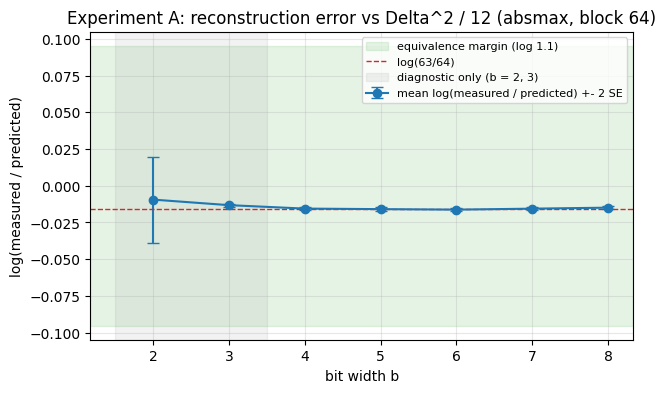

In [14]:
def reconstruction_error(w: torch.Tensor, q) -> float:
    return float(((w.double() - q.dequantize().double()) ** 2).mean())


experiment_a = {}  # ビット幅 -> 行列ごとの実測値・予測値
for _bits in BITS_DIAGNOSTIC_A + BITS_JUDGED_A:
    _rows = {}
    for _name in TARGET_NAMES:
        _q = quantize_weight(
            TARGET_WEIGHTS[_name],
            method="absmax",
            bits=_bits,
            granularity="block",
            block_size=BLOCK_SIZE,
        )
        _rows[_name] = {
            "measured": reconstruction_error(TARGET_WEIGHTS[_name], _q),
            "predicted": float((_q.scale.double() ** 2).mean() / 12),
        }
    experiment_a[_bits] = _rows


def mean_and_standard_error(values: np.ndarray) -> tuple[float, float]:
    return float(values.mean()), float(values.std(ddof=1) / math.sqrt(len(values)))


def equivalence_verdict(mean: float, se: float, margin: float) -> str:
    lo, hi = mean - 2 * se, mean + 2 * se
    if -margin <= lo and hi <= margin:
        return "支持"
    if lo > margin or hi < -margin:
        return "反証"
    return "判定不能"


summary_a = {}
print(
    f"{_smoke_tag}同等性の範囲: [-log 1.1, log 1.1] = [{-EQUIVALENCE_MARGIN_A:+.4f}, {EQUIVALENCE_MARGIN_A:+.4f}]"
)
print(f"{'b':>2} | {'r_bar':>9} | {'SE':>8} | {'r_bar - 2SE':>11} | {'r_bar + 2SE':>11} | 判定")
for _bits, _rows in experiment_a.items():
    _r = np.array([math.log(v["measured"] / v["predicted"]) for v in _rows.values()])
    assert len(_r) == NUM_TARGET_MATRICES
    _mean, _se = mean_and_standard_error(_r)
    _v = equivalence_verdict(_mean, _se, EQUIVALENCE_MARGIN_A)
    summary_a[_bits] = {"r_bar": _mean, "se": _se, "verdict": _v, "judged": _bits in BITS_JUDGED_A}
    _tag = "" if _bits in BITS_JUDGED_A else "(診断量、判定に使わない)"
    print(
        f"{_bits:>2} | {_mean:>+9.5f} | {_se:>8.5f} | {_mean - 2 * _se:>+11.5f} | {_mean + 2 * _se:>+11.5f} | {_v}{_tag}"
    )

# 診断量: 第 1 段階のスモークテストの出力(小数第 5 位まで印字した値)から転記した r_bar との差。
# 実験 A は決定的な計算なので、同じ実行環境なら丸めの範囲(5e-6)で一致する。
_R_BAR_SMOKE = {
    2: -0.00945,
    3: -0.01322,
    4: -0.01557,
    5: -0.01594,
    6: -0.01628,
    7: -0.01562,
    8: -0.01494,
}
for _bits in summary_a:
    print(
        f"診断量: b={_bits} の r_bar - スモークテストの転記値 = "
        f"{summary_a[_bits]['r_bar'] - _R_BAR_SMOKE[_bits]:+.2e}(転記値 {_R_BAR_SMOKE[_bits]:+.5f})"
    )

_judged = [summary_a[b]["verdict"] for b in BITS_JUDGED_A]
verdict_A = (
    "支持" if all(v == "支持" for v in _judged) else "反証" if "反証" in _judged else "判定不能"
)
print(f"{_smoke_tag}実験 A の判定関数の結果(b = 4〜8 の結合): {verdict_A}")

# 診断量: 系統的なずれの理論値と、隣り合うビット幅の誤差の比
print(
    f"\n{_smoke_tag}診断量: 最大値が誤差 0 で表現されることによるずれの理論値 log(63/64) = {math.log(63 / 64):+.5f}"
)
_all_bits = BITS_DIAGNOSTIC_A + BITS_JUDGED_A
for _b in _all_bits[:-1]:
    _ratio = np.mean(
        [
            experiment_a[_b][n]["measured"] / experiment_a[_b + 1][n]["measured"]
            for n in TARGET_NAMES
        ]
    )
    _theory = ((2**_b - 1) / (2 ** (_b - 1) - 1)) ** 2
    print(
        f"{_smoke_tag}診断量: err_{_b} / err_{_b + 1}(行列平均)= {_ratio:.3f}(理論値 {_theory:.3f})"
    )

fig, ax = plt.subplots(figsize=(7, 4))
_bits_axis = list(summary_a)
_means = [summary_a[b]["r_bar"] for b in _bits_axis]
_errs = [2 * summary_a[b]["se"] for b in _bits_axis]
ax.errorbar(
    _bits_axis,
    _means,
    yerr=_errs,
    marker="o",
    capsize=4,
    label="mean log(measured / predicted) +- 2 SE",
)
ax.axhspan(
    -EQUIVALENCE_MARGIN_A,
    EQUIVALENCE_MARGIN_A,
    color="tab:green",
    alpha=0.12,
    label="equivalence margin (log 1.1)",
)
ax.axhline(math.log(63 / 64), color="tab:red", linestyle="--", linewidth=1, label="log(63/64)")
ax.axvspan(1.5, 3.5, color="gray", alpha=0.1, label="diagnostic only (b = 2, 3)")
ax.set_xlabel("bit width b")
ax.set_ylabel("log(measured / predicted)")
ax.set_title("Experiment A: reconstruction error vs Delta^2 / 12 (absmax, block 64)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

### 6.5 実験 B: 粒度の効果と外れ値(尖度)の関係

前提条件 P-B: 形状の群 {(256, 256): 16, (683, 256): 8, (256, 683): 4} -> 成立
群 (256, 256)(n=16): Spearman 相関 = +0.7559
群 (683, 256)(n=8): Spearman 相関 = +0.2619
群 (256, 683)(n=4): Spearman 相関 = -0.8000
層別 Spearman 相関(群の大きさで重み付け)= +0.3925、ブートストラップ 95% 区間(10,000 回)= [+0.0735, +0.6878]
実験 B の判定関数の結果: 支持
診断量: 群 (256, 256): log(rho) の最小 / 中央値 / 最大 = 0.7216 / 0.9192 / 1.3988、最大絶対値 / 標準偏差 = 3.21 / 3.60 / 4.86
診断量: 群 (683, 256): log(rho) の最小 / 中央値 / 最大 = 1.0154 / 1.2097 / 1.3023、最大絶対値 / 標準偏差 = 4.08 / 4.67 / 4.90
診断量: 群 (256, 683): log(rho) の最小 / 中央値 / 最大 = 1.1772 / 1.2264 / 1.3099、最大絶対値 / 標準偏差 = 4.72 / 4.81 / 5.06

診断量: ブロックサイズの掃引(INT4 absmax、28 行列)
  block=    16: 平均 log(誤差) = -10.7045、実効ビット数 = 6.0000
  block=    32: 平均 log(誤差) = -10.4733、実効ビット数 = 5.0000
  block=    64: 平均 log(誤差) = -10.2893、実効ビット数 = 4.5000
  block=   128: 平均 log(誤差) = -10.1366、実効ビット数 = 4.2500
  block=   256: 平均 log(誤差) = -10.0059、実効ビット数 = 4.1250
  block=   512: 平均 log(誤差) = -9.8811、実効ビット数 = 4.0626
  block=  1024: 平均 log(誤差) = -9.7670、

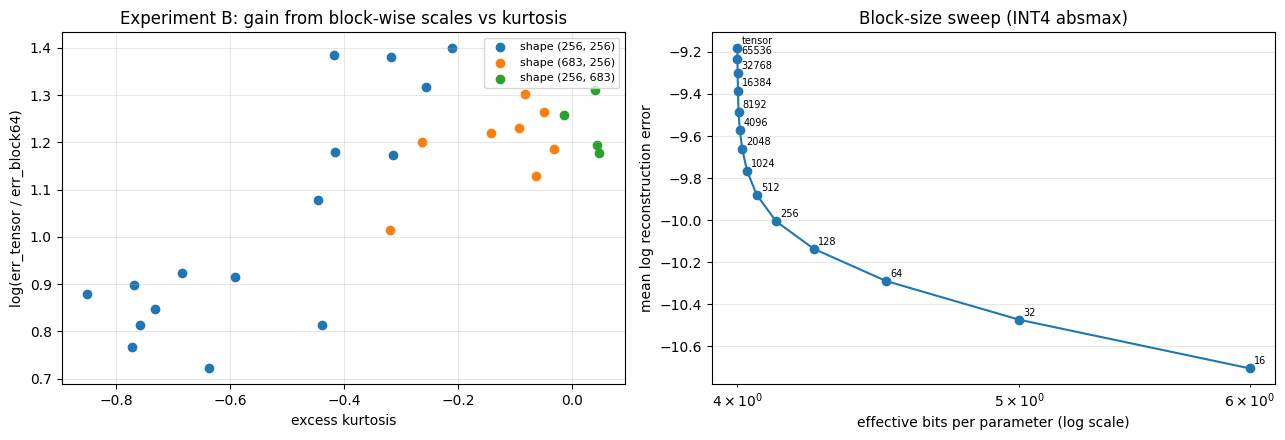

In [15]:
experiment_b = {}
for _name in TARGET_NAMES:
    _w = TARGET_WEIGHTS[_name]
    _err_tensor = reconstruction_error(
        _w, quantize_weight(_w, method="absmax", bits=4, granularity="tensor")
    )
    _err_block = reconstruction_error(
        _w, quantize_weight(_w, method="absmax", bits=4, granularity="block", block_size=BLOCK_SIZE)
    )
    experiment_b[_name] = {
        "shape": list(TARGET_SHAPES[_name]),
        "err_tensor": _err_tensor,
        "err_block64": _err_block,
        "log_rho": math.log(_err_tensor / _err_block),
        "excess_kurtosis": compute_excess_kurtosis(_w),
        "max_abs_over_std": float(_w.abs().max() / _w.std()),
    }

_groups = [tuple(experiment_b[n]["shape"]) for n in TARGET_NAMES]
_group_sizes = {g: _groups.count(g) for g in dict.fromkeys(_groups)}
precondition_status["P-B"] = bool(
    len(_group_sizes) >= PRECONDITION_B_MIN_GROUPS
    and min(_group_sizes.values()) >= PRECONDITION_B_MIN_GROUP_SIZE
)
print(
    f"前提条件 P-B: 形状の群 {_group_sizes} -> {'成立' if precondition_status['P-B'] else '不成立'}"
)

_log_rho = np.array([experiment_b[n]["log_rho"] for n in TARGET_NAMES])
_kurtosis = np.array([experiment_b[n]["excess_kurtosis"] for n in TARGET_NAMES])
stratified_spearman_B = compute_stratified_spearman_correlation(_log_rho, _kurtosis, _groups)
_boot_b = bootstrap_stratified_spearman_correlation(
    _log_rho, _kurtosis, _groups, BOOTSTRAP_RESAMPLES, seed=0
)
assert len(_boot_b) == BOOTSTRAP_RESAMPLES
interval_B = tuple(float(x) for x in np.percentile(_boot_b, [2.5, 97.5]))
verdict_B = "支持" if interval_B[0] > 0 else "反証" if interval_B[1] < 0 else "判定不能"
for _g in _group_sizes:
    _mask = [g == _g for g in _groups]
    _rho_g = compute_stratified_spearman_correlation(
        _log_rho[_mask], _kurtosis[_mask], [_g] * sum(_mask)
    )
    print(f"{_smoke_tag}群 {_g}(n={sum(_mask)}): Spearman 相関 = {_rho_g:+.4f}")
print(
    f"{_smoke_tag}層別 Spearman 相関(群の大きさで重み付け)= {stratified_spearman_B:+.4f}、"
    f"ブートストラップ 95% 区間({BOOTSTRAP_RESAMPLES:,} 回)= [{interval_B[0]:+.4f}, {interval_B[1]:+.4f}]"
)
print(f"{_smoke_tag}実験 B の判定関数の結果: {verdict_B}")
_max_over_std = np.array([experiment_b[n]["max_abs_over_std"] for n in TARGET_NAMES])
for _g in _group_sizes:
    _mask = np.array([g == _g for g in _groups])
    print(
        f"{_smoke_tag}診断量: 群 {_g}: log(rho) の最小 / 中央値 / 最大 = "
        f"{_log_rho[_mask].min():.4f} / {np.median(_log_rho[_mask]):.4f} / {_log_rho[_mask].max():.4f}、"
        f"最大絶対値 / 標準偏差 = {_max_over_std[_mask].min():.2f} / "
        f"{np.median(_max_over_std[_mask]):.2f} / {_max_over_std[_mask].max():.2f}"
    )

# 診断量: ブロックサイズの掃引と実効ビット数
sweep_B = {}
for _block in (*BLOCK_SWEEP_B, "tensor"):
    _errs = []
    for _name in TARGET_NAMES:
        _w = TARGET_WEIGHTS[_name]
        _kw = (
            dict(granularity="tensor")
            if _block == "tensor"
            else dict(granularity="block", block_size=_block)
        )
        _errs.append(reconstruction_error(_w, quantize_weight(_w, method="absmax", bits=4, **_kw)))
    _num_scales = sum(
        1 if _block == "tensor" else -(-w.numel() // _block) for w in TARGET_WEIGHTS.values()
    )
    sweep_B[str(_block)] = {
        "mean_log_error": float(np.mean(np.log(_errs))),
        "effective_bits": 4 + 32 * _num_scales / TARGET_NUM_ELEMENTS,
    }
print(f"\n{_smoke_tag}診断量: ブロックサイズの掃引(INT4 absmax、28 行列)")
for _block, _row in sweep_B.items():
    print(
        f"  block={_block:>6}: 平均 log(誤差) = {_row['mean_log_error']:.4f}、実効ビット数 = {_row['effective_bits']:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for _g in _group_sizes:
    _mask = np.array([g == _g for g in _groups])
    axes[0].scatter(_kurtosis[_mask], _log_rho[_mask], label=f"shape {_g}")
axes[0].set_xlabel("excess kurtosis")
axes[0].set_ylabel("log(err_tensor / err_block64)")
axes[0].set_title("Experiment B: gain from block-wise scales vs kurtosis")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
_eff = [r["effective_bits"] for r in sweep_B.values()]
_err = [r["mean_log_error"] for r in sweep_B.values()]
axes[1].plot(_eff, _err, marker="o")
for _block, _x, _y in zip(sweep_B, _eff, _err, strict=True):
    axes[1].annotate(_block, (_x, _y), fontsize=7, textcoords="offset points", xytext=(3, 3))
axes[1].set_xscale("log")
axes[1].set_xlabel("effective bits per parameter (log scale)")
axes[1].set_ylabel("mean log reconstruction error")
axes[1].set_title("Block-size sweep (INT4 absmax)")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 6.6 実験 C: NF4 と INT4 の再構成誤差

前提条件 P-C: |尖度| の中央値 = 0.3154(閾値 1.0) -> 成立
l_bar = mean log(err_NF4 / err_INT4) = -0.18560、SE = 0.02105、[l_bar - 2SE, l_bar + 2SE] = [-0.22770, -0.14351]
実験 C の判定関数の結果: 支持
診断量: l_bar - スモークテストの転記値 = -3.69e-06(転記値 -0.18560、丸めの範囲は 5e-6)
診断量: mean log(err_q6 / err_q5)(二重量子化による誤差の変化)= +0.000234
診断量: 下流の bits-per-byte の差 b_q5 - b_q4 = -0.00050、b_q6 - b_q5 = -0.00000


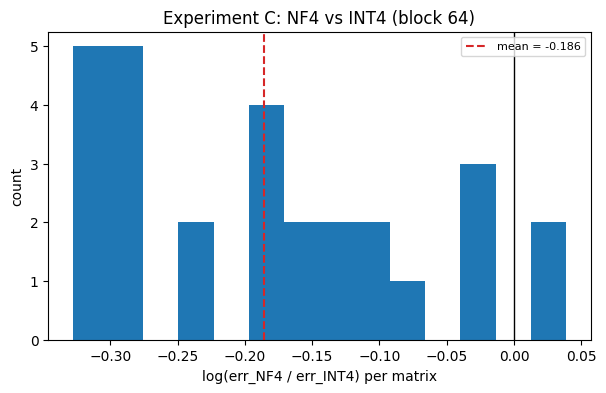

In [16]:
experiment_c = {}
for _name in TARGET_NAMES:
    _w = TARGET_WEIGHTS[_name]
    experiment_c[_name] = {
        "err_nf4": reconstruction_error(_w, QUANTIZED_CACHE["q5"][_name]),
        "err_int4": reconstruction_error(_w, QUANTIZED_CACHE["q4"][_name]),
        "err_nf4_double_quantized": reconstruction_error(_w, QUANTIZED_CACHE["q6"][_name]),
        "excess_kurtosis": experiment_b[_name]["excess_kurtosis"],
    }
_median_abs_kurtosis = float(np.median(np.abs(_kurtosis)))
precondition_status["P-C"] = bool(_median_abs_kurtosis <= PRECONDITION_C_MAX_MEDIAN_ABS_KURTOSIS)
print(
    f"前提条件 P-C: |尖度| の中央値 = {_median_abs_kurtosis:.4f}(閾値 {PRECONDITION_C_MAX_MEDIAN_ABS_KURTOSIS})"
    f" -> {'成立' if precondition_status['P-C'] else '不成立'}"
)
_ell = np.array([math.log(v["err_nf4"] / v["err_int4"]) for v in experiment_c.values()])
ell_mean_C, ell_se_C = mean_and_standard_error(_ell)
verdict_C = (
    "支持"
    if ell_mean_C + 2 * ell_se_C < 0
    else "反証"
    if ell_mean_C - 2 * ell_se_C > 0
    else "判定不能"
)
print(
    f"{_smoke_tag}l_bar = mean log(err_NF4 / err_INT4) = {ell_mean_C:+.5f}、SE = {ell_se_C:.5f}、"
    f"[l_bar - 2SE, l_bar + 2SE] = [{ell_mean_C - 2 * ell_se_C:+.5f}, {ell_mean_C + 2 * ell_se_C:+.5f}]"
)
print(f"{_smoke_tag}実験 C の判定関数の結果: {verdict_C}")
_ELL_BAR_SMOKE = -0.18560  # 第 1 段階のスモークテストの出力から転記(小数第 5 位まで)
print(
    f"診断量: l_bar - スモークテストの転記値 = {ell_mean_C - _ELL_BAR_SMOKE:+.2e}"
    f"(転記値 {_ELL_BAR_SMOKE:+.5f}、丸めの範囲は 5e-6)"
)
_dq = np.array(
    [math.log(v["err_nf4_double_quantized"] / v["err_nf4"]) for v in experiment_c.values()]
)
print(
    f"{_smoke_tag}診断量: mean log(err_q6 / err_q5)(二重量子化による誤差の変化)= {_dq.mean():+.6f}"
)
print(
    f"{_smoke_tag}診断量: 下流の bits-per-byte の差 b_q5 - b_q4 = "
    f"{wiki_bits_per_byte['q5'] - wiki_bits_per_byte['q4']:+.5f}、b_q6 - b_q5 = "
    f"{wiki_bits_per_byte['q6'] - wiki_bits_per_byte['q5']:+.5f}"
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(_ell, bins=14)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(ell_mean_C, color="tab:red", linestyle="--", label=f"mean = {ell_mean_C:+.3f}")
ax.set_xlabel("log(err_NF4 / err_INT4) per matrix")
ax.set_ylabel("count")
ax.set_title("Experiment C: NF4 vs INT4 (block 64)")
ax.legend(fontsize=8)
plt.show()

### 6.7 実験 D: QLoRA による量子化劣化の縮小

微調整前の基盤モデル(条件 1: FP32、条件 2: NF4 + 二重量子化)の評価集合での bits-per-byte と、評価窓の
対応付きブートストラップによる $\sigma_{\mathrm{before}}$ を求めてから、両条件を判定用のシード数で学習する。

In [17]:
_nll_before = {
    cond: per_window_nll(build_quantized_model(cid), evaluation_windows, evaluation_mask)
    for cond, cid in FINETUNE_BASE.items()
}
b_before = {
    cond: evaluate_bits_per_byte(
        build_quantized_model(cid), evaluation_windows, evaluation_mask, evaluation_bytes, device
    )
    for cond, cid in FINETUNE_BASE.items()
}
for _cond in FINETUNE_BASE:
    assert math.isclose(
        bits_per_byte_from_nll(_nll_before[_cond], evaluation_bytes), b_before[_cond], rel_tol=1e-6
    )
DELTA_BEFORE = b_before["nf4"] - b_before["fp32"]
_boot_before = paired_bootstrap_ratio_of_sums(
    np.stack([_nll_before["fp32"], _nll_before["nf4"]]) / LN2,
    evaluation_window_bytes,
    BOOTSTRAP_RESAMPLES,
    seed=1,
)
SIGMA_BEFORE = float((_boot_before[:, 1] - _boot_before[:, 0]).std(ddof=1))
precondition_status["P-D1"] = bool(DELTA_BEFORE > 2 * SIGMA_BEFORE)
print(
    f"{_smoke_tag}微調整前: b(FP32 の基盤)= {b_before['fp32']:.6f}、b(NF4 の基盤)= {b_before['nf4']:.6f}、"
    f"Delta_before = {DELTA_BEFORE:+.6f}、sigma_before = {SIGMA_BEFORE:.6f}"
)
print(
    f"前提条件 P-D1(Delta_before > 2 sigma_before = {2 * SIGMA_BEFORE:.6f}): "
    f"{'成立' if precondition_status['P-D1'] else '不成立'}"
)

finetune_records: dict[str, list[dict]] = {"fp32": [], "nf4": []}
_t0_main = time.time()
for _cond in ("fp32", "nf4"):
    for _seed in SEEDS:
        _t0 = time.time()
        _rec = run_finetune(_cond, _seed)
        finetune_records[_cond].append(_rec)
        print(
            f"[{_cond}] seed={_seed}: b={_rec['final_bits_per_byte']:.4f}, 訓練損失 "
            f"{_rec['initial_train_loss']:.4f} -> {_rec['final_train_loss']:.4f}, "
            f"clipping 発動率={_rec['clip_trigger_ratio']:.2f}({time.time() - _t0:.1f}s)"
        )
print(f"実験 D の学習(2 条件 x {NUM_SEEDS} シード)の合計時間: {time.time() - _t0_main:.1f}s")

微調整前: b(FP32 の基盤)= 3.392751、b(NF4 の基盤)= 3.400214、Delta_before = +0.007463、sigma_before = 0.001035
前提条件 P-D1(Delta_before > 2 sigma_before = 0.002069): 成立
[fp32] seed=0: b=2.6077, 訓練損失 6.2466 -> 4.6590, clipping 発動率=0.10(14.3s)
[fp32] seed=1: b=2.6179, 訓練損失 6.2466 -> 4.6642, clipping 発動率=0.15(14.4s)
[fp32] seed=2: b=2.6007, 訓練損失 6.2466 -> 4.6437, clipping 発動率=0.10(14.4s)
[fp32] seed=3: b=2.6163, 訓練損失 6.2466 -> 4.6788, clipping 発動率=0.20(14.3s)
[fp32] seed=4: b=2.6138, 訓練損失 6.2466 -> 4.6821, clipping 発動率=0.20(14.3s)
[nf4] seed=0: b=2.6150, 訓練損失 6.2553 -> 4.6745, clipping 発動率=0.14(14.4s)
[nf4] seed=1: b=2.6176, 訓練損失 6.2553 -> 4.6706, clipping 発動率=0.14(14.4s)
[nf4] seed=2: b=2.6164, 訓練損失 6.2553 -> 4.6668, clipping 発動率=0.11(14.4s)
[nf4] seed=3: b=2.6126, 訓練損失 6.2553 -> 4.6777, clipping 発動率=0.18(14.5s)
[nf4] seed=4: b=2.6225, 訓練損失 6.2553 -> 4.6909, clipping 発動率=0.21(14.4s)
実験 D の学習(2 条件 x 5 シード)の合計時間: 143.8s


**実験 D の不変条件**: 両条件の全シードで、評価窓(ハッシュ)・評価の分母・ステップ数・学習履歴の長さ・
LoRA の置換先・学習可能パラメータ数が同一であること、エポック上限を満たすこと、`SMOKE_TEST`の水準どおりの
シードで実行されたこと、基盤モデル自体が変化していないことを確認する。

実験 D の不変条件(評価窓・分母 55,769 バイト・ステップ数 87・LoRA のパラメータ数 32,768・エポック上限・シード (0, 1, 2, 3, 4)・基盤モデルの不変): OK
b1(FP32 + LoRA)= 2.611257(sigma_1 = 0.007078)、b2(NF4 + LoRA)= 2.616811(sigma_2 = 0.003656)、n = 5
シードごとの差 d_s = b2_s - b1_s: +0.007357, -0.000326, +0.015692, -0.003666, +0.008710
Delta_before = +0.007463、Delta_after = mean(d_s) = +0.005553、c = +0.001910
新基準: s_d = 0.007674、sigma_win_c = 0.001541(ブートストラップ 10,000 回)、sigma_c = 0.003762、2 sigma_c = 0.007524 -> 判定関数の結果: 判定不能
旧基準(参考、判定には使わない): sigma_c = 0.003710、2 sigma_c = 0.007420 -> 判定関数の結果: 判定不能
前提条件 P-D2(全シードで最終訓練損失 <= 0.95 x 学習開始時): 成立
診断量: 回復率 1 - Delta_after / Delta_before = 0.2559
診断量: 基盤の重み(量子化対象の 28 行列)の格納バイト数 FP32 12,587,008 / NF4 + 二重量子化 1,623,440(比 0.1290)
診断量: 学習中の最大 GPU メモリ [fp32]: 1886.3 MB, 1886.3 MB, 1886.3 MB, 1886.3 MB, 1886.3 MB
診断量: 学習中の最大 GPU メモリ [nf4]: 1887.1 MB, 1887.1 MB, 1887.1 MB, 1887.1 MB, 1887.1 MB
診断量: FP32 の基盤の b = 3.3927508812(012 の b0 = 3.3927508812、差 +0.00e+00)
診断量: 条件 1 seed=0: b = 2.6076661272(012 の記録値 2.60

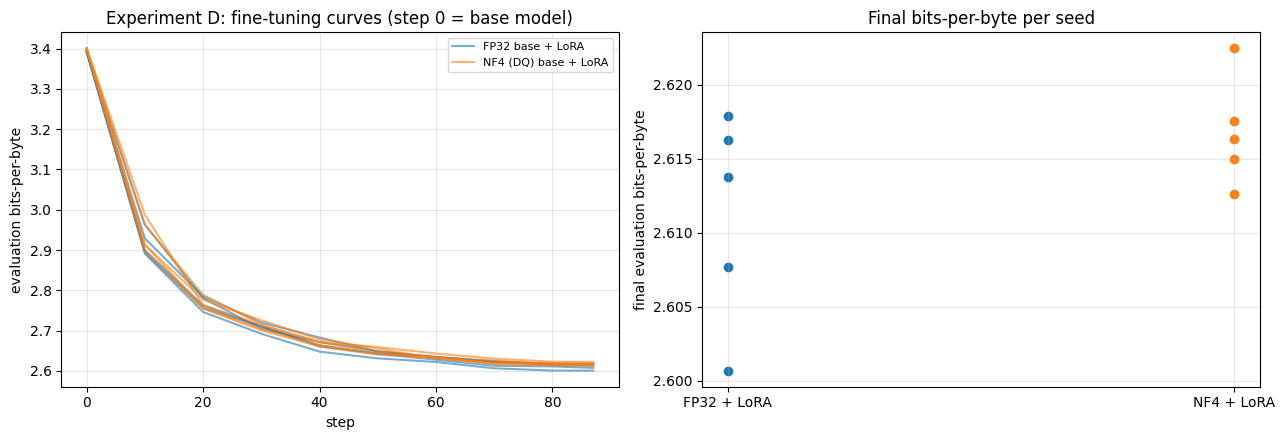

In [18]:
_all_d = finetune_records["fp32"] + finetune_records["nf4"]
_expected_lora = 2 * NUM_LAYERS * compute_lora_parameter_count(D_MODEL, D_MODEL, LORA_RANK)
for _r in _all_d:
    assert _r["evaluation_windows_hash"] == EVALUATION_WINDOWS_HASH
    assert _r["evaluation_denominator_bytes"] == EXPECTED_EVALUATION_BYTES
    assert _r["num_steps"] == NUM_STEPS and _r["history_length"] == NUM_STEPS
    assert _r["eval_step"][-1] == NUM_STEPS
    assert _r["num_trainable_parameters"] == _expected_lora
    assert _r["replaced"] == finetune_records["fp32"][0]["replaced"]
    assert _r["num_steps"] * TOKENS_PER_STEP <= EPOCHS * len(train_ids)
for _cond, _rs in finetune_records.items():
    assert [r["seed"] for r in _rs] == list(SEEDS), "シードが実効水準と一致しない"
    assert all(r["initial_train_loss"] == INITIAL_TRAIN_LOSS[_cond] for r in _rs)
assert hash_state(base_model.state_dict()) == BASE_STATE_HASH
print(
    f"実験 D の不変条件(評価窓・分母 {EXPECTED_EVALUATION_BYTES:,} バイト・ステップ数 {NUM_STEPS}・"
    f"LoRA のパラメータ数 {_expected_lora:,}・エポック上限・シード {SEEDS}・基盤モデルの不変): OK"
)

_b1 = np.array([r["final_bits_per_byte"] for r in finetune_records["fp32"]])
_b2 = np.array([r["final_bits_per_byte"] for r in finetune_records["nf4"]])
_n = len(SEEDS)
assert [r["seed"] for r in finetune_records["fp32"]] == [r["seed"] for r in finetune_records["nf4"]]
_d = _b2 - _b1  # シードごとの差 d_s(同じシードどうしの対応)
DELTA_AFTER = float(_d.mean())
assert math.isclose(DELTA_AFTER, float(_b2.mean() - _b1.mean()), rel_tol=1e-9, abs_tol=1e-12)
C_D = DELTA_BEFORE - DELTA_AFTER

# 新基準: sigma_c = sqrt(s_d^2 / n + sigma_win_c^2)
S_D = float(_d.std(ddof=1))
_mean_nll_after = {
    cond: np.mean([r["evaluation_window_nll"] for r in finetune_records[cond]], axis=0)
    for cond in ("fp32", "nf4")
}
_four_numerators = (
    np.stack(
        [_nll_before["fp32"], _nll_before["nf4"], _mean_nll_after["fp32"], _mean_nll_after["nf4"]]
    )
    / LN2
)
# 全標本で計算した c^* は c と一致する(シード平均した窓ごとの負の対数尤度の比 = シード平均の bits-per-byte)
_c_full = (
    (_four_numerators[1].sum() - _four_numerators[0].sum())
    - (_four_numerators[3].sum() - _four_numerators[2].sum())
) / evaluation_window_bytes.sum()
# c は evaluate_bits_per_byte(バッチごとの FP32 の和)の値から、_c_full は窓ごとの和から作るので、
# 4 つの bits-per-byte それぞれの相対誤差 1e-6(約 3.5e-6)の和を許容誤差とする。
assert math.isclose(_c_full, C_D, rel_tol=0, abs_tol=1.5e-5), (_c_full, C_D)
_boot_c = paired_bootstrap_ratio_of_sums(
    _four_numerators, evaluation_window_bytes, BOOTSTRAP_RESAMPLES, seed=2
)
assert _boot_c.shape == (BOOTSTRAP_RESAMPLES, 4)
_c_star = (_boot_c[:, 1] - _boot_c[:, 0]) - (_boot_c[:, 3] - _boot_c[:, 2])
SIGMA_WIN_C = float(_c_star.std(ddof=1))
SIGMA_C_D = math.sqrt(S_D**2 / _n + SIGMA_WIN_C**2)
verdict_D = "支持" if C_D > 2 * SIGMA_C_D else "反証" if C_D < -2 * SIGMA_C_D else "判定不能"

# 旧基準(参考、判定には使わない): sigma_c = sqrt(sigma_1^2 / n + sigma_2^2 / n + sigma_before^2)
SIGMA_1, SIGMA_2 = float(_b1.std(ddof=1)), float(_b2.std(ddof=1))
SIGMA_C_D_OLD = math.sqrt(SIGMA_1**2 / _n + SIGMA_2**2 / _n + SIGMA_BEFORE**2)
verdict_D_old = (
    "支持" if C_D > 2 * SIGMA_C_D_OLD else "反証" if C_D < -2 * SIGMA_C_D_OLD else "判定不能"
)

precondition_status["P-D2"] = all(
    r["final_train_loss"] <= (1 - PRECONDITION_TRAIN_LOSS_DROP) * r["initial_train_loss"]
    for r in _all_d
)
print(
    f"{_smoke_tag}b1(FP32 + LoRA)= {_b1.mean():.6f}(sigma_1 = {SIGMA_1:.6f})、"
    f"b2(NF4 + LoRA)= {_b2.mean():.6f}(sigma_2 = {SIGMA_2:.6f})、n = {_n}"
)
print(f"{_smoke_tag}シードごとの差 d_s = b2_s - b1_s: " + ", ".join(f"{x:+.6f}" for x in _d))
print(
    f"{_smoke_tag}Delta_before = {DELTA_BEFORE:+.6f}、Delta_after = mean(d_s) = {DELTA_AFTER:+.6f}、"
    f"c = {C_D:+.6f}"
)
print(
    f"{_smoke_tag}新基準: s_d = {S_D:.6f}、sigma_win_c = {SIGMA_WIN_C:.6f}"
    f"(ブートストラップ {BOOTSTRAP_RESAMPLES:,} 回)、sigma_c = {SIGMA_C_D:.6f}、"
    f"2 sigma_c = {2 * SIGMA_C_D:.6f} -> 判定関数の結果: {verdict_D}"
)
print(
    f"{_smoke_tag}旧基準(参考、判定には使わない): sigma_c = {SIGMA_C_D_OLD:.6f}、"
    f"2 sigma_c = {2 * SIGMA_C_D_OLD:.6f} -> 判定関数の結果: {verdict_D_old}"
)
print(
    "前提条件 P-D2(全シードで最終訓練損失 <= 0.95 x 学習開始時): "
    f"{'成立' if precondition_status['P-D2'] else '不成立'}"
)

# 診断量
_recovery = 1 - DELTA_AFTER / DELTA_BEFORE if DELTA_BEFORE != 0 else float("nan")
print(f"{_smoke_tag}診断量: 回復率 1 - Delta_after / Delta_before = {_recovery:.4f}")
print(
    f"{_smoke_tag}診断量: 基盤の重み(量子化対象の 28 行列)の格納バイト数 FP32 {storage_table['q0']:,} / "
    f"NF4 + 二重量子化 {storage_table['q6']:,}(比 {storage_table['q6'] / storage_table['q0']:.4f})"
)
if device.type == "cuda":
    for _cond, _rs in finetune_records.items():
        _peaks = [r["peak_gpu_memory_bytes"] / 2**20 for r in _rs]
        print(
            f"{_smoke_tag}診断量: 学習中の最大 GPU メモリ [{_cond}]: "
            + ", ".join(f"{p:.1f} MB" for p in _peaks)
        )
else:
    print(f"CUDA 環境ではない({device})ため、学習中の最大 GPU メモリは記録していない。")
# 012 のセル出力(6.7 節の判定の一次情報)から転記した、LoRA(r = 8)のシード 0〜4 の値と FP32 の基盤の b0
_B2_012 = [
    2.607666127234919,
    2.617892988033689,
    2.600680119165922,
    2.616290870893274,
    2.6137570138035047,
]
_B0_012 = 3.3927508811831832
print(
    f"{_smoke_tag}診断量: FP32 の基盤の b = {b_before['fp32']:.10f}(012 の b0 = {_B0_012:.10f}、差 {b_before['fp32'] - _B0_012:+.2e})"
)
for _r in finetune_records["fp32"]:
    print(
        f"{_smoke_tag}診断量: 条件 1 seed={_r['seed']}: b = {_r['final_bits_per_byte']:.10f}"
        f"(012 の記録値 {_B2_012[_r['seed']]:.10f}、差 {_r['final_bits_per_byte'] - _B2_012[_r['seed']]:+.2e})"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for _cond, _color, _label in (
    ("fp32", "tab:blue", "FP32 base + LoRA"),
    ("nf4", "tab:orange", "NF4 (DQ) base + LoRA"),
):
    for _i, _r in enumerate(finetune_records[_cond]):
        axes[0].plot(
            [0] + _r["eval_step"],
            [b_before[_cond]] + _r["eval_bits_per_byte"],
            color=_color,
            alpha=0.6,
            label=_label if _i == 0 else None,
        )
axes[0].set_xlabel("step")
axes[0].set_ylabel("evaluation bits-per-byte")
axes[0].set_title("Experiment D: fine-tuning curves (step 0 = base model)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[1].scatter(np.zeros(_n), _b1, label="condition 1 (FP32)")
axes[1].scatter(np.ones(_n), _b2, label="condition 2 (NF4)")
axes[1].set_xticks([0, 1], ["FP32 + LoRA", "NF4 + LoRA"])
axes[1].set_ylabel("final evaluation bits-per-byte")
axes[1].set_title("Final bits-per-byte per seed")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 6.8 観察: LLM.int8() の外れ値の特徴次元(判定基準を設けない)

FP32 の基盤モデルの各層で、量子化対象の行列への入力を forward pre-hook で記録する。同じ入力を受け取る行列
(Query・Key・Value の射影、SwiGLU の 2 つの入力側の行列)は 1 回だけ記録する。

L0.attention_input                         特徴次元 256: 最大絶対値 4.58、大きさ 6 以上の値を持つ特徴次元 0
L0.attention_output_projection_input       特徴次元 256: 最大絶対値 6.20、大きさ 6 以上の値を持つ特徴次元 2
L0.feed_forward_input                      特徴次元 256: 最大絶対値 4.07、大きさ 6 以上の値を持つ特徴次元 0
L0.feed_forward_output_projection_input    特徴次元 683: 最大絶対値 16.64、大きさ 6 以上の値を持つ特徴次元 219
L1.attention_input                         特徴次元 256: 最大絶対値 5.13、大きさ 6 以上の値を持つ特徴次元 0
L1.attention_output_projection_input       特徴次元 256: 最大絶対値 4.18、大きさ 6 以上の値を持つ特徴次元 0
L1.feed_forward_input                      特徴次元 256: 最大絶対値 4.75、大きさ 6 以上の値を持つ特徴次元 0
L1.feed_forward_output_projection_input    特徴次元 683: 最大絶対値 22.93、大きさ 6 以上の値を持つ特徴次元 497
L2.attention_input                         特徴次元 256: 最大絶対値 3.90、大きさ 6 以上の値を持つ特徴次元 0
L2.attention_output_projection_input       特徴次元 256: 最大絶対値 4.54、大きさ 6 以上の値を持つ特徴次元 0
L2.feed_forward_input                      特徴次元 256: 最大絶対値 4.91、大きさ 6 以上の値を持つ特徴次元 0
L2.feed_forward_output_projection_input    特徴次元 683: 最大絶対値 23.89、大きさ 6

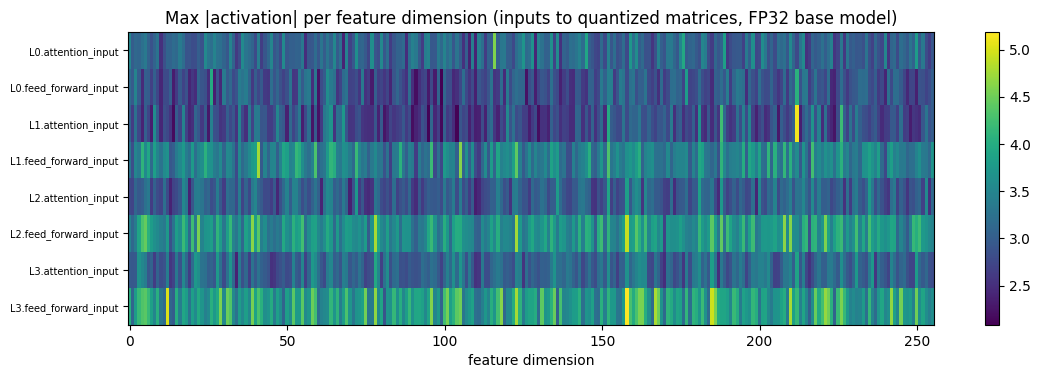

In [19]:
_hooked = {}  # 隠れ状態の名前 -> 記録するモジュールの名前
for _layer in range(NUM_LAYERS):
    _hooked[f"L{_layer}.attention_input"] = f"{_layer}.self_attn.w_q"
    _hooked[f"L{_layer}.attention_output_projection_input"] = f"{_layer}.self_attn.w_o"
    _hooked[f"L{_layer}.feed_forward_input"] = f"{_layer}.feed_forward.w"
    _hooked[f"L{_layer}.feed_forward_output_projection_input"] = f"{_layer}.feed_forward.w2"
_captured: dict[str, list[torch.Tensor]] = {k: [] for k in _hooked}
_handles = [
    base_model.blocks.get_submodule(module_name).register_forward_pre_hook(
        lambda _m, inputs, key=key: _captured[key].append(inputs[0].detach().float().cpu())
    )
    for key, module_name in _hooked.items()
]
_obs_windows, _obs_mask = wiki_windows[:OBSERVATION_WINDOWS], wiki_mask[:OBSERVATION_WINDOWS]
try:
    with torch.no_grad():
        for _s in range(0, OBSERVATION_WINDOWS, 16):
            base_model(_obs_windows[_s : _s + 16].to(device))
finally:
    for _h in _handles:
        _h.remove()
_token_mask = _obs_mask.reshape(-1)
hidden_states = {
    k: torch.cat(v).reshape(-1, v[0].size(-1))[_token_mask] for k, v in _captured.items()
}
assert all(h.size(0) == int(_token_mask.sum()) for h in hidden_states.values())

observation = {}
for _key, _h in hidden_states.items():
    _max_abs = _h.abs().amax(dim=0)
    observation[_key] = {
        "num_features": _h.size(1),
        "max_abs": float(_max_abs.max()),
        "num_features_at_least_6": int((_max_abs >= OUTLIER_MAGNITUDE).sum()),
        "top5_feature_max_abs": [float(x) for x in _max_abs.topk(5).values],
    }
    print(
        f"{_key:<42} 特徴次元 {_h.size(1)}: 最大絶対値 {observation[_key]['max_abs']:.2f}、"
        f"大きさ 6 以上の値を持つ特徴次元 {observation[_key]['num_features_at_least_6']}"
    )

# 原論文の基準: d_model 次元の隠れ状態(注意機構の入力・SwiGLU の入力、各層 2 つ)について
_criterion_keys = [
    k for k in hidden_states if k.endswith(("attention_input", "feed_forward_input"))
]
_stack = torch.stack(
    [hidden_states[k].abs() >= OUTLIER_MAGNITUDE for k in _criterion_keys]
)  # (H, T, d)
_layer_fraction = (
    _stack.any(dim=1).float().mean(dim=0)
)  # 特徴次元ごと: その次元が 6 以上になる隠れ状態の割合
_position_fraction = (
    _stack.any(dim=0).float().mean(dim=0)
)  # 特徴次元ごと: いずれかの隠れ状態で 6 以上の位置の割合
_outlier_features = torch.nonzero(
    (_layer_fraction >= OUTLIER_LAYER_FRACTION) & (_position_fraction >= OUTLIER_POSITION_FRACTION)
).flatten()
observation["criterion"] = {
    "hidden_states": _criterion_keys,
    "num_tokens": int(_token_mask.sum()),
    "outlier_features": _outlier_features.tolist(),
    "layer_fraction_of_outlier_features": [float(_layer_fraction[i]) for i in _outlier_features],
    "position_fraction_of_outlier_features": [
        float(_position_fraction[i]) for i in _outlier_features
    ],
    "max_layer_fraction": float(_layer_fraction.max()),
    "max_position_fraction": float(_position_fraction.max()),
}
print(
    f"\n原論文の基準(大きさ >= {OUTLIER_MAGNITUDE}、隠れ状態の >= {OUTLIER_LAYER_FRACTION:.0%}、"
    f"系列位置の >= {OUTLIER_POSITION_FRACTION:.0%})を満たす特徴次元: {observation['criterion']['outlier_features']}"
    f"(隠れ状態の割合の最大 {observation['criterion']['max_layer_fraction']:.3f}、"
    f"系列位置の割合の最大 {observation['criterion']['max_position_fraction']:.4f})"
)

fig, ax = plt.subplots(figsize=(13, 3.8))
_matrix = torch.stack([hidden_states[k].abs().amax(dim=0) for k in _criterion_keys]).numpy()
_im = ax.imshow(_matrix, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(_criterion_keys)), _criterion_keys, fontsize=7)
ax.set_xlabel("feature dimension")
ax.set_title(
    "Max |activation| per feature dimension (inputs to quantized matrices, FP32 base model)"
)
fig.colorbar(_im, ax=ax)
plt.show()

### 6.9 判定の一次情報(全件)

判定の一次情報(事前宣言した判定基準の対比量と前提条件を再計算できる最小の量)を全件印字する。

- `P0`: 起点モデルの bits-per-byte と 008 の記録値。
- `per_matrix`(実験 A・B・C 共通、列の形): 28 行列の名前(以下の全配列の順序)、形状の群の定義と行列ごとの群の
  番号、尖度、INT4・テンソル単位の誤差、INT4・ブロック 64 の誤差(実験 A の $b = 4$ の実測値・実験 B・実験 C で共通)、
  NF4・ブロック 64 の誤差、実験 A の $b = 4, \dots, 8$ の予測値と $b = 5, \dots, 8$ の実測値。
- `experiment_D`: 微調整前の基盤モデルの bits-per-byte・$\Delta_{\mathrm{before}}$・ブートストラップ標準偏差
  ($\sigma_{\mathrm{before}}$・$\sigma_{\mathrm{win},c}$)、評価窓ごとのバイト数、微調整前の基盤モデルの評価窓ごとの負の対数尤度、
  条件ごとの評価窓ごとの負の対数尤度のシード平均、条件ごと・シードごとの最終 bits-per-byte・学習開始時と最終の
  訓練損失。

**実験 D の評価窓ごとの値をシード平均に絞る根拠**: $\sigma_{\mathrm{win},c}$ と $c^*$ は、定義上、窓ごとにシード平均した
負の対数尤度から計算する。$c$ は、全シードで評価窓の分母(窓ごとの UTF-8 バイト数)が共通なので、シード平均の窓の値から
再計算できる。$s_d$ と前提条件 P-D2 は、シードごとのスカラー(最終 bits-per-byte・訓練損失)から再計算する。シードごとの
窓の値は、判定基準のどの対比量にも使われないので印字しない(印字の前に、シードごとの窓の値の総和が各シードの最終
bits-per-byte と一致すること、シード平均の窓の値から求めた bits-per-byte がシードごとの値の平均と一致することを確認する)。

**判定に使わない診断量と、他の値から計算できる量は含めない。** それらは次の節で印字している。

| 外した量 | 理由 | 印字している節 |
|---|---|---|
| 実験 A の $b = 2, 3$ | 診断量 | 6.4 節($\bar{r}$ の表、隣り合うビット幅の誤差の比) |
| 実験 B の $\log \rho_m$ | INT4 のテンソル単位・ブロック 64 の誤差から計算できる | 6.5 節(群ごとの最小・中央値・最大、散布図) |
| 実験 B の最大絶対値 / 標準偏差 | 診断量 | 6.5 節(群ごとの最小・中央値・最大) |
| 実験 C の二重量子化した NF4 の誤差 | 診断量 | 6.6 節(誤差の比の平均) |
| 英語 Wikipedia の検証集合の bits-per-byte(7 条件) | 診断量 | 6.3 節(表) |

**一次情報だけからの再計算**: 印字の直後に、印字した文字列を JSON として読み戻したデータのみを使って、P0 の
相対誤差、実験 A の各ビット幅の $\bar{r}$ と SE、実験 B の群ごとの Spearman 相関と層別の点推定 $\bar{\rho}^{\mathrm{S}}$
(ブートストラップ区間は乱数に依存するので点推定のみ)、前提条件 P-B・P-C、実験 C の $\bar{\ell}$ と SE、実験 D の
$\Delta_{\mathrm{before}}$・$\Delta_{\mathrm{after}}$・$c$・$s_d$、前提条件 P-D2、シード平均の窓の値から求めた全標本の
$c^*$($c$ と一致すること)を再計算し、判定に使った値と
一致することをアサーションで確認する。これは、この出力が対比量を再計算できる一次情報であることの保証である。

In [20]:
def primary_finetune(r: dict) -> dict:
    return {
        "seed": r["seed"],
        "final_bits_per_byte": r["final_bits_per_byte"],
        "initial_train_loss": r["initial_train_loss"],
        "final_train_loss": r["final_train_loss"],
    }


# 実験 D: 評価窓ごとの負の対数尤度はシード平均の配列だけを印字する(シードごとの窓の値は印字しない)。
# 印字しないシードごとの値を使って、シード平均の配列が条件ごとの bits-per-byte と整合することを確認する。
for _cond in ("fp32", "nf4"):
    _rs = finetune_records[_cond]
    for (
        _r
    ) in _rs:  # シードごとの窓の値の総和 == 各シードの最終 bits-per-byte(run_finetune と同じ確認)
        assert math.isclose(
            bits_per_byte_from_nll(np.array(_r["evaluation_window_nll"]), evaluation_bytes),
            _r["final_bits_per_byte"],
            rel_tol=1e-6,
        )
    _from_mean = bits_per_byte_from_nll(_mean_nll_after[_cond], evaluation_bytes)
    # 窓ごとのシード平均から求めた値 == シードごとの窓の値から求めた bits-per-byte の平均(線形なので厳密に一致)
    _per_seed = [
        bits_per_byte_from_nll(np.array(r["evaluation_window_nll"]), evaluation_bytes) for r in _rs
    ]
    assert math.isclose(_from_mean, float(np.mean(_per_seed)), rel_tol=1e-9)
    # final_bits_per_byte(evaluate_bits_per_byte の FP32 のバッチごとの和)の平均とは相対 1e-6 以内で一致する
    assert math.isclose(
        _from_mean, float(np.mean([r["final_bits_per_byte"] for r in _rs])), rel_tol=1e-6
    )
print("シード平均の窓の値から求めた bits-per-byte == シードごとの値の平均(2 条件): OK")

_group_labels = list(dict.fromkeys(_groups))  # 形状の群(6.5 節と同じ順序)
_err_int4_block64 = [experiment_c[n]["err_int4"] for n in TARGET_NAMES]
# 重複させない値が実際に同一であることの確認(実験 A の b = 4 の実測値 == 実験 C の INT4 の誤差)
assert _err_int4_block64 == [experiment_a[4][n]["measured"] for n in TARGET_NAMES]
primary_data = {
    "smoke_test": SMOKE_TEST,
    "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
    "P0": {
        "b_P0": B_P0,
        "reference_008": P0_REFERENCE_BITS_PER_BYTE,
        "relative_error": P0_RELATIVE_ERROR,
    },
    "per_matrix": {
        "matrix_names": list(TARGET_NAMES),
        "shape_groups": {
            "definitions": {str(i): list(g) for i, g in enumerate(_group_labels)},
            "index": [_group_labels.index(g) for g in _groups],
        },
        "excess_kurtosis": [experiment_b[n]["excess_kurtosis"] for n in TARGET_NAMES],
        "err_int4_tensor": [experiment_b[n]["err_tensor"] for n in TARGET_NAMES],
        "err_int4_block64": _err_int4_block64,
        "err_nf4_block64": [experiment_c[n]["err_nf4"] for n in TARGET_NAMES],
        "experiment_A": {
            "note": "b = 4 の measured は err_int4_block64 と同一のため重複させない",
            "predicted": {
                str(b): [experiment_a[b][n]["predicted"] for n in TARGET_NAMES]
                for b in BITS_JUDGED_A
            },
            "measured": {
                str(b): [experiment_a[b][n]["measured"] for n in TARGET_NAMES]
                for b in BITS_JUDGED_A
                if b != 4
            },
        },
    },
    "experiment_D": {
        "b_before": b_before,
        "delta_before": DELTA_BEFORE,
        "sigma_before_bootstrap": SIGMA_BEFORE,
        "sigma_window_c_bootstrap": SIGMA_WIN_C,
        "evaluation_window_bytes": evaluation_window_bytes.tolist(),
        "base_evaluation_window_nll": {c: v.tolist() for c, v in _nll_before.items()},
        "condition_1_fp32_seed_mean_window_nll": _mean_nll_after["fp32"].tolist(),
        "condition_2_nf4_seed_mean_window_nll": _mean_nll_after["nf4"].tolist(),
        "condition_1_fp32": [primary_finetune(r) for r in finetune_records["fp32"]],
        "condition_2_nf4": [primary_finetune(r) for r in finetune_records["nf4"]],
    },
}

# 整形関数の確認(ネストした辞書・配列、空の配列・辞書、長い数値の配列、全桁の浮動小数点数)
_probe = {
    "nested": {
        "list": [0.1, 2.220446049250313e-16, -0.0, 1e300],
        "empty_list": [],
        "empty_dict": {},
    },
    "long": [i / 7 for i in range(500)],
    "records": [{"seed": 0, "value": 1 / 3, "flag": True, "none": None}, {"text": "bits-per-byte"}],
    "matrix": [[1, 2, 3], [4.5, 6.75]],
}
_probe_text = dumps_compact_json(_probe)
assert json.loads(_probe_text) == _probe
assert all(len(line) <= 100 for line in _probe_text.splitlines())

PRIMARY_DATA_TEXT = dumps_compact_json(primary_data)
print(PRIMARY_DATA_TEXT)
assert json.loads(PRIMARY_DATA_TEXT) == primary_data, "整形で情報が落ちた"
_long_lines = [len(line) for line in PRIMARY_DATA_TEXT.splitlines() if len(line) > 100]
assert not _long_lines, f"100 文字を超える行がある: {_long_lines[:10]}"
print(
    f"\n判定の一次情報の出力: {len(PRIMARY_DATA_TEXT.splitlines()):,} 行・{len(PRIMARY_DATA_TEXT):,} 文字"
)


# --- 一次情報だけからの再計算(印字した文字列を読み戻したデータのみを使う) ---
def _close(a: float, b: float) -> bool:
    return math.isclose(a, b, rel_tol=1e-9, abs_tol=1e-12)


_loaded = json.loads(PRIMARY_DATA_TEXT)
_pm, _dd = _loaded["per_matrix"], _loaded["experiment_D"]
_p0 = _loaded["P0"]
assert _close(abs(_p0["b_P0"] - _p0["reference_008"]) / _p0["reference_008"], P0_RELATIVE_ERROR)

for _b in BITS_JUDGED_A:
    _meas = _pm["err_int4_block64"] if _b == 4 else _pm["experiment_A"]["measured"][str(_b)]
    _r = np.log(np.array(_meas) / np.array(_pm["experiment_A"]["predicted"][str(_b)]))
    _m, _se = mean_and_standard_error(_r)
    assert _close(_m, summary_a[_b]["r_bar"]) and _close(_se, summary_a[_b]["se"]), _b

_idx = _pm["shape_groups"]["index"]
_lr = np.log(np.array(_pm["err_int4_tensor"]) / np.array(_pm["err_int4_block64"]))
_ku = np.array(_pm["excess_kurtosis"])
for _gi, _shape in _pm["shape_groups"]["definitions"].items():
    _mask = [i == int(_gi) for i in _idx]
    _mask_orig = [g == tuple(_shape) for g in _groups]
    assert _mask == _mask_orig
    _rg = compute_stratified_spearman_correlation(_lr[_mask], _ku[_mask], [_gi] * sum(_mask))
    _rg_orig = compute_stratified_spearman_correlation(
        _log_rho[_mask_orig], _kurtosis[_mask_orig], [_gi] * sum(_mask_orig)
    )
    assert _close(_rg, _rg_orig), _shape
assert _close(compute_stratified_spearman_correlation(_lr, _ku, _idx), stratified_spearman_B)
_counts = [_idx.count(int(g)) for g in _pm["shape_groups"]["definitions"]]
assert (
    len(_counts) >= PRECONDITION_B_MIN_GROUPS and min(_counts) >= PRECONDITION_B_MIN_GROUP_SIZE
) == precondition_status["P-B"]
assert _close(float(np.median(np.abs(_ku))), _median_abs_kurtosis)
assert (
    float(np.median(np.abs(_ku))) <= PRECONDITION_C_MAX_MEDIAN_ABS_KURTOSIS
) == precondition_status["P-C"]
_l = np.log(np.array(_pm["err_nf4_block64"]) / np.array(_pm["err_int4_block64"]))
_m, _se = mean_and_standard_error(_l)
assert _close(_m, ell_mean_C) and _close(_se, ell_se_C)

_bb = _dd["b_before"]
assert _close(_bb["nf4"] - _bb["fp32"], DELTA_BEFORE) and _close(_dd["delta_before"], DELTA_BEFORE)
_c1, _c2 = _dd["condition_1_fp32"], _dd["condition_2_nf4"]
assert [r["seed"] for r in _c1] == [r["seed"] for r in _c2]
_ds = np.array(
    [b["final_bits_per_byte"] - a["final_bits_per_byte"] for a, b in zip(_c1, _c2, strict=True)]
)
assert _close(float(_ds.mean()), DELTA_AFTER)
assert _close(DELTA_BEFORE - float(_ds.mean()), C_D)
assert _close(float(_ds.std(ddof=1)), S_D)
assert (
    all(
        r["final_train_loss"] <= (1 - PRECONDITION_TRAIN_LOSS_DROP) * r["initial_train_loss"]
        for r in _c1 + _c2
    )
    == precondition_status["P-D2"]
)
_bytes = np.array(_dd["evaluation_window_bytes"])
_nb = {k: np.array(v) for k, v in _dd["base_evaluation_window_nll"].items()}
_na = {
    "fp32": np.array(_dd["condition_1_fp32_seed_mean_window_nll"]),
    "nf4": np.array(_dd["condition_2_nf4_seed_mean_window_nll"]),
}
_c_star_full = ((_nb["nf4"].sum() - _nb["fp32"].sum()) - (_na["nf4"].sum() - _na["fp32"].sum())) / (
    LN2 * _bytes.sum()
)
assert math.isclose(_c_star_full, C_D, rel_tol=0, abs_tol=1.5e-5), (_c_star_full, C_D)
print(
    "一次情報だけからの再計算: P0・実験 A の r_bar と SE・実験 B の群ごとと層別の Spearman 相関・P-B・P-C・"
    "実験 C の l_bar と SE・実験 D の Delta_before / Delta_after / c / s_d・P-D2・全標本の c^* が"
    "判定に使った値と一致: OK"
)

シード平均の窓の値から求めた bits-per-byte == シードごとの値の平均(2 条件): OK
{
  "smoke_test": false,
  "bootstrap_resamples": 10000,
  "P0": {
    "b_P0": 1.668067261947532,
    "reference_008": 1.6707,
    "relative_error": 0.001575829324515471
  },
  "per_matrix": {
    "matrix_names": [
      "0.self_attn.w_q", "0.self_attn.w_k", "0.self_attn.w_v", "0.self_attn.w_o",
      "0.feed_forward.w", "0.feed_forward.v", "0.feed_forward.w2", "1.self_attn.w_q",
      "1.self_attn.w_k", "1.self_attn.w_v", "1.self_attn.w_o", "1.feed_forward.w",
      "1.feed_forward.v", "1.feed_forward.w2", "2.self_attn.w_q", "2.self_attn.w_k",
      "2.self_attn.w_v", "2.self_attn.w_o", "2.feed_forward.w", "2.feed_forward.v",
      "2.feed_forward.w2", "3.self_attn.w_q", "3.self_attn.w_k", "3.self_attn.w_v",
      "3.self_attn.w_o", "3.feed_forward.w", "3.feed_forward.v", "3.feed_forward.w2"
    ],
    "shape_groups": {
      "definitions": {
        "0": [256, 256],
        "1": [683, 256],
        "2": [256, 683]
      },
      "i

### 6.10 判定結果の一覧

前提条件が 1 つでも不成立の実験は、判定関数の結果に関わらず「前提不成立」とする(判定不能とは区別する)。
判定関数の結果は参考として別欄に残す。実験 D は新基準(6.1 節)で判定し、旧基準による結果は参考として別の行に
示す。あわせて、`SMOKE_TEST`の水準が実際に使われた値と一致することを確認する。

In [21]:
# SMOKE_TEST の配線: 実際に使われた反復回数・シード数・学習履歴の長さの照合
assert len(_wiki_boot) == len(_boot_before) == len(_boot_b) == len(_boot_c) == BOOTSTRAP_RESAMPLES
assert all(len(rs) == NUM_SEEDS for rs in finetune_records.values())
assert all(r["history_length"] == NUM_STEPS for r in _all_d)
print(
    f"SMOKE_TEST の配線: ブートストラップ {BOOTSTRAP_RESAMPLES:,} 回・シード数 {NUM_SEEDS}・"
    f"学習履歴の長さ {NUM_STEPS} が実効水準と一致: OK"
)

_experiment_preconditions = {
    "A": ["P0"],
    "B": ["P0", "P-B"],
    "C": ["P0", "P-C"],
    "D": ["P0", "P-D1", "P-D2"],
}
_verdicts = [
    (
        "A",
        ", ".join(
            f"b={b}: r_bar={summary_a[b]['r_bar']:+.4f}(SE {summary_a[b]['se']:.4f})"
            for b in BITS_JUDGED_A
        ),
        verdict_A,
    ),
    (
        "B",
        f"層別 Spearman={stratified_spearman_B:+.4f}、95% 区間=[{interval_B[0]:+.4f}, {interval_B[1]:+.4f}]",
        verdict_B,
    ),
    ("C", f"l_bar={ell_mean_C:+.5f}、SE={ell_se_C:.5f}", verdict_C),
    ("D", f"c={C_D:+.6f}、sigma_c={SIGMA_C_D:.6f}(新基準)", verdict_D),
]
print(f"\n{_smoke_tag}実験 | 対比量 | 前提条件の成否 | 判定関数の結果(参考) | 最終判定")
for _name, _stat, _computed in _verdicts:
    _pre = ", ".join(f"{p}={precondition_status.get(p)}" for p in _experiment_preconditions[_name])
    print(
        f"{_smoke_tag}{_name} | {_stat} | {_pre} | {_computed} | {verdict_label(_computed, _experiment_preconditions[_name])}"
    )
_pre_d = ", ".join(f"{p}={precondition_status.get(p)}" for p in _experiment_preconditions["D"])
print(
    f"{_smoke_tag}D(旧基準、参考、判定には使わない) | c={C_D:+.6f}、sigma_c={SIGMA_C_D_OLD:.6f} | "
    f"{_pre_d} | {verdict_D_old} | {verdict_label(verdict_D_old, _experiment_preconditions['D'])}(参考)"
)

SMOKE_TEST の配線: ブートストラップ 10,000 回・シード数 5・学習履歴の長さ 87 が実効水準と一致: OK

実験 | 対比量 | 前提条件の成否 | 判定関数の結果(参考) | 最終判定
A | b=4: r_bar=-0.0156(SE 0.0006), b=5: r_bar=-0.0159(SE 0.0006), b=6: r_bar=-0.0163(SE 0.0005), b=7: r_bar=-0.0156(SE 0.0005), b=8: r_bar=-0.0149(SE 0.0006) | P0=True | 支持 | 支持
B | 層別 Spearman=+0.3925、95% 区間=[+0.0735, +0.6878] | P0=True, P-B=True | 支持 | 支持
C | l_bar=-0.18560、SE=0.02105 | P0=True, P-C=True | 支持 | 支持
D | c=+0.001910、sigma_c=0.003762(新基準) | P0=True, P-D1=True, P-D2=True | 判定不能 | 判定不能
D(旧基準、参考、判定には使わない) | c=+0.001910、sigma_c=0.003710 | P0=True, P-D1=True, P-D2=True | 判定不能 | 判定不能(参考)


## 7. 結果・考察 / Results and Discussion

本番実行のセル出力に基づいて記す。判定は 6.1 節で事前に宣言した基準のみから導く。結果を見た後に立てた解釈は
「事後的な解釈」として節または段落を分けて記し、検証済みの結論としては扱わない。

**実行環境**: Google Colab の T4 GPU(GPU の名前はセル出力に印字していないため、実行者の記録による)、
torch 2.13.0+cu130(5.1 節のセル出力)、`SMOKE_TEST=False`。

**本番実行のやり直しの結果**: 6.1 節の補足のとおり、6.9 節の出力の書式のみを修正して本番実行をやり直した。やり直した
実行の 6.10 節の判定一覧は、初回の本番実行と一致した。印字した桁だけでなく、判定の一次情報(6.9 節)の全数値も、
初回の本番実行のセル出力と比べて浮動小数点数の全桁で一致した。比較の対象は、初回の本番実行の出力を含む
コミット`ad184f8`のセル出力である。この比較はノートブックの外で行ったものであり、このノートブックのセル出力には
含まれない。実験 D の微調整後の値も一致しており、6.1 節の補足で予期した「GPU の非決定性により変わりうる」ことは起きなかった。

**012 との一致(実行環境の再現性の確認)**: FP32 の基盤の Tiny Shakespeare の評価集合での bits-per-byte
(3.3927508812)と、条件 1(FP32 の基盤 + LoRA)の 5 シードの最終 bits-per-byte は、012 のセル出力の記録値と
差 0 で一致した(6.7 節の診断量)。

### 7.1 前提条件の成否

宣言したすべての前提条件が成立した。7.3〜7.6 節の判定に「前提不成立」の実験はない。

| 前提条件 | 評価に使った量 | 閾値 | 成否 |
|---|---|---|---|
| P0 | $b_{\mathrm{P0}} = 1.668067$、008 の記録値 1.6707 との相対誤差 0.1576% | 1% 以下 | 成立 |
| P-B | 形状の群 3 つ(16・8・4 行列) | 2 群以上、各群 3 行列以上 | 成立 |
| P-C | 尖度の絶対値の中央値 0.3154 | 1.0 以下 | 成立 |
| P-D1 | $\Delta_{\mathrm{before}} = 0.007463$ | $2\sigma_{\mathrm{before}} = 0.002069$ より大きい | 成立 |
| P-D2 | 最終訓練損失 / 学習開始時の訓練損失(両条件の全シードの最大値、NF4 の seed 4)= 4.6909 / 6.2553 ≈ 0.750 | 0.95 以下 | 成立 |

学習開始時の訓練損失(固定の 64 窓)は、FP32 の基盤で 6.2466、NF4 の基盤で 6.2553 nats / トークンである。

### 7.2 下流の bits-per-byte の増加(診断量)

英語 Wikipedia の検証集合(1240 窓)での値である(6.3 節・5.6 節)。判定基準を設けない診断量である。

| 条件 | bits-per-byte | 増加 | 増加の 95% 区間 | 格納バイト数(28 行列) | 実効ビット数 |
|---|---|---|---|---|---|
| q0: FP32 | 1.668067 | — | — | 12,587,008 | 32.0000 |
| q1: INT8、チャネル単位 | 1.668079 | +0.00001 | [−0.00002, +0.00004] | 3,189,088 | 8.1076 |
| q2: INT8、テンソル単位 | 1.668198 | +0.00013 | [+0.00009, +0.00018] | 3,146,864 | 8.0003 |
| q3: INT4、テンソル単位 | 1.697354 | +0.02929 | [+0.02857, +0.03000] | 1,573,488 | 4.0003 |
| q4: INT4、ブロック 64 | 1.677536 | +0.00947 | [+0.00906, +0.00987] | 1,770,048 | 4.5000 |
| q5: NF4、ブロック 64 | 1.677038 | +0.00897 | [+0.00859, +0.00935] | 1,770,048 | 4.5000 |
| q6: NF4、ブロック 64 + 二重量子化 | 1.677035 | +0.00897 | [+0.00859, +0.00935] | 1,623,440 | 4.1273 |

- INT8 のチャネル単位は、増加の 95% 区間が 0 を含む。この評価集合の標本誤差の範囲では、FP32 と区別できない。
- INT4 のテンソル単位は約 +0.029 の劣化である。ブロック 64 にすると、INT4 で約 +0.0095、NF4 で約 +0.0090 まで縮む
  (いずれも 1 パラメータあたり 0.5 ビットのスケールの格納オーバーヘッドを払っている)。
- 二重量子化は、実効ビット数を 4.5 から 4.127 に下げつつ、bits-per-byte を変えていない(q6 と q5 の差は 0.000003)。

### 7.3 実験 A(ビット幅と再構成誤差の理論値)の判定結果

**判定: 支持。**

| $b$ | $\bar{r}$ | 標準誤差 | $[\bar{r} - 2\,\mathrm{SE},\ \bar{r} + 2\,\mathrm{SE}]$ | 判定 |
|---|---|---|---|---|
| 4 | −0.01557 | 0.00062 | [−0.01682, −0.01432] | 支持 |
| 5 | −0.01594 | 0.00058 | [−0.01710, −0.01477] | 支持 |
| 6 | −0.01628 | 0.00050 | [−0.01727, −0.01528] | 支持 |
| 7 | −0.01562 | 0.00052 | [−0.01665, −0.01458] | 支持 |
| 8 | −0.01494 | 0.00060 | [−0.01613, −0.01374] | 支持 |

5 つのビット幅すべてで、区間が同等性の範囲 $[-\log 1.1, \log 1.1] = [-0.0953, 0.0953]$ に含まれるので、事前に宣言した
基準により **支持** となる。absmax 方式・ブロック 64 の一様量子化の再構成誤差は、$b = 4, \dots, 8$ で理論値
$\overline{\Delta^2} / 12$ と 10% 以内で一致した。

**診断量**:

- $\bar{r}$ はいずれも約 −0.015〜−0.016 で、ブロック内の最大値が誤差 0 で表現されることによる系統的なずれの理論値
  $\log(63/64) \approx -0.01575$(3.3 節)とほぼ一致する。実測値と理論値の差は、主にこの補正で説明される。
- 隣り合うビット幅の誤差の比(行列平均)は、$b = 4 \to 5$ で 4.594(理論値 4.592)、$b = 7 \to 8$ で 4.061(理論値 4.064)
  などで、$b = 3 \to 4$ 以降のすべてで理論値 $\left((2^b - 1) / (2^{b-1} - 1)\right)^2$ との相対差が 0.3% 以内だった。
- $\bar{r}$ はスモークテストの出力から転記した値と、丸めの範囲(5e-6 以内)で一致した。

#### 7.3.1 事後的な解釈(事前宣言した判定とは独立)

**この小節は結果を見た後の観察であり、検証済みの結論ではない。** 3.3 節では、低ビットでは一様誤差の近似そのものが
崩れうると述べた。しかしこのデータでは、診断量の $b = 2$($\bar{r} = -0.0095$、標準誤差 0.0147)・$b = 3$
($\bar{r} = -0.0132$、標準誤差 0.0005)でも理論値からのずれは小さく、隣り合うビット幅の誤差の比も理論値に近かった
($b = 2 \to 3$ で 9.060、理論値 9.000、相対差 0.7%)。$b = 2$ では行列間のばらつき(標準誤差)が他のビット幅より 1 桁以上大きく、
行列によるずれの大きさの違いが大きい。ずれの向きが行列によって異なるかどうかは、$b = 2$ の行列ごとの値を
判定の一次情報に含めていないため、確認していない。これは 1 つのモデルの 28 行列についての観察であり、
「低ビットでも近似が成り立つ」と一般化しない。

### 7.4 実験 B(粒度の効果と外れ値(尖度)の関係)の判定結果

**判定: 支持。**

層別 Spearman 相関(群の大きさで重み付け)は $\bar{\rho}^{\mathrm{S}} = +0.3925$、群の内部で行列を復元抽出するブートストラップ
(10,000 回)の 95% 区間は $[+0.0735, +0.6878]$ で、下限が 0 より大きいので、事前に宣言した基準により **支持** となる。
INT4(absmax 方式)でテンソル単位からブロック 64 に細かくしたときの誤差低減比は、形状が同じ行列の間では、尖度の
大きい行列ほど大きい。

ただし、次の事実をあわせて記す。

- 群ごとの Spearman 相関は、形状 $(256, 256)$ の 16 行列の群が +0.7559、$(683, 256)$ の 8 行列の群が +0.2619、
  $(256, 683)$ の 4 行列の群が −0.8000 とばらつく。層別した値の正の符号は、主に最大の群に支えられている。
- 4 行列の群の相関は取りうる値が粗い(6.1 節で注記した)。4 行列の群だけを見ると符号は逆である。
- 重みの尖度はすべて小さく(尖度の絶対値の中央値 0.32)、この相関は裾の軽い分布の範囲内での関係である。
  大きな外れ値を含む重みでの関係は検証していない。

**診断量(ブロックサイズの掃引、INT4 absmax、28 行列の平均)**: 誤差の対数はブロックを細かくするほど単調に下がり、
スケールの格納オーバーヘッドのぶん実効ビット数が増える。テンソル単位(4.0003 ビット)で −9.183、ブロック 64
(4.5 ビット)で −10.289、ブロック 16(6 ビット)で −10.705 である。

#### 7.4.1 事後的な解釈(事前宣言した判定とは独立)

**この小節は結果を見た後の解釈であり、検証済みの結論ではない。**

- 群ごとの $\log \rho_m$ の中央値は、要素数 65,536 の群で 0.92、要素数 174,848 の 2 群で 1.21・1.23 と、要素数の
  多い群ほど大きい。最大絶対値 / 標準偏差の中央値も 3.60 → 4.67・4.81 と同じ順に大きい。層別の動機とした交絡
  (要素数が多いほど、正規分布でも最大絶対値が大きくなる、3.5 節)と整合する。群を分けずに相関を取れば、この交絡が
  混ざっていたと考えられる。
- ブロックサイズの掃引からは、スケールに使うビットよりも、符号のビット数を増やすほうが誤差の低減の効率がよいことが
  読み取れる。ブロック 64 から 16 に細かくすると、実効ビット数が 1.5 ビット増えて誤差の対数は約 0.42 下がる。一方、
  符号のビット数を 4 から 5 に 1 増やすと、誤差は約 4.59 分の 1(対数で約 1.52)になる(実験 A の診断量)。
  これは平均的な誤差についての比較であり、外れ値を局所化するというブロック単位の量子化の利点(3.4 節)は、この
  比較には現れない。

### 7.5 実験 C(NF4 と INT4 の再構成誤差)の判定結果

**判定: 支持。**

$$
\bar{\ell} = -0.18560, \qquad \mathrm{SE} = 0.02105, \qquad \bar{\ell} + 2\,\mathrm{SE} = -0.14351 < 0
$$

事前に宣言した基準により **支持** となる。同じブロックサイズ 64 で、NF4 の再構成誤差は INT4(absmax 方式・対称)より
小さく、行列間の幾何平均で約 17% 小さかった($\exp(-0.1856) \approx 0.83$)。$\bar{\ell}$ はスモークテストの出力から転記した
値と、丸めの範囲(5e-6 以内)で一致した。

**診断量**:

- 下流の bits-per-byte の差は $b_{q5} - b_{q4} = -0.0005$ で、INT4 のブロック 64 の劣化(+0.0095)の約 5% にとどまる。
- 二重量子化による再構成誤差の変化は、対数の平均で +0.000234(約 +0.023%)、bits-per-byte の変化はほぼ 0 だった
  ($b_{q6} - b_{q5} = -0.000003$)。

#### 7.5.1 事後的な解釈(事前宣言した判定とは独立)

**この小節は結果を見た後の解釈であり、検証済みの結論ではない。** 再構成誤差(平均二乗誤差)が約 17% 小さくなっても、
下流の bits-per-byte の劣化は約 5% しか縮まなかった。この理由には立ち入った検証をしていない。誤差の大きさ(平均二乗誤差)
だけでなく、どの重みにどの方向の誤差が入るか(出力への影響の大きい重み・入力の方向との関係)が下流の性能に効く、という
可能性を仮説として挙げるにとどめる。GPTQ・AWQ(3.10 節)が重みの誤差ではなく出力の誤差や活性化の大きさを基準にするのは、
この種の違いを扱うためである。

### 7.6 実験 D(QLoRA による量子化劣化の縮小)の判定結果

**判定: 判定不能。**

| 量 | 値 |
|---|---|
| $b_{\mathrm{FP32\ base}}$・$b_{\mathrm{NF4\ base}}$(微調整前) | 3.392751・3.400214 |
| $\Delta_{\mathrm{before}}$($\sigma_{\mathrm{before}}$) | +0.007463(0.001035) |
| 条件 1(FP32 + LoRA)のシード 0〜4 | 2.6077・2.6179・2.6007・2.6163・2.6138(平均 2.611257、$\sigma_1 = 0.007078$) |
| 条件 2(NF4 + LoRA)のシード 0〜4 | 2.6150・2.6176・2.6164・2.6126・2.6225(平均 2.616811、$\sigma_2 = 0.003656$) |
| $d_s = b_{2,s} - b_{1,s}$ | +0.007357・−0.000326・+0.015692・−0.003666・+0.008710 |
| $\Delta_{\mathrm{after}} = \bar{d}$ | +0.005553 |
| $c = \Delta_{\mathrm{before}} - \Delta_{\mathrm{after}}$ | +0.001910 |
| 新基準: $s_d$・$\sigma_{\mathrm{win},c}$・$\sigma_c$・$2\sigma_c$ | 0.007674・0.001541・0.003762・0.007524 |
| 旧基準(参考、判定には使わない): $\sigma_c$・$2\sigma_c$ | 0.003710・0.007420 |

$-2\sigma_c \le c \le 2\sigma_c$ なので、事前に宣言した基準(新基準)により **判定不能** となる。旧基準でも判定不能であり、
判定基準の改訂(6.1 節)は判定を変えなかった。

判定の対象ではないが、回復率は $1 - \Delta_{\mathrm{after}} / \Delta_{\mathrm{before}} \approx 0.26$ で、$\Delta_{\mathrm{after}} = +0.0056$ と、
微調整後も NF4 の基盤のほうが悪い方向の差が残った。

**判定基準の改訂の結果**: 改訂は、両条件がシードを共有することで生じる正の共分散を誤差伝播に反映させ、$\sigma_c$ を小さく
することを見込んだものだった(スモークテストでは $\sigma_c$ が約 10 分の 1 になった)。本番実行では、改訂後の $\sigma_c$
(0.003762)は旧基準(0.003710)よりわずかに大きかった。シードごとの差の標準偏差 $s_d = 0.0077$ が、各条件のシード間の
標準偏差($\sigma_1 = 0.0071$、$\sigma_2 = 0.0037$)より大きかったためである。改訂で加えた評価窓の標本誤差の項
$\sigma_{\mathrm{win},c} = 0.0015$ も、$\sigma_c$ を大きくする側に働いた。

**診断量**:

- 学習中の最大 GPU メモリは、FP32 の基盤で 1886.3 MB、NF4 の基盤で 1887.1 MB で、差がない。6.1 節で予期したとおりで
  ある。量子化対象の 28 行列の重みは FP32 でも約 12.6 MB(12,587,008 バイト)しかなく、本実装は順伝播のたびに FP32 の
  重みを逆量子化して作り、ピークメモリの大部分は活性化などのパラメータ以外のメモリが占める(012 の 7.6 節)。
- 基盤の重み(量子化対象の 28 行列)の格納バイト数は、NF4 + 二重量子化で FP32 の約 0.129 倍(1,623,440 バイト)になる。
- 条件 1 の 5 シードと FP32 の基盤の bits-per-byte は、012 の記録値と差 0 で一致した(7 節の冒頭)。

#### 7.6.1 事後的な解釈(事前宣言した判定とは独立)

**この小節は結果を見た後の解釈であり、検証済みの結論ではない。**

- **シード間の相関**: 6.9 節の判定の一次情報(両条件のシードごとの最終 bits-per-byte)から、条件 1 と 2 のシードごとの
  bits-per-byte の Pearson 相関係数を計算すると、約 0.09(0.0884)である。ノートブックにセルは追加せず、6.9 節の数値から
  手計算した値である。この相関係数は事前に宣言した量ではなく、診断のための事後的な計算である。共分散で書くと
  $s_d^2 = \sigma_1^2 + \sigma_2^2 - 2\,\mathrm{Cov}$ で、$\mathrm{Cov} \approx 2.3 \times 10^{-6}$ は $\sigma_1^2 + \sigma_2^2 \approx 6.3 \times 10^{-5}$
  に比べて小さい。改訂の前提とした正の相関は、本番の設定ではほとんどなかった。
- **解釈(仮説)**: スモークテスト(12 ステップ)では、同じシードの両条件の差がほぼ一定だった($d_s$ = +0.0096・+0.0104)。
  本番(87 ステップ)では、同じシードでミニバッチの順序と $A$ の初期値を共有しても、基盤の重みがわずかに違う(NF4 の
  量子化誤差)だけで学習の軌跡が揃わなくなった可能性がある。学習率が大きく($10^{-1.5}$)、gradient clipping が
  10〜21% のステップで発動する設定では、小さな違いが学習の途中で拡大しやすいと考えられる。これは検証していない仮説である。
- **検出力の見積もり**: 回復率が 1(量子化による劣化が微調整で完全に消える)でも $c = \Delta_{\mathrm{before}} \approx 0.0075$ で、
  本番の $2\sigma_c = 0.0075$ とほぼ同じ大きさである。この設計の検出力は当初から限られていた。今後、次の方向で改善しうる。
  - シード数を増やす: $s_d^2 / n$ の項が $1/n$ で減る。$\sigma_{\mathrm{win},c}$ はシード数では減らない。
  - 評価集合を大きくする: $\sigma_{\mathrm{win},c}$ と $\sigma_{\mathrm{before}}$ が減る。
  - 学習ステップを延ばす、または学習率を下げる: シード間のばらつき自体が小さくなる可能性がある(ただし 012 と同じ設定という
    比較の前提は変わる)。
  - 量子化の劣化が大きい条件(INT4 のテンソル単位など)を基盤にする: $\Delta_{\mathrm{before}}$ が大きくなり、同じ $\sigma_c$ でも
    検出しやすくなる。

**QLoRA の原論文との関係**: QLoRA [5] の主張は、数十億パラメータ以上のモデルを十分に微調整したときに、16 ビットの基盤の上
での微調整と同等の性能が得られるというものである。本実験(4 層の小型モデル、87 ステップの固定の学習予算)の判定不能は、
その主張を反証も支持もしない。

### 7.7 観察: 外れ値の特徴次元(判定基準を設けない)

- 原論文の基準の対象とした $d_{\mathrm{model}}$ 次元の隠れ状態(注意機構の射影への入力と SwiGLU の入力、各層 2 つ)の
  最大絶対値は 3.90〜5.18 で、大きさ 6 以上の値はなかった。同じく $d_{\mathrm{model}}$ 次元である注意機構の出力の射影への
  入力を含めても最大絶対値は 4.18〜6.20 で、大きさ 6 以上の値を持つ特徴次元は L0 の注意機構の出力の射影への入力の
  2 次元のみだった。原論文の基準(大きさ 6 以上、隠れ状態の 25% 以上、系列位置の 6% 以上)を満たす特徴次元はなかった。
- SwiGLU の中間表現(出力側の行列への入力、683 次元)では、最大絶対値が 16.64〜28.88 に達し、大きさ 6 以上の値を持つ
  特徴次元が層ごとに 219・497・623・658 次元と、多数の次元に広く現れた。深い層ほど多い。

**事後的な解釈(判定基準を設けない観察についての解釈であり、検証済みの結論ではない)**: SwiGLU の中間表現の大きな値は、
少数の特徴次元に集中して全層に現れるという原論文の外れ値の特徴次元とは性質が異なる(多数の次元に広がっている)。また、
原論文の基準の対象(隠れ状態)でもない。本トピックの重みのみ量子化には影響しないが、活性化も量子化する場合
(INT8 の行列積など)には、SwiGLU の出力側の行列への入力の量子化が問題になりうる。これは検証していない。

### 7.8 全体としての考察

**判定の一覧**(前提条件はすべて成立、7.1 節):

| 実験 | 検証したこと | 判定 |
|---|---|---|
| A | absmax 方式・ブロック 64 の再構成誤差が、$b = 4, \dots, 8$ で理論値 $\overline{\Delta^2} / 12$ と 10% 以内で一致する | 支持 |
| B | INT4 でテンソル単位からブロック 64 に細かくしたときの誤差低減比が、形状で層別した尖度と正の相関を持つ | 支持(層別 Spearman +0.39、群ごとの相関はばらつく) |
| C | ブロック 64 で、NF4 の再構成誤差が INT4 より小さい | 支持(約 17% 小さい) |
| D | QLoRA の微調整で、量子化による劣化が縮小する | 判定不能($c = +0.0019$、$2\sigma_c = 0.0075$) |

**言えること**:

- absmax 方式・ブロック 64 の一様量子化の再構成誤差は、$b = 4, \dots, 8$ で理論値 $\overline{\Delta^2}/12$ と 10% 以内で
  一致した(実験 A、支持)。事前に宣言した診断量として、実測値と理論値のずれはブロック内の最大値の補正
  $\log(63/64)$ とほぼ一致し、1 ビットあたりの誤差比も理論値どおりだった。
- この小型モデルの重みは裾の軽い分布(尖度の絶対値の中央値 0.32)であり、形状が同じ行列の間では、尖度が大きいほど
  ブロック単位のスケールによる誤差の低減が大きい(群ごとのばらつきは大きい)。
- ブロック 64 では NF4 は INT4 より再構成誤差が約 17% 小さく、二重量子化は実効ビット数を 4.5 から 4.127 に下げても
  再構成誤差・下流の bits-per-byte をほとんど変えない。
- ブロック 64 の 4 ビット量子化(INT4・NF4)による下流の bits-per-byte の劣化は約 0.009 で、テンソル単位の INT4 の
  約 3 分の 1 である。

**言えないこと**:

- QLoRA の微調整で量子化による劣化が縮小するかどうか(実験 D は判定不能。設計の検出力が限られていた)。
- 再構成誤差の改善が、下流の性能の改善にどの程度つながるか(実験 C の下流の差は小さく、その理由は検証していない)。
- 重みのみ量子化による実際の速度の向上(本トピックでは速度を実測していない、3.9 節)。
- 大きなモデルでの外れ値の特徴次元の振る舞い(本トピックのモデルは原論文の閾値より 3 桁小さい)。

**今後確かめるべきこと**(事後的に立てた問いであり、本トピックの結論ではない):

- 融合カーネル(逆量子化と行列積を 1 つのカーネルで行う)を使った、decode の実際の速度の測定。
- 活性化の量子化(特に SwiGLU の出力側の行列への入力、7.7 節)の影響。
- より大きなモデルでの、外れ値の特徴次元の出現。
- 実験 D の検出力を上げた再設計(シード数・評価集合の大きさ・学習ステップ数・基盤の量子化の強さ、7.6.1 節)。
- 再構成誤差ではなく出力の誤差を基準にした量子化(GPTQ・AWQ、3.10 節)で、下流の劣化がどこまで縮むか。